In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union, List, Tuple, Dict, Any, Iterable

## Analysis of Linear Model

In [2]:
processed_route_data = pd.read_csv('processed_route_data.csv')
processed_route_data['k_star'] = (processed_route_data['organic_demand'] / 4) * processed_route_data['rt_time'] / (7 * 60)
processed_route_data

,Unnamed: 0,rt_name,rt_id,x,y,rt_time,rt_length,rt_fare,total_vol_17_23,frac_evening_night,...,rt_profit,walk_minutes,radius_m,area_km2,den_sqkm,voronoi_fraction,people_raw,people_adjusted_voronoi,organic_demand,k_star
0,0,Achole Gaon,NaN,72.828788,19.408964,20.180533,3750.895179,20.0,433.0,0.423416,...,16.0,5,390.0,0.477836,39188.090,0.5990,18725.489681,11216.568319,4486.627327,53.894363
1,2,Alkapuri,AlkP,72.823579,19.411831,9.110850,1723.381500,10.0,455.0,0.599473,...,8.0,5,390.0,0.477836,37123.384,0.8426,17738.898324,14946.795727,5978.718291,32.423337
2,3,Ambawadi,AwD,72.828507,19.419985,21.070150,2978.190000,17.5,111.0,0.504545,...,14.0,5,390.0,0.477836,53972.184,0.7594,25789.865608,19584.823943,7833.929577,98.251233
3,4,DMart,DM,72.823278,19.405349,11.611200,2808.033000,15.0,612.0,0.632231,...,12.0,5,390.0,0.477836,37123.384,0.8576,17738.898324,15212.879202,6085.151681,42.057091
4,5,Evershine,EvS,72.835409,19.406753,22.587250,5058.210000,20.0,175.0,0.433168,...,16.0,10,780.0,1.911345,19783.946,0.5734,37813.945683,21682.516454,8673.006582,116.606767
5,6,Firebrigade,CpM_AgN,72.827984,19.405501,19.110450,3955.486500,20.0,785.0,0.535836,...,16.0,5,390.0,0.477836,39188.090,0.6952,18725.489681,13017.960426,5207.184170,59.233115
6,7,Galanagar,NaN,72.830322,19.417325,22.440545,3238.202865,20.0,533.0,0.608869,...,16.0,5,390.0,0.477836,53972.184,0.4572,25789.865608,11791.126556,4716.450622,62.999835
7,8,Highway,HwY,72.878072,19.440347,78.708250,13223.798000,30.0,668.0,0.638013,...,24.0,10,780.0,1.911345,447.333,1.0000,855.007680,855.007680,342.003072,16.022895
8,9,Kargil,KIL,72.838757,19.415968,29.459300,5412.044000,20.0,289.0,0.649438,...,16.0,10,780.0,1.911345,20938.131,0.5424,40019.991377,21706.843323,8682.737329,152.254383
9,10,Moregaon,MG,72.823500,19.433022,17.768700,3718.680000,20.0,1361.0,0.653385,...,16.0,5,390.0,0.477836,43200.477,0.6324,20642.753609,13054.477382,5221.790953,55.228831


### Define Necessary Functions for Processing

#### Preliminaries

In [3]:
def _safe_divide(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = np.divide(a, b, out=np.zeros_like(a, dtype=float), where=(b!=0) & np.isfinite(b))
    return out

In [4]:
def route_slope(df: pd.DataFrame) -> np.ndarray:
    """s_i = rt_profit / rt_time per route."""
    return _safe_divide(df["rt_profit"].to_numpy(), df["rt_time"].to_numpy())

#### System Optimal

In [5]:
def allocate_by_profit_per_time(
    processed_route_data: pd.DataFrame,
    D: float
) -> Tuple[pd.DataFrame, float, float]:
    """
    Allocate total budget D across routes in descending order of (rt_profit/rt_time),
    with at most k_star allocated to each route.

    Returns:
      (allocated_df, total_demand_served, total_profit)
    """
    required = {"rt_profit", "rt_time", "k_star", "organic_demand"}
    missing = required - set(processed_route_data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if D < 0:
        raise ValueError("D must be >= 0")

    # Work on a copy; compute ratio and sort
    df = processed_route_data.copy()
    df["profit_time_ratio"] = _safe_divide(df["rt_profit"], df["rt_time"])
    df = df.sort_values("profit_time_ratio", ascending=False).reset_index(drop=True)

    # Vectorized allocation:
    # prev cumulative k_star BEFORE each row
    prev_cum = df["k_star"].shift(fill_value=0).cumsum()
    # remaining budget before each row
    remaining_before = np.maximum(D - prev_cum, 0.0)
    # allocate amount = min(k_star, remaining_before)
    df["allocated_amount"] = np.minimum(df["k_star"].astype(float), remaining_before)

    # Demand served per route: organic_demand * (allocated/k_star)
    frac_served = _safe_divide(df["allocated_amount"], df["k_star"])
    df["demand_served"] = df["organic_demand"].astype(float) * frac_served

    # Profit per route: demand_served * (rt_profit / 4)
    df["route_profit"] = df["demand_served"] * (df["rt_profit"].astype(float) / 4.0)

    total_demand_served = float(df["demand_served"].sum())
    total_profit = float(df["route_profit"].sum())

    return df, total_demand_served, total_profit

def allocate_for_D_list(
    processed_route_data: pd.DataFrame,
    D_values: Union[List[float], np.ndarray]
) -> Dict[float, Dict[str, Union[pd.DataFrame, float]]]:
    """
    Run the allocation for multiple D values.
    Returns a dict: D -> {"df": allocated_df, "total_demand": ..., "total_profit": ...}
    """
    results = {}
    for D in D_values:
        df_alloc, tot_dem, tot_prof = allocate_by_profit_per_time(processed_route_data, float(D))
        results[float(D)] = {
            "df": df_alloc,
            "total_demand": tot_dem,
            "total_profit": tot_prof
        }
    return results

#### User Equilibrium

In [6]:
# -----------------------
# Core: linear mapping + epsilon pivot
# -----------------------

def allocation_given_rate_linear_with_epsilon(
    df: pd.DataFrame,
    r: float,
    eps_band: float = 1e-6
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (allocations, pivot_mask) for the linear model:

      - s_i = rt_profit_i / rt_time_i
      - if r > s_i:      a_i = 0
      - if r == s_i:     a_i in (0, k_i]  (we set a_i = k_i by default)
      - if 0 < r < s_i:  a_i = (s_i * k_i) / r  (>= k_i)

    Epsilon-band handling:
      * Identify routes with |r - s_i| <= eps_band (near-tie).
      * Create a pivot mask with exactly ONE True (the route with smallest |r-s_i|).
      * Others (including other near-ties) are set False.
      * The returned allocations include the default choice (k_i) for those near-ties;
        the caller can adjust the pivot route later to hit D.

    Args:
      df: DataFrame with ['rt_profit','rt_time','k_star']
      r:  target profit rate
      eps_band: tolerance band for near-ties

    Returns:
      allocations: np.ndarray of size n_routes
      pivot_mask:  boolean np.ndarray (exactly one True if any near-ties, else all False)
    """
    k = df["k_star"].to_numpy(dtype=float)
    s = route_slope(df)

    alloc = np.zeros_like(k, dtype=float)

    if r <= 0 or not np.isfinite(r):
        return alloc, np.zeros_like(k, dtype=bool)

    # Categories
    unattainable = (r > s)                         # cannot achieve higher than slope
    near_tie     = np.abs(r - s) <= eps_band       # within epsilon band
    below_slope  = (s > r) & (~near_tie)           # strictly below (0<r<s_i)

    # Default allocations
    alloc[unattainable] = 0.0
    alloc[near_tie]     = k[near_tie]                            # pick k_i by default
    alloc[below_slope]  = _safe_divide(s[below_slope]*k[below_slope], r)  # >= k_i

    # Choose exactly one pivot (if any near_tie): the closest |s_i - r|
    pivot_mask = np.zeros_like(k, dtype=bool)
    if np.any(near_tie):
        diffs = np.abs(s - r)
        diffs[~near_tie] = np.inf  # ignore non–near ties
        min_diff = np.min(diffs)
        # only create a pivot if there’s a finite (non-inf) min diff
        if np.isfinite(min_diff):
            pivot_idx = int(np.argmin(diffs))
            pivot_mask[pivot_idx] = True

    alloc[~np.isfinite(alloc)] = 0.0
    return alloc, pivot_mask

# -----------------------
# Adjust to D if needed (using the single pivot if available)
# -----------------------

def adjust_allocation_to_D_with_pivot(
    alloc: np.ndarray,
    k: np.ndarray,
    pivot_mask: np.ndarray,
    D: float
) -> np.ndarray:
    """
    Compare the current allocation to D, and—if a pivot exists—try adjusting ONLY
    the pivot route's allocation (within [0, k_i]) to minimize |sum(allocation) - D|.
    Return whichever allocation (original vs adjusted) yields the smaller gap.

    Args:
      alloc: current allocation vector (shape: n_routes)
      k:     per-route caps (k_star), same shape
      pivot_mask: boolean vector with at most one True (pivot route); can be all False
      D:     target total allocation

    Returns:
      np.ndarray allocation (same shape as alloc) achieving the smaller gap to D.
    """
    # Base totals and gap
    total = float(np.nansum(alloc))
    base_gap = abs(total - D)

    # If no pivot, nothing to adjust—return original
    if not np.any(pivot_mask):
        return alloc

    # Find the single pivot index (if multiple True by accident, take the first)
    pivot_indices = np.flatnonzero(pivot_mask)
    i = int(pivot_indices[0])

    # Sum without the pivot
    other_sum = total - float(alloc[i])

    # The allocation for the pivot that would hit D exactly (before clamping)
    desired_ai = float(D - other_sum)

    # Clamp to [0, k_i]
    new_ai = float(np.clip(desired_ai, 0.0, float(k[i])))

    # Candidate allocation with adjusted pivot
    alloc_candidate = np.array(alloc, dtype=float, copy=True)
    alloc_candidate[i] = new_ai

    # Compare gaps and return the better one
    cand_total = float(other_sum + new_ai)
    cand_gap = abs(cand_total - D)

    if cand_gap < base_gap:
        return alloc_candidate
    else:
        return alloc

# -----------------------
# Evaluate allocation (same as earlier)
# -----------------------

def evaluate_allocation(
    df: pd.DataFrame,
    allocated: np.ndarray
) -> Tuple[pd.DataFrame, float, float]:
    """
    demand_served_i = organic_demand_i * (allocated_i / k_i)
    route_profit_i  = demand_served_i * (rt_profit_i / 4)
    """
    out = df.copy()
    k = out["k_star"].to_numpy(dtype=float)

    frac = _safe_divide(allocated, k)
    out["allocated_amount"] = allocated
    out["demand_served"] = out["organic_demand"].astype(float) * [min(i, 1) for i in frac]
    out["route_profit_total"] = out["demand_served"] * (out["rt_profit"].astype(float) / 4.0)

    return out, float(out["demand_served"].sum()), float(out["route_profit_total"].sum())

# -----------------------
# Grid search with epsilon-based pivot adjustment
# -----------------------

def grid_search_equilibrium_rate_linear_with_pivot(
    processed_route_data: pd.DataFrame,
    D: float,
    r_min: float = 0.0,
    r_max: float = 1.4,
    r_step: float = 1e-3,
    eps_band: float = 1e-6,
    tol_D: float = 1e-6
) -> Dict[str, Any]:
    """
    Descending grid search over r in [r_min, r_max].
    For each r:
      1) compute prescribed allocations (linear rule),
      2) identify ONE pivot route if |r - s_i| <= eps_band,
      3) if sum != D within tolerance, adjust ONLY pivot route within [0, k_i]
         to get as close to D as possible.

    Return the r and allocation with total closest to D (after pivot adjustment).
    """
    req = {"rt_profit", "rt_time", "k_star", "organic_demand"}
    missing = req - set(processed_route_data.columns)
    if missing:
        raise ValueError(f"processed_route_data missing columns: {missing}")
    if D < 0:
        raise ValueError("D must be >= 0")

    df = processed_route_data.copy()
    k = df["k_star"].to_numpy(dtype=float)

    # build descending grid
    r_min_eff = max(r_min, 1e-12)
    grid = np.arange(r_max, r_min_eff - r_step/2.0, -r_step)

    best = {
        "gap": np.inf, "r_star": None,
        "allocation": None, "allocation_df": None,
        "total_allocated": 0.0, "total_demand_served": 0.0, "total_profit": 0.0
    }

    for r in grid:
        # step 1–2
        alloc, pivot_mask = allocation_given_rate_linear_with_epsilon(df, r, eps_band=eps_band)

        # step 3: adjust to D using pivot (if any)
        alloc_adj = adjust_allocation_to_D_with_pivot(alloc, k, pivot_mask, D)

        tot = float(np.sum(alloc_adj))
        gap = abs(tot - D)
        if gap < best["gap"]:
            alloc_df, tot_dem, tot_prof = evaluate_allocation(df, alloc_adj)
            best.update({
                "gap": gap, "r_star": float(r),
                "allocation": alloc_adj, "allocation_df": alloc_df,
                "total_allocated": tot, "total_demand_served": tot_dem, "total_profit": tot_prof
            })

    return best

def grid_search_for_D_list_linear_with_pivot(
    processed_route_data: pd.DataFrame,
    D_values: Iterable[float],
    r_min: float = 0.0,
    r_max: float = 1.4,
    r_step: float = 1e-3,
    eps_band: float = 1e-6,
    tol_D: float = 1e-6
) -> Dict[float, Dict[str, Any]]:
    """
    Run the epsilon-pivot equilibrium-rate search for multiple D values.
    Returns {D: best_result_dict}
    """
    out = {}
    for D in D_values:
        out[float(D)] = grid_search_equilibrium_rate_linear_with_pivot(
            processed_route_data=processed_route_data,
            D=float(D),
            r_min=r_min, r_max=r_max, r_step=r_step,
            eps_band=eps_band, tol_D=tol_D
        )
    return out

#### Driver Allocation Plots

In [7]:
def plot_driver_allocations_over_D(all_results_dict, route_col="rt_name"):
    """
    Plot total drivers (allocated_amount) for each route as a function of D.
    Expects:
      all_results_dict: {D: {"allocation_df": DataFrame with 'allocated_amount' and route_col}}
    """

    # Extract route names (union across all D values)
    all_routes = sorted({
        name
        for res in all_results_dict.values()
        for name in res["allocation_df"][route_col].unique()
    })

    # Build a table: rows = D, cols = routes, values = total allocated_amount per route
    Ds = sorted(all_results_dict.keys())
    alloc_matrix = pd.DataFrame(0.0, index=Ds, columns=all_routes)

    for D, res in all_results_dict.items():
        df_alloc = res["allocation_df"]
        by_route = df_alloc.groupby(route_col)["allocated_amount"].sum()
        alloc_matrix.loc[D, by_route.index] = by_route.values

    # ---- Plot ----
    plt.figure(figsize=(9,6))
    for route in all_routes:
        plt.plot(alloc_matrix.index, alloc_matrix[route], marker="o", label=route)

    plt.xlabel("D")
    plt.ylabel("Allocated Drivers per Route")
    plt.title("Driver Allocations vs D")
    plt.legend(title="Route", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return alloc_matrix

## Vickrey Model

In [8]:
processed_route_filtered = processed_route_data[['rt_name', 'rt_time', 'rt_length', 'rt_fare', 'rt_cost',
       'rt_profit', 'walk_minutes', 'radius_m', 'organic_demand']]

walking_speed = 1.3

processed_route_filtered['organic_demand'] = processed_route_filtered['organic_demand']

# Compute walking time in minutes for each route length
processed_route_filtered["computed_walk_time_min"] = (
    processed_route_filtered["rt_length"] / walking_speed / 60
)

# Subtract the existing walk_minutes column
processed_route_filtered["walk_time_difference"] = (
    processed_route_filtered["computed_walk_time_min"]
    #- processed_route_filtered["walk_minutes"]
)

processed_route_filtered.head()

/tmp/ipykernel_11854/3780937717.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_route_filtered['organic_demand'] = processed_route_filtered['organic_demand']
/tmp/ipykernel_11854/3780937717.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_route_filtered["computed_walk_time_min"] = (
/tmp/ipykernel_11854/3780937717.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

,rt_name,rt_time,rt_length,rt_fare,rt_cost,rt_profit,walk_minutes,radius_m,organic_demand,computed_walk_time_min,walk_time_difference
0,Achole Gaon,20.180533,3750.895179,20.0,64.0,16.0,5,390.0,4486.627327,48.088400,48.088400
1,Alkapuri,9.110850,1723.381500,10.0,32.0,8.0,5,390.0,5978.718291,22.094635,22.094635
2,Ambawadi,21.070150,2978.190000,17.5,56.0,14.0,5,390.0,7833.929577,38.181923,38.181923
3,DMart,11.611200,2808.033000,15.0,48.0,12.0,5,390.0,6085.151681,36.000423,36.000423
4,Evershine,22.587250,5058.210000,20.0,64.0,16.0,10,780.0,8673.006582,64.848846,64.848846


In [9]:
eta_e = 0.61#0.75 #earliness penalty
eta_L = 2.4#1.65 #Lateness penalty
eta_T = 150/60#180/60 #value of time in Rs./min
F = 4 #vehicle occupancy
t_2_t_1 = 7 * 60

### Define Necessary Functions

#### Compute the Customer Demand Given Driver Supply

In [10]:
def compute_demand_vickrey(
    num_drivers,
    organic_demand,
    arrival_rate,
    rd_trip_tt,
    outside_opt_diff,
    price,
    current_fare=None,
    max_fare_increase=0.25,
):
    """
    Computes the total customer demand given a number of drivers.

    The outside-option term is capped so that the S_val threshold corresponds
    to a fare of (1 + max_fare_increase) times the current fare:

        S_val = min(
            outside_opt_diff,
            ((1 + max_fare_increase) * current_fare / eta_T) + rd_trip_tt / 2
        ) - price / eta_T - rd_trip_tt / 2

    Pass the baseline/current fare through current_fare when evaluating a
    counterfactual price. If current_fare is omitted, price is used as a
    backward-compatible fallback.
    """
    if current_fare is None:
        current_fare = price

    capped_outside_opt_diff = min(
        outside_opt_diff,
        ((1.0 + max_fare_increase) * current_fare / eta_T) + (rd_trip_tt / 2.0),
    )

    S_val = capped_outside_opt_diff - (price / eta_T) - (rd_trip_tt / 2.0)

    # Check before computing k_star_val to avoid division by zero when S_val == 0.
    if S_val <= 0:
        return 0, 0, 0

    eta_term = (eta_e + eta_L) / (eta_e * eta_L)
    term1 = F / rd_trip_tt * (
        organic_demand / arrival_rate + S_val * eta_term
    )
    term2 = ((F / rd_trip_tt) ** 2) * S_val * eta_term / arrival_rate

    k_star_val = rd_trip_tt * organic_demand / (eta_term * F * S_val)
    driver_thresh = rd_trip_tt * organic_demand / (F * t_2_t_1)

    if num_drivers >= min(driver_thresh, k_star_val):
        return organic_demand, 0, 0

    num_riders_val = term1 * num_drivers - term2 * (num_drivers ** 2)
    num_riders = min(num_riders_val, organic_demand)

    return num_riders, -term2, term1

#### System Optimal Routing

In [11]:
import cvxpy as cp

eta_term = (eta_e + eta_L) / (eta_e * eta_L)
max_fare_increase = 0.25

df = processed_route_filtered.copy()
df["organic_demand"] = df["organic_demand"]

df["S_val"] = (
    np.minimum(
        df["walk_time_difference"],  # outside_opt_diff
        ((1.0 + max_fare_increase) * df["rt_fare"] / eta_T)
        + (df["rt_time"] / 2.0),
    )
    - (df["rt_fare"] / eta_T)
    - (df["rt_time"] / 2.0)
)

# handle division safely
df["k_star_val"] = np.divide(
    df["rt_time"] * df["organic_demand"],
    eta_term * F * df["S_val"],
    out=np.full(len(df), np.inf),
    where=df["S_val"].to_numpy(dtype=float) > 0,
)

df["driver_thresh"] = df["rt_time"] * df["organic_demand"] / (F * t_2_t_1)
df["n_max"] = df[["k_star_val", "driver_thresh"]].min(axis=1)

df["arrival_rate"] = df["organic_demand"] / t_2_t_1

# ---------------------------------------------------------
# 3. Extract quadratic coefficients (a_i, b_i) for each location
# ---------------------------------------------------------
a_vals, b_vals = [], []
for _, row in df.iterrows():
    # Call compute_demand once — any num_drivers value works to get coefficients
    _, a, b = compute_demand_vickrey(
        num_drivers=1,  # placeholder, coefficients don’t depend on n
        organic_demand=row["organic_demand"],
        arrival_rate=row["arrival_rate"],
        rd_trip_tt=row["rt_time"],
        outside_opt_diff=row["walk_time_difference"],
        price=row["rt_fare"],
        current_fare=row["rt_fare"],
        max_fare_increase=max_fare_increase,
    )
    a_vals.append(a)
    b_vals.append(b)

df["a"] = a_vals
df["b"] = b_vals
df["c"] = 0.0  # all zeros

# ---------------------------------------------------------
# 4. Define optimizer for given D
# ---------------------------------------------------------
def solve_allocation(D):
    """Solve convex allocation problem for total drivers D."""
    n = len(df)
    x = cp.Variable(n, nonneg=True)

    a = df["a"].values
    b = df["b"].values
    ub = df["n_max"].values

    # Objective: maximize sum_i (a_i x_i^2 + b_i x_i)
    # (Since a_i < 0, each term is concave)
    objective = cp.Maximize(cp.sum(a * cp.square(x) + b * x))

    constraints = [
        cp.sum(x) <= D,
        x <= ub
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        print(f"Warning: Solver status for D={D}: {prob.status}")

    return x.value, prob.value

# ---------------------------------------------------------
# 5. Sweep D and record total served demand
# ---------------------------------------------------------
D_values = np.arange(100, 2001, 100)
opt_demand = []

for D in D_values:
    _, total_served = solve_allocation(D)
    opt_demand.append(total_served)

/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 1 times so far.

  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 2 times so far.

  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/

In [12]:
df

,rt_name,rt_time,rt_length,rt_fare,rt_cost,rt_profit,walk_minutes,radius_m,organic_demand,computed_walk_time_min,walk_time_difference,S_val,k_star_val,driver_thresh,n_max,arrival_rate,a,b,c
0,Achole Gaon,20.180533,3750.895179,20.0,64.0,16.0,5,390.0,4486.627327,48.088400,48.088400,2.00,5504.745206,53.894363,53.894363,10.682446,-0.015123,84.063592,0.0
1,Alkapuri,9.110850,1723.381500,10.0,32.0,8.0,5,390.0,5978.718291,22.094635,22.094635,1.00,6623.409046,32.423337,32.423337,14.235044,-0.027840,185.298193,0.0
2,Ambawadi,21.070150,2978.190000,17.5,56.0,14.0,5,390.0,7833.929577,38.181923,38.181923,1.75,11468.954549,98.251233,98.251233,18.652213,-0.006952,80.416707,0.0
3,DMart,11.611200,2808.033000,15.0,48.0,12.0,5,390.0,6085.151681,36.000423,36.000423,1.50,5727.588977,42.057091,42.057091,14.488456,-0.025262,145.750316,0.0
4,Evershine,22.587250,5058.210000,20.0,64.0,16.0,10,780.0,8673.006582,64.848846,64.848846,2.00,11910.160906,116.606767,116.606767,20.650016,-0.006245,75.106447,0.0
5,Firebrigade,19.110450,3955.486500,20.0,64.0,16.0,5,390.0,5207.184170,50.711365,50.711365,2.00,6050.042787,59.233115,59.233115,12.398058,-0.014530,88.770703,0.0
6,Galanagar,22.440545,3238.202865,20.0,64.0,16.0,5,390.0,4716.450622,41.515421,41.515421,2.00,6434.773830,62.999835,62.999835,11.229644,-0.011634,75.597455,0.0
7,Highway,78.708250,13223.798000,30.0,96.0,24.0,10,780.0,342.003072,169.535872,169.535872,3.00,1091.047349,16.022895,16.022895,0.814293,-0.019563,21.658112,0.0
8,Kargil,29.459300,5412.044000,20.0,64.0,16.0,10,780.0,8682.737329,69.385179,69.385179,2.00,15551.191886,152.254383,152.254383,20.673184,-0.003667,57.586164,0.0
9,Moregaon,17.768700,3718.680000,20.0,64.0,16.0,5,390.0,5221.790953,47.675385,47.675385,2.00,5641.047161,55.228831,55.228831,12.432836,-0.016761,95.473956,0.0


In [13]:
sum(df['n_max'])

1107.480026483696

In [14]:
def solve_optimal_profit_allocation(D):
    """
    Solve convex optimization to maximize total profit for a given total drivers D.
    """
    n_routes = len(df)
    x = cp.Variable(n_routes, nonneg=True)

    # Parameters
    a = df["a"].values
    b = df["b"].values
    profit_vals = df["rt_profit"].values
    n_max = df["n_max"].values

    # Objective: sum_i profit_i * (a_i x_i^2 + b_i x_i)
    #profit = cp.Constant(profit_vals)
    # Precompute products
    Q = np.diag((df["rt_profit"].values /4) * df["a"].values)  # quadratic coefficients
    c = (df["rt_profit"].values / 4) * df["b"].values           # linear coefficients

    # Objective: 1/2 x^T (2Q) x + c^T x  = sum_i profit_i*(a_i x_i^2 + b_i x_i)
    objective = cp.Maximize(cp.quad_form(x, Q) + c @ x)

    # Constraints
    constraints = [
        cp.sum(x) <= D,
        x <= n_max  # respect thresholds
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)
    print(prob.status)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        print(f"Warning: Solver status for D={D}: {prob.status}")

    total_profit = prob.value
    allocation = x.value
    return total_profit, allocation

#### User Equilibrium

In [15]:
eta_term = (eta_e + eta_L) / (eta_e * eta_L)
max_fare_increase = 0.25

# profit-per-driver grid (descending)
profit_grid = np.arange(3000, 0.0, -1)

# ----------------------------------------------------------------
# 2. Prepare dataframe
# ----------------------------------------------------------------
df = processed_route_filtered.copy()
df["organic_demand"] = df["organic_demand"]
df["arrival_rate"] = df["organic_demand"] / t_2_t_1

# Extract a,b from compute_demand
a_vals, b_vals = [], []
for _, row in df.iterrows():
    _, a, b = compute_demand_vickrey(
        num_drivers=1,
        organic_demand=row["organic_demand"],
        arrival_rate=row["arrival_rate"],
        rd_trip_tt=row["rt_time"],
        outside_opt_diff=row["walk_time_difference"],
        price=row["rt_fare"],
        current_fare=row["rt_fare"],
        max_fare_increase=max_fare_increase,
    )
    a_vals.append(a)
    b_vals.append(b)

df["a"] = a_vals
df["b"] = b_vals

# ----------------------------------------------------------------
# 3. Compute S_val, k_star_val, driver_thresh, and n_max
# ----------------------------------------------------------------
df["S_val"] = (
    np.minimum(
        df["walk_time_difference"],  # outside_opt_diff
        ((1.0 + max_fare_increase) * df["rt_fare"] / eta_T)
        + (df["rt_time"] / 2.0),
    )
    - (df["rt_fare"] / eta_T)
    - (df["rt_time"] / 2.0)
)

# handle division safely
df["k_star_val"] = np.divide(
    df["rt_time"] * df["organic_demand"],
    eta_term * F * df["S_val"],
    out=np.full(len(df), np.inf),
    where=df["S_val"].to_numpy(dtype=float) > 0,
)

df["driver_thresh"] = df["rt_time"] * df["organic_demand"] / (F * t_2_t_1)
df["n_max"] = df[["k_star_val", "driver_thresh"]].min(axis=1)

# ----------------------------------------------------------------
# 4. Updated inversion with organic-demand saturation
# ----------------------------------------------------------------
def find_n_for_profit(pi_target, a, b, rt_profit, organic_demand, n_max):
    """
    Closed-form computation of n such that
        pi_target = (a*n + b) * rt_profit
    =>  n = (pi_target / rt_profit - b) / a
    If n > n_max, assume demand saturates at organic_demand, and solve:
        pi_target = organic_demand * rt_profit / n
        => n = organic_demand * rt_profit / pi_target
    """
    if a == 0 or rt_profit == 0:
        return 0.0, 0.0

    n = (pi_target / (rt_profit / 4) - b) / a  # concave quadratic region
    if n <= 0 or b <= pi_target / rt_profit:
        return 0.0, 0.0  # infeasible

    if n > n_max:
        # saturation region
        n_sat = organic_demand * (rt_profit / 4) / pi_target
        return n_sat, organic_demand

    # regular quadratic region
    demand = a * n**2 + b * n
    if demand < 0:
        return 0.0, 0.0

    return n, demand

# ----------------------------------------------------------------
# 5. Allocation search for given total drivers D
# ----------------------------------------------------------------
def allocate_for_total_drivers(D):
    best_diff = np.inf
    best_result = None

    for pi in profit_grid:
        n_alloc, demand_alloc = [], []

        for _, row in df.iterrows():
            n_i, d_i = find_n_for_profit(
                pi_target=pi,
                a=row["a"],
                b=row["b"],
                rt_profit=row["rt_profit"],
                organic_demand=row["organic_demand"],
                n_max=row["n_max"]
            )
            n_alloc.append(n_i)
            demand_alloc.append(d_i)

        n_alloc = np.array(n_alloc)
        demand_alloc = np.array(demand_alloc)
        total_drivers = n_alloc.sum()

        diff = abs(total_drivers - D)
        if diff < best_diff:
            total_profit = np.sum(demand_alloc * df["rt_profit"] / 4)
            total_demand = np.sum(demand_alloc)
            best_result = {
                "profit_per_driver": pi,
                "alloc": n_alloc,
                "total_demand": total_demand,
                "total_profit": total_profit,
                "driver_diff": diff,
                "total_drivers": total_drivers
            }
            best_diff = diff

    print(f"Closest match for D={D}: profit_per_driver={best_result['profit_per_driver']:.3f}, "
          f"total_drivers={best_result['total_drivers']:.1f}, diff={best_result['driver_diff']:.2f}")
    return best_result


### Comparing Solutions

Closest match for D=50: profit_per_driver=571.000, total_drivers=50.0, diff=0.02
50
Closest match for D=100: profit_per_driver=435.000, total_drivers=95.4, diff=4.64
100
Closest match for D=150: profit_per_driver=380.000, total_drivers=151.5, diff=1.48
150
Closest match for D=200: profit_per_driver=370.000, total_drivers=204.0, diff=4.03
200
Closest match for D=250: profit_per_driver=363.000, total_drivers=249.9, diff=0.06
250
Closest match for D=300: profit_per_driver=355.000, total_drivers=296.4, diff=3.65
300
Closest match for D=350: profit_per_driver=352.000, total_drivers=350.5, diff=0.48
350
Closest match for D=400: profit_per_driver=335.000, total_drivers=395.4, diff=4.56
400
Closest match for D=450: profit_per_driver=327.000, total_drivers=446.5, diff=3.48
450
Closest match for D=500: profit_per_driver=311.000, total_drivers=500.3, diff=0.31
500
Closest match for D=550: profit_per_driver=301.000, total_drivers=546.8, diff=3.20
550
Closest match for D=600: profit_per_driver=300.

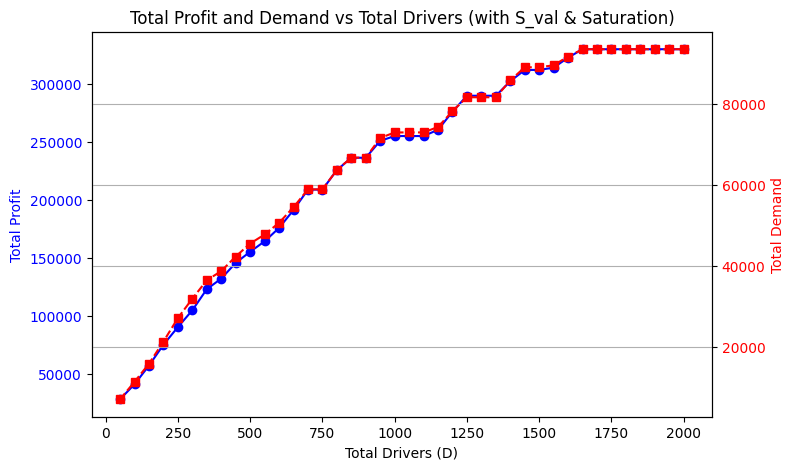

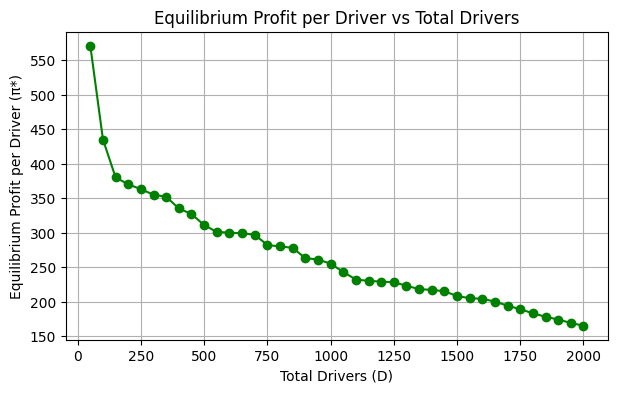

In [ ]:
# ----------------------------------------------------------------
# 6. Sweep D ∈ [100, 2000]
# ----------------------------------------------------------------
D_values = np.arange(50, 2001, 50)
total_profits, total_demands, profit_per_driver_vals = [], [], []

for D in D_values:
    result = allocate_for_total_drivers(D)
    total_profits.append(result["total_profit"])
    total_demands.append(result["total_demand"])
    profit_per_driver_vals.append(result["profit_per_driver"])
    print(D)
    #print(f"D={D:4d} → π*={result['profit_per_driver']}, "
    #      f"Total Demand={result['total_demand']:.1f}, "
    #      f"Total Profit={result['total_profit']:.1f}")

# ----------------------------------------------------------------
# 7. Plot results
# ----------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(D_values, total_profits, 'b-o')
ax1.set_xlabel("Total Drivers (D)")
ax1.set_ylabel("Total Profit", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(D_values, total_demands, 'r--s')
ax2.set_ylabel("Total Demand", color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Total Profit and Demand vs Total Drivers (with S_val & Saturation)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(D_values, profit_per_driver_vals, 'g-o')
plt.xlabel("Total Drivers (D)")
plt.ylabel("Equilibrium Profit per Driver (π*)")
plt.title("Equilibrium Profit per Driver vs Total Drivers")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 41 times so far.

  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 42 times so far.

  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1

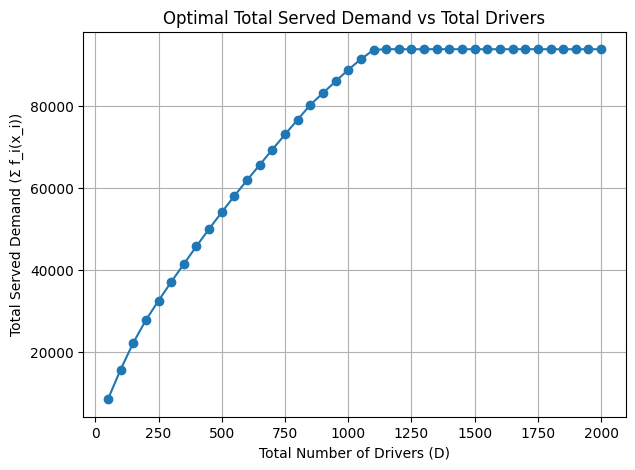

In [ ]:
# ---------------------------------------------------------
# 5. Sweep D and record total served demand
# ---------------------------------------------------------
D_values = np.arange(50, 2001, 50)
opt_demand = []

for D in D_values:
    _, total_served = solve_allocation(D)
    opt_demand.append(total_served)

# ---------------------------------------------------------
# 6. Plot total served demand vs total drivers
# ---------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(D_values, opt_demand, marker="o")
plt.xlabel("Total Number of Drivers (D)")
plt.ylabel("Total Served Demand (Σ f_i(x_i))")
plt.title("Optimal Total Served Demand vs Total Drivers")
plt.grid(True)
plt.show()

optimal
D=  50, Optimal Total Profit = 28727.11
optimal
D= 100, Optimal Total Profit = 49990.22
optimal
D= 150, Optimal Total Profit = 68851.03
optimal
D= 200, Optimal Total Profit = 87283.60
optimal
D= 250, Optimal Total Profit = 105188.17
optimal
D= 300, Optimal Total Profit = 122786.58
optimal
D= 350, Optimal Total Profit = 139589.37
optimal
D= 400, Optimal Total Profit = 155885.84
optimal
D= 450, Optimal Total Profit = 170911.53
optimal
D= 500, Optimal Total Profit = 185843.66
optimal
D= 550, Optimal Total Profit = 200693.66
optimal
D= 600, Optimal Total Profit = 215152.52
optimal
D= 650, Optimal Total Profit = 229112.67
optimal
D= 700, Optimal Total Profit = 242622.23
optimal
D= 750, Optimal Total Profit = 255579.89
optimal
D= 800, Optimal Total Profit = 267058.45
optimal
D= 850, Optimal Total Profit = 278463.67
optimal
D= 900, Optimal Total Profit = 289795.55
optimal
D= 950, Optimal Total Profit = 300659.91
optimal
D=1000, Optimal Total Profit = 311439.86
optimal
D=1050, Optimal 

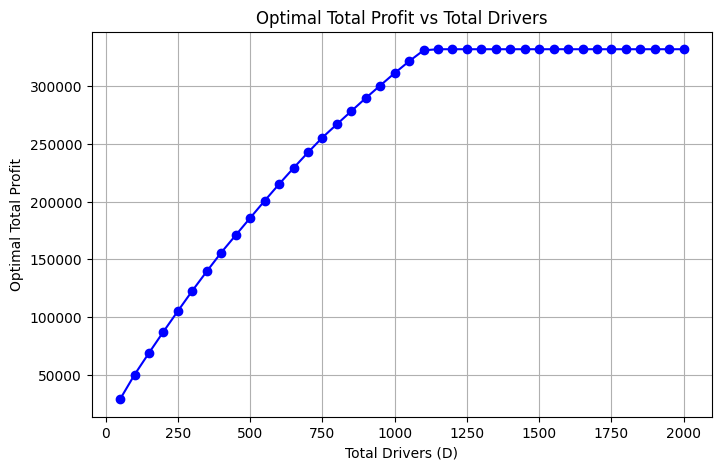

In [ ]:
# ----------------------------------------------------------------
# Sweep D ∈ [100, 2000] and compute optimal profit
# ----------------------------------------------------------------
D_values = np.arange(50, 2001, 50)
optimal_profits = []

for D in D_values:
    total_profit, _ = solve_optimal_profit_allocation(D)
    optimal_profits.append(total_profit)
    print(f"D={D:4d}, Optimal Total Profit = {total_profit:.2f}")

# ----------------------------------------------------------------
# Plot
# ----------------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(D_values, optimal_profits, 'b-o')
plt.xlabel("Total Drivers (D)")
plt.ylabel("Optimal Total Profit")
plt.title("Optimal Total Profit vs Total Drivers")
plt.grid(True)
plt.show()

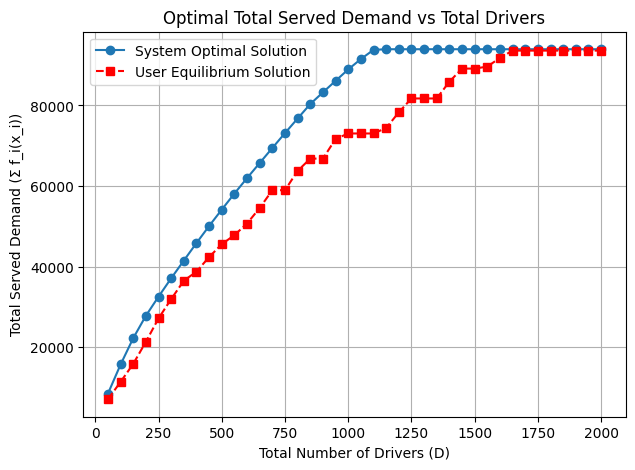

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(D_values, opt_demand, marker="o")
plt.plot(D_values, total_demands, 'r--s')
plt.xlabel("Total Number of Drivers (D)")
plt.ylabel("Total Served Demand (Σ f_i(x_i))")
plt.title("Optimal Total Served Demand vs Total Drivers")
plt.legend(['System Optimal Solution', 'User Equilibrium Solution'])
plt.grid(True)
plt.show()

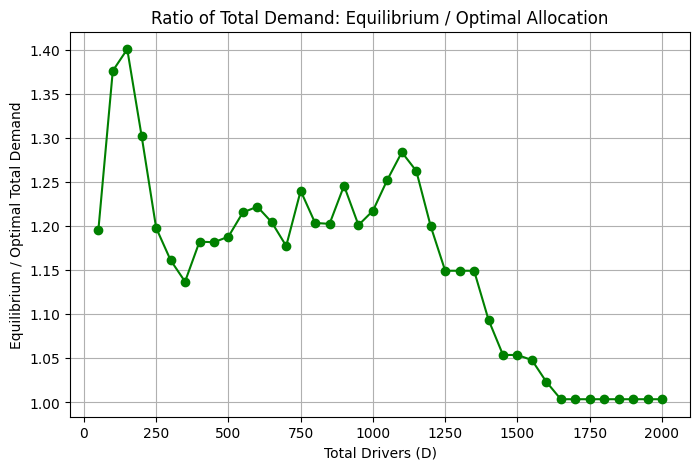

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(D_values, [opt_demand[i] / total_demands[i] for i in range(len(opt_demand))], 'g-o')
plt.xlabel("Total Drivers (D)")
plt.ylabel("Equilibrium / Optimal Total Demand")
plt.title("Ratio of Total Demand: Equilibrium / Optimal Allocation")
plt.grid(True)
plt.show()

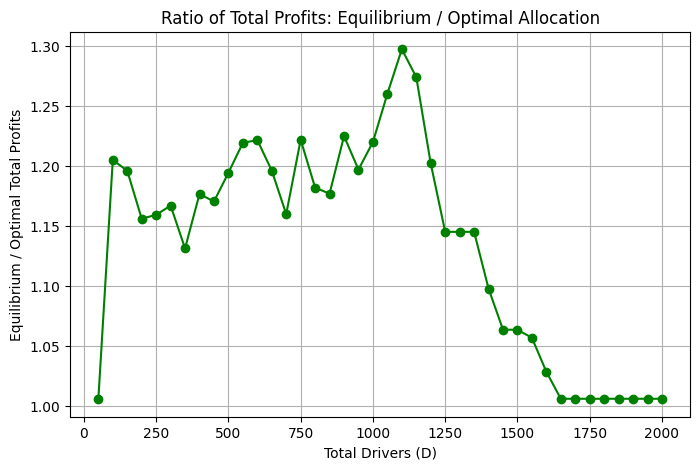

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(D_values, [optimal_profits[i] / total_profits[i] for i in range(len(optimal_profits))], 'g-o')
plt.xlabel("Total Drivers (D)")
plt.ylabel("Equilibrium / Optimal Total Profits")
plt.title("Ratio of Total Profits: Equilibrium / Optimal Allocation")
plt.grid(True)
plt.show()

In [ ]:
def plot_equilibrium_profit_per_driver_per_route(D_values, df):
    """
    For each D, run allocate_for_total_drivers(D),
    store allocations and equilibrium profit_per_driver (pi*),
    then plot per-route allocations vs D and pi* vs D.
    """

    route_names = df["rt_name"].tolist() if "rt_name" in df.columns else [f"Route_{i}" for i in range(len(df))]
    allocation_records = []
    profit_per_driver_vals = []

    for D in D_values:
        result = allocate_for_total_drivers(D)
        allocation_records.append(result["alloc"])
        profit_per_driver_vals.append(result["profit_per_driver"])
        print(f"D={D:4d} → π*={result['profit_per_driver']:.3f}, "
              f"Total Demand={result['total_demand']:.1f}, "
              f"Total Profit={result['total_profit']:.1f}")

    # Build allocation matrix (rows: D, columns: routes)
    alloc_matrix = pd.DataFrame(allocation_records, index=D_values, columns=route_names)
    profit_df = pd.DataFrame({
        "D": D_values,
        "profit_per_driver": profit_per_driver_vals
    })

    # --- Plot 1: Allocations per route vs D ---
    plt.figure(figsize=(9,6))
    for route in route_names:
        plt.plot(alloc_matrix.index, alloc_matrix[route], marker='o', label=route)
    plt.xlabel("D (total drivers)")
    plt.ylabel("Drivers allocated per route")
    plt.title("Equilibrium Allocations per Route vs D")
    plt.legend(title="Route", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Equilibrium profit per driver vs D ---
    plt.figure(figsize=(8,5))
    plt.plot(profit_df["D"], profit_df["profit_per_driver"], marker='s', color='black')
    plt.xlabel("D (total drivers)")
    plt.ylabel("Equilibrium profit per driver (π*)")
    plt.title("Equilibrium Profit per Driver vs D")
    plt.tight_layout()
    plt.show()

    return alloc_matrix, profit_df

Closest match for D=50: profit_per_driver=571.000, total_drivers=50.0, diff=0.02
D=  50 → π*=571.000, Total Demand=7140.1, Total Profit=28560.6
Closest match for D=100: profit_per_driver=435.000, total_drivers=95.4, diff=4.64
D= 100 → π*=435.000, Total Demand=11446.9, Total Profit=41480.9
Closest match for D=150: profit_per_driver=380.000, total_drivers=151.5, diff=1.48
D= 150 → π*=380.000, Total Demand=15911.7, Total Profit=57561.6
Closest match for D=200: profit_per_driver=370.000, total_drivers=204.0, diff=4.03
D= 200 → π*=370.000, Total Demand=21385.0, Total Profit=75491.8
Closest match for D=250: profit_per_driver=363.000, total_drivers=249.9, diff=0.06
D= 250 → π*=363.000, Total Demand=27192.3, Total Profit=90726.5
Closest match for D=300: profit_per_driver=355.000, total_drivers=296.4, diff=3.65
D= 300 → π*=355.000, Total Demand=31976.1, Total Profit=105204.5
Closest match for D=350: profit_per_driver=352.000, total_drivers=350.5, diff=0.48
D= 350 → π*=352.000, Total Demand=3651

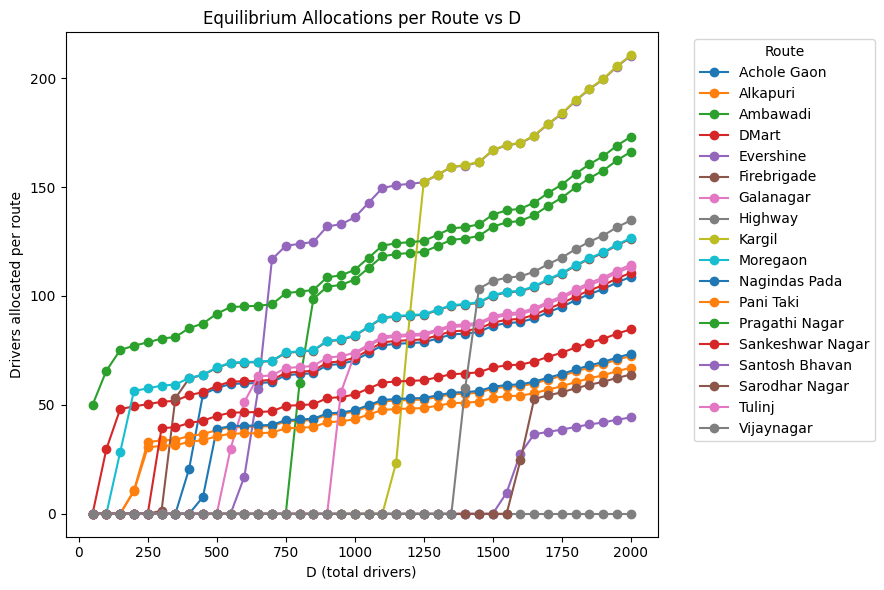

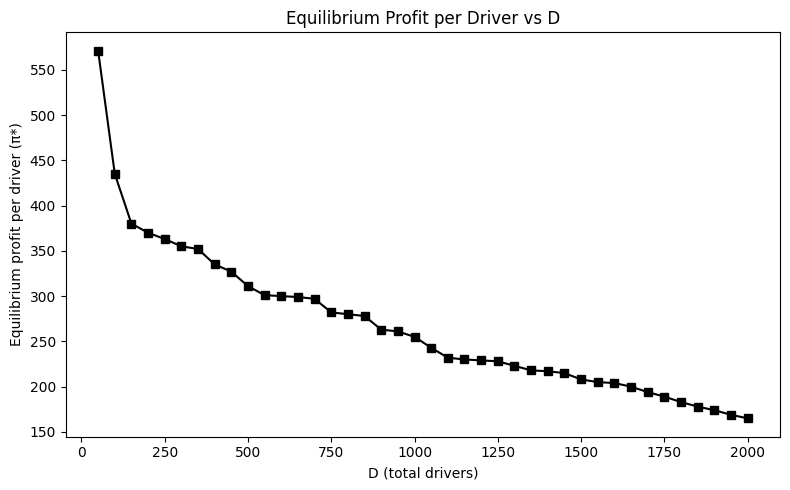

In [ ]:
D_values = np.arange(50, 2001, 50)
allocations_by_route, profit_per_driver_df = plot_equilibrium_profit_per_driver_per_route(D_values, df)

## Price Optimization

Price-bound diagnostic:
    rt_name  rt_fare  cost_per_rider  fare_upper_theory  fare_upper_demand  fare_upper  right_limit_profit_fare  policy_upper_minus_current  right_limit_profit_fare_pct_above_current  fare_feasible  policy_cap_below_cost  demand_upper_below_cost
Achole Gaon     20.0            16.0          94.995333             25.000      25.000                   25.000                       5.000                                       0.25           True                  False                    False
   Alkapuri     10.0             8.0          43.848024             12.500      12.500                   12.500                       2.500                                       0.25           True                  False                    False
   Ambawadi     17.5            14.0          69.117120             21.875      21.875                   21.875                       4.375                                       0.25           True                  False                  

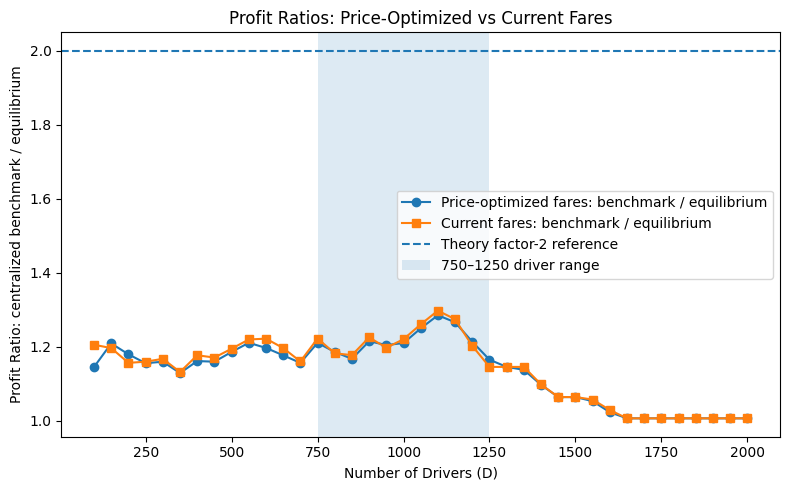

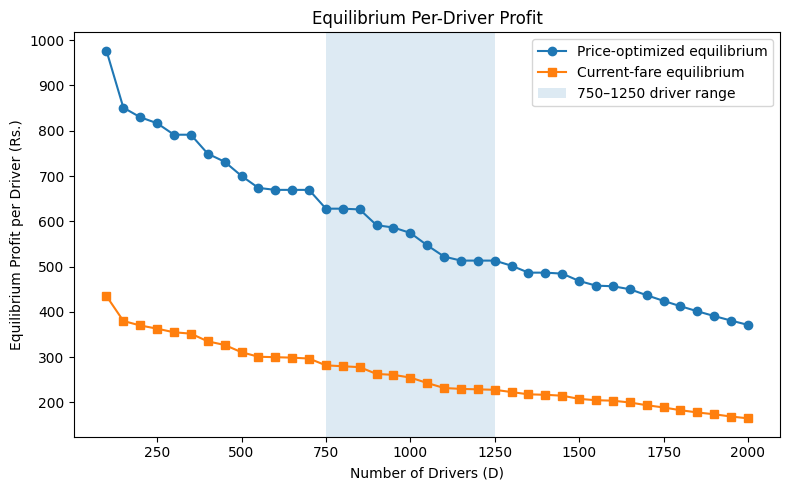

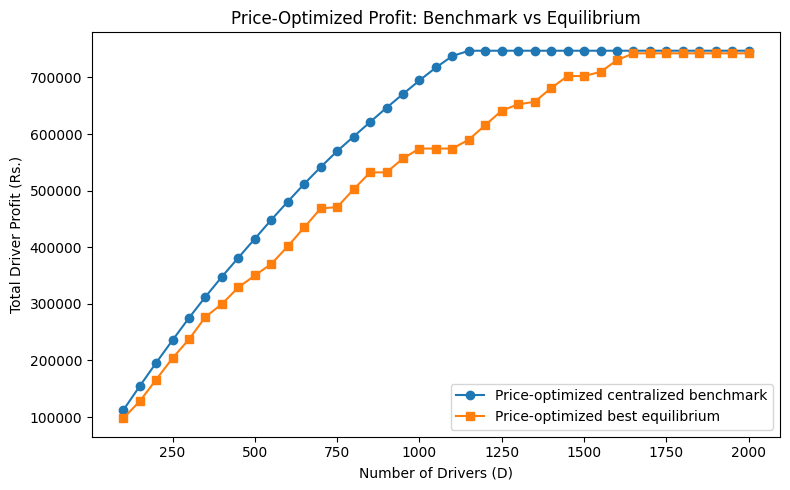

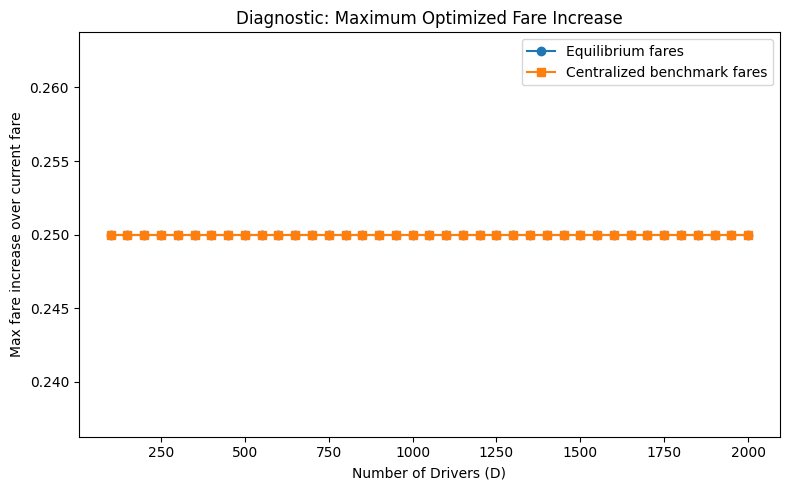

In [16]:
# ============================================================
# THEORY-CORRECT PRICE OPTIMIZATION — PROFIT OBJECTIVE
# ============================================================
# This block follows the computational characterization in Section 9.4:
#
#   Equilibrium profit benchmark:
#       q_i(x) = max_fare per-driver profit at route allocation x.
#       Binary search the common equilibrium profit pi and route capacities
#       u_i(pi) = max{x : q_i(x) >= pi}.
#
#   Centralized profit benchmark:
#       G_i(x) = max_fare total route profit at allocation x.
#       Allocate drivers over the separable functions G_i with a grid DP.
#
# The previous "fast" patch chose one optimized fare per route before solving
# the allocation problem. That was fast, but it was not the fare-optimized
# problem in the theory because the optimal fare can depend on the route's
# allocation x. This version keeps the speed improvements that matter
# (vectorized q_i and precomputed DP tables) while staying faithful to the
# price-optimization formulation.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_EPS = 1e-10


def _safe_nanmax(arr, default=np.nan):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.max(arr)) if arr.size else default


# ------------------------------------------------------------
# 1. Build route primitives and fare bounds
# ------------------------------------------------------------

def build_priceopt_params(
    df,
    F=F,
    eta_e=eta_e,
    eta_L=eta_L,
    eta_T=eta_T,
    T=t_2_t_1,
    max_pct_above_current=None,
    max_abs_above_current=None,
    hard_fare_upper_col=None,
    sval_max_pct_above_current=0.25,
):
    """
    Build route primitives for the fare-optimized model.

    Paper notation, translated to the notebook:
      * lower fare c_i^F = cost_per_rider_i
      * feasible margin q_i = fare_i - c_i^F
      * demand-side margin M_wtp_i = fare_upper_demand_i - c_i^F
      * policy-capped feasible margin q_upper_i = fare_upper_policy_i - c_i^F

    Demand uses M_wtp_i - q_i.  The feasible price search uses
    q_i in [0, q_upper_i].  Additional policy caps, such as +25% or +Rs.10,
    shrink q_upper_i but do not change the demand equation itself.
    """
    required = {"rt_time", "rt_fare", "walk_time_difference", "organic_demand"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {missing}")

    par = df.copy().reset_index(drop=True)

    if "rt_cost" in par.columns:
        # rt_cost is full-vehicle route cost in the notebook, so divide by F.
        par["cost_per_rider"] = par["rt_cost"].astype(float) / float(F)
    elif "rt_profit" in par.columns:
        # rt_profit is full-vehicle profit at the current fare.
        par["cost_per_rider"] = (
            par["rt_fare"].astype(float)
            - par["rt_profit"].astype(float) / float(F)
        )
    else:
        raise ValueError("Need either rt_cost or rt_profit to infer per-rider cost.")

    rt_time = par["rt_time"].astype(float)
    rt_fare = par["rt_fare"].astype(float)
    walk_diff = par["walk_time_difference"].astype(float)
    cost = par["cost_per_rider"].astype(float)

    # Raw theory upper fare: c_i^O - eta_T * l_i, in fare units.
    par["fare_upper_theory"] = float(eta_T) * (walk_diff - rt_time / 2.0)

    # Smooth S_val cap requested by the user: cap the outside-option term by
    # the value corresponding to 1.25 times the current fare.
    if sval_max_pct_above_current is None:
        par["effective_outside_opt_diff"] = walk_diff
        par["fare_upper_demand"] = par["fare_upper_theory"].astype(float)
    else:
        par["effective_outside_opt_diff"] = np.minimum(
            walk_diff,
            (
                (1.0 + float(sval_max_pct_above_current))
                * rt_fare
                / float(eta_T)
            )
            + rt_time / 2.0,
        )
        par["fare_upper_demand"] = float(eta_T) * (
            par["effective_outside_opt_diff"] - rt_time / 2.0
        )

    # Feasible fare upper bound after policy caps.
    policy_upper = par["fare_upper_demand"].astype(float).copy()

    if max_pct_above_current is not None:
        policy_upper = np.minimum(
            policy_upper,
            rt_fare * (1.0 + float(max_pct_above_current)),
        )

    if max_abs_above_current is not None:
        policy_upper = np.minimum(
            policy_upper,
            rt_fare + float(max_abs_above_current),
        )

    if hard_fare_upper_col is not None:
        policy_upper = np.minimum(policy_upper, par[hard_fare_upper_col].astype(float))

    par["fare_upper_policy_raw"] = policy_upper

    # A route is feasible for fare optimization only if the lower fare/cost is
    # below both the demand-side upper bound and the policy upper bound.
    raw_wtp_margin = par["fare_upper_demand"].astype(float) - cost
    raw_policy_margin = par["fare_upper_policy_raw"].astype(float) - cost

    route_feasible = (
        np.isfinite(raw_wtp_margin)
        & np.isfinite(raw_policy_margin)
        & (raw_wtp_margin >= -1e-8)
        & (raw_policy_margin >= -1e-8)
    )

    par["fare_feasible"] = route_feasible
    par["policy_cap_below_cost"] = raw_policy_margin < -1e-8
    par["demand_upper_below_cost"] = raw_wtp_margin < -1e-8

    par["M_wtp"] = np.where(route_feasible, np.maximum(raw_wtp_margin, 0.0), 0.0)
    par["q_upper"] = np.where(route_feasible, np.maximum(raw_policy_margin, 0.0), 0.0)

    # Backward-compatible alias used by downstream blocks.
    par["M"] = par["q_upper"]

    # Actual feasible upper fare used by the code.  Infeasible routes have
    # q_upper=0 and fare_upper=cost; demand_at_q returns zero for them.
    par["fare_upper"] = cost + par["q_upper"]

    eta_term = (float(eta_e) + float(eta_L)) / (float(eta_e) * float(eta_L))

    par["arrival_rate"] = par["organic_demand"].astype(float) / float(T)
    par["Lambda"] = par["organic_demand"].astype(float)

    # Demand primitives in fare-margin units:
    #   Lambda_i^M(x, q) = a0_i x + b0_i (M_wtp_i - q) x (1 - x/k_i)
    # before saturation.
    par["a0"] = float(F) * float(T) / rt_time
    par["b0"] = float(F) * eta_term / (rt_time * float(eta_T))

    par["k_star_po"] = np.divide(
        par["Lambda"],
        par["a0"],
        out=np.full(len(par), np.inf),
        where=par["a0"].to_numpy(dtype=float) > _EPS,
    )

    par["H"] = np.divide(
        par["Lambda"],
        par["b0"],
        out=np.full(len(par), np.inf),
        where=par["b0"].to_numpy(dtype=float) > _EPS,
    )

    par["current_per_rider_profit"] = rt_fare - cost

    # Diagnostic only: the profit-maximizing right-limit fare at x=0.
    a0 = par["a0"].to_numpy(dtype=float)
    b0 = par["b0"].to_numpy(dtype=float)
    M_wtp = par["M_wtp"].to_numpy(dtype=float)
    q_upper = par["q_upper"].to_numpy(dtype=float)

    q_seed_unclipped = 0.5 * (
        M_wtp + np.divide(a0, b0, out=np.zeros(len(par)), where=b0 > _EPS)
    )
    q_seed = np.clip(q_seed_unclipped, 0.0, q_upper)
    q_seed = np.where(route_feasible, q_seed, 0.0)

    par["right_limit_profit_margin"] = q_seed
    par["right_limit_profit_fare"] = cost + q_seed

    # Older downstream code expected these names. They are now diagnostics only;
    # actual price optimization happens as a function of allocation x.
    par["priceopt_margin"] = par["right_limit_profit_margin"]
    par["priceopt_fare"] = par["right_limit_profit_fare"]

    # Compatibility coefficients at the diagnostic seed fare.
    S_seed = np.maximum(M_wtp - q_seed, 0.0)
    k = par["k_star_po"].to_numpy(dtype=float)
    H = par["H"].to_numpy(dtype=float)

    par["a"] = -np.divide(
        b0 * S_seed,
        k,
        out=np.zeros(len(par), dtype=float),
        where=k > _EPS,
    )
    par["b"] = a0 + b0 * S_seed
    par["n_max"] = np.minimum(
        k,
        np.divide(
            H,
            S_seed,
            out=np.full(len(par), np.inf),
            where=S_seed > _EPS,
        ),
    )
    par["S_val"] = S_seed / float(eta_T)

    par["theory_upper_minus_current"] = par["fare_upper_theory"] - rt_fare
    par["demand_upper_minus_current"] = par["fare_upper_demand"] - rt_fare
    par["policy_upper_minus_current"] = par["fare_upper"] - rt_fare

    par["policy_upper_pct_above_current"] = np.divide(
        par["fare_upper"] - rt_fare,
        rt_fare,
        out=np.full(len(par), np.nan),
        where=rt_fare > 0,
    )

    par["right_limit_profit_fare_pct_above_current"] = np.divide(
        par["right_limit_profit_fare"] - rt_fare,
        rt_fare,
        out=np.full(len(par), np.nan),
        where=rt_fare > 0,
    )

    return par



def audit_price_bounds(par, top=10):
    """Quick diagnostic for fare bounds and route feasibility."""
    cols = [
        c for c in [
            "rt_name",
            "rt_fare",
            "cost_per_rider",
            "fare_upper_theory",
            "fare_upper_demand",
            "fare_upper",
            "right_limit_profit_fare",
            "policy_upper_minus_current",
            "right_limit_profit_fare_pct_above_current",
            "fare_feasible",
            "policy_cap_below_cost",
            "demand_upper_below_cost",
        ]
        if c in par.columns
    ]

    print("Price-bound diagnostic:")
    print(par[cols].head(top).to_string(index=False))

    if "right_limit_profit_fare_pct_above_current" in par.columns:
        print(
            "\nMax right-limit diagnostic fare increase over current fare:",
            _safe_nanmax(par["right_limit_profit_fare_pct_above_current"].to_numpy(dtype=float)),
        )

    if "fare_feasible" in par.columns:
        print("Feasible routes:", int(par["fare_feasible"].sum()), "of", len(par))


# ------------------------------------------------------------
# 2. Demand, profit, and route-level price optimization helpers
# ------------------------------------------------------------

def _route_arrays(par):
    q_upper = par["q_upper"].to_numpy(dtype=float) if "q_upper" in par.columns else par["M"].to_numpy(dtype=float)
    M_wtp = par["M_wtp"].to_numpy(dtype=float) if "M_wtp" in par.columns else par["M"].to_numpy(dtype=float)
    a0 = par["a0"].to_numpy(dtype=float)
    b0 = par["b0"].to_numpy(dtype=float)
    Lam = par["Lambda"].to_numpy(dtype=float)
    k = par["k_star_po"].to_numpy(dtype=float)
    H = par["H"].to_numpy(dtype=float)
    cost = par["cost_per_rider"].to_numpy(dtype=float)

    if "fare_feasible" in par.columns:
        active = par["fare_feasible"].to_numpy(dtype=bool)
    else:
        active = np.ones(len(par), dtype=bool)

    return q_upper, M_wtp, a0, b0, Lam, k, H, cost, active



def _route_scalars(par, i):
    q_upper, M_wtp, a0, b0, Lam, k, H, cost, active = _route_arrays(par)
    i = int(i)
    return (
        float(q_upper[i]),
        float(M_wtp[i]),
        float(a0[i]),
        float(b0[i]),
        float(Lam[i]),
        float(k[i]),
        float(H[i]),
        float(cost[i]),
        bool(active[i]),
    )



def _demand_vector_from_arrays(q_upper, M_wtp, a0, b0, Lam, k, H, active, x, q):
    x = np.asarray(x, dtype=float)
    q = np.asarray(q, dtype=float)

    q = np.clip(q, 0.0, q_upper)
    S = np.maximum(M_wtp - q, 0.0)

    H_over_S = np.divide(H, S, out=np.full_like(S, np.inf, dtype=float), where=S > _EPS)
    threshold = np.where(S > _EPS, np.minimum(k, H_over_S), k)

    quad = a0 * x + b0 * S * x * (1.0 - np.divide(x, k, out=np.zeros_like(x, dtype=float), where=k > _EPS))
    demand = np.where(x >= threshold - 1e-9, Lam, quad)
    demand = np.where((active) & (x > _EPS) & (Lam > 0) & (k > 0), demand, 0.0)
    return np.clip(demand, 0.0, Lam)



def _demand_vector(par, x, q):
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_arrays(par)
    return _demand_vector_from_arrays(q_upper, M_wtp, a0, b0, Lam, k, H, active, x, q)



def demand_at_q(par, i, x, q):
    """Demand served on route i at allocation x and per-rider margin q."""
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_scalars(par, i)

    if (not active) or x <= _EPS or Lam <= 0 or k <= 0:
        return 0.0

    q = float(np.clip(q, 0.0, q_upper))
    S = max(M_wtp - q, 0.0)

    if S <= _EPS:
        threshold = k
    else:
        threshold = min(k, H / S)

    if x >= threshold - 1e-9:
        return float(Lam)

    val = a0 * x + b0 * S * x * (1.0 - x / k)
    return float(np.clip(val, 0.0, Lam))



def total_profit_at_q(par, i, x, q):
    q_upper = _route_scalars(par, i)[0]
    q_clip = float(np.clip(q, 0.0, q_upper))
    return q_clip * demand_at_q(par, i, x, q_clip)



def ppd_at_q(par, i, x, q):
    """Per-driver profit on route i; at x=0, returns the right limit."""
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_scalars(par, i)

    if not active:
        return 0.0

    q = float(np.clip(q, 0.0, q_upper))
    x = float(max(x, 0.0))
    S = max(M_wtp - q, 0.0)

    if x <= _EPS:
        return float(q * (a0 + b0 * S))

    return total_profit_at_q(par, i, x, q) / x



def candidate_prices_for_x(par, i, x):
    """O(1) candidate margins q for max_q ppd_i(x,q) or max_q total_profit_i(x,q)."""
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_scalars(par, i)

    if (not active) or q_upper <= _EPS:
        return np.array([0.0])

    x = float(max(x, 0.0))
    candidates = [0.0, q_upper]

    if x <= _EPS:
        if b0 > _EPS:
            candidates.append(0.5 * (M_wtp + a0 / b0))

    elif x < k - _EPS:
        q_sat = max(0.0, M_wtp - H / x)
        candidates.append(q_sat)

        denom = max(k - x, _EPS)
        q_quad = 0.5 * (M_wtp + H / denom)
        candidates.append(q_quad)

    arr = np.array(candidates, dtype=float)
    arr = arr[np.isfinite(arr)]
    arr = np.clip(arr, 0.0, q_upper)
    return np.unique(np.round(arr, 12))



def best_ppd_at_x(par, i, x):
    qs = candidate_prices_for_x(par, i, x)
    vals = np.array([ppd_at_q(par, i, x, q) for q in qs], dtype=float)
    if not np.isfinite(vals).any():
        return 0.0, 0.0
    j = int(np.nanargmax(vals))
    return float(vals[j]), float(qs[j])



def best_total_profit_at_x(par, i, x):
    x = float(max(x, 0.0))
    if x <= _EPS:
        return 0.0, 0.0

    qs = candidate_prices_for_x(par, i, x)
    vals = np.array([total_profit_at_q(par, i, x, q) for q in qs], dtype=float)
    if not np.isfinite(vals).any():
        return 0.0, 0.0
    j = int(np.nanargmax(vals))
    return float(vals[j]), float(qs[j])



def _candidate_q_vector(par, x):
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_arrays(par)
    x = np.asarray(x, dtype=float)
    n = len(q_upper)

    q0 = np.zeros(n, dtype=float)
    qU = q_upper.copy()

    q_sat = np.zeros(n, dtype=float)
    mask_sat = (x > _EPS) & (x < k - _EPS)
    q_sat[mask_sat] = M_wtp[mask_sat] - H[mask_sat] / x[mask_sat]

    q_quad = qU.copy()
    mask_quad = x < k - _EPS
    denom = np.maximum(k[mask_quad] - x[mask_quad], _EPS)
    q_quad[mask_quad] = 0.5 * (M_wtp[mask_quad] + H[mask_quad] / denom)

    q_rl = 0.5 * (M_wtp + np.divide(a0, b0, out=np.zeros(n), where=b0 > _EPS))

    cands = np.vstack([q0, qU, q_sat, q_quad, q_rl])
    cands = np.nan_to_num(cands, nan=0.0, posinf=np.inf, neginf=0.0)
    cands = np.maximum(cands, 0.0)
    cands = np.minimum(cands, q_upper[None, :])
    cands = np.where(active[None, :], cands, 0.0)
    return cands



def _ppd_vector_for_q(par, x, q):
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_arrays(par)
    x = np.asarray(x, dtype=float)
    q = np.asarray(q, dtype=float)
    q = np.clip(q, 0.0, q_upper)
    S = np.maximum(M_wtp - q, 0.0)

    demand = _demand_vector_from_arrays(q_upper, M_wtp, a0, b0, Lam, k, H, active, x, q)
    ppd_positive_x = np.divide(q * demand, x, out=np.zeros_like(q, dtype=float), where=x > _EPS)
    ppd_right_limit = q * (a0 + b0 * S)
    ppd = np.where(x > _EPS, ppd_positive_x, ppd_right_limit)
    return np.where(active, ppd, 0.0)



def _best_ppd_vector(par, x):
    x = np.asarray(x, dtype=float)
    cands = _candidate_q_vector(par, x)
    vals = np.vstack([_ppd_vector_for_q(par, x, cands[j]) for j in range(cands.shape[0])])
    idx = np.nanargmax(vals, axis=0)
    best_vals = vals[idx, np.arange(vals.shape[1])]
    best_q = cands[idx, np.arange(cands.shape[1])]
    return best_vals, best_q



def min_q_for_ppd(par, i, x, target_ppd, tol=1e-7, max_iter=45):
    """
    Smallest q in [0, q_upper_i] such that ppd_i(x, q) >= target_ppd.

    This implements the rider-welfare monotonicity logic: for a fixed x, use
    the smallest fare that satisfies the required driver profit / reservation
    wage whenever possible.
    """
    target_ppd = float(target_ppd)

    if target_ppd <= tol:
        return 0.0

    best_val, q_star = best_ppd_at_x(par, i, x)
    q_upper = _route_scalars(par, i)[0]

    if best_val + 5 * tol < target_ppd or q_upper <= _EPS:
        return np.nan

    hi = float(q_star)

    if hi <= _EPS:
        return np.nan

    lo = 0.0

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)

        if ppd_at_q(par, i, x, mid) >= target_ppd:
            hi = mid
        else:
            lo = mid

    return float(hi)


# ------------------------------------------------------------
# 3. Vectorized grid tables and separable DP
# ------------------------------------------------------------

def _candidate_q_grid(par, used_grid):
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_arrays(par)
    used_grid = np.asarray(used_grid, dtype=float)

    n = len(q_upper)
    Gp = len(used_grid)
    x = used_grid[None, :]

    qU = q_upper[:, None] + np.zeros((n, Gp))
    q0 = np.zeros((n, Gp), dtype=float)

    M = M_wtp[:, None]
    K = k[:, None]
    HH = H[:, None]

    q_sat = np.zeros((n, Gp), dtype=float)
    mask_sat = (x > _EPS) & (x < K - _EPS)
    q_sat = np.where(mask_sat, M - HH / np.maximum(x, _EPS), q_sat)

    denom = np.maximum(K - x, _EPS)
    q_quad = 0.5 * (M + HH / denom)
    q_quad = np.where(x < K - _EPS, q_quad, qU)

    q_rl = 0.5 * (
        M + np.divide(a0, b0, out=np.zeros(n), where=b0 > _EPS)[:, None]
    )
    q_rl = q_rl + np.zeros((n, Gp))

    cands = np.stack([q0, qU, q_sat, q_quad, q_rl], axis=0)
    cands = np.nan_to_num(cands, nan=0.0, posinf=np.inf, neginf=0.0)
    cands = np.maximum(cands, 0.0)
    cands = np.minimum(cands, q_upper[None, :, None])
    cands = np.where(active[None, :, None], cands, 0.0)
    return cands



def _demand_grid_for_q(par, used_grid, q):
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_arrays(par)
    used_grid = np.asarray(used_grid, dtype=float)
    q = np.asarray(q, dtype=float)

    x = used_grid[None, :]
    qU = q_upper[:, None]
    M = M_wtp[:, None]
    A = a0[:, None]
    B = b0[:, None]
    L = Lam[:, None]
    K = k[:, None]
    HH = H[:, None]
    ACT = active[:, None]

    q = np.clip(q, 0.0, qU)
    S = np.maximum(M - q, 0.0)

    H_over_S = np.divide(HH, S, out=np.full_like(S, np.inf), where=S > _EPS)
    threshold = np.where(S > _EPS, np.minimum(K, H_over_S), K)

    quad = A * x + B * S * x * (1.0 - np.divide(x, K, out=np.zeros_like(q, dtype=float), where=K > _EPS))
    demand = np.where(x >= threshold - 1e-9, L, quad)
    demand = np.where((ACT) & (x > _EPS) & (L > 0) & (K > 0), demand, 0.0)
    return np.clip(demand, 0.0, L)



def _best_profit_tables(par, used_grid):
    cands = _candidate_q_grid(par, used_grid)
    vals = []

    for j in range(cands.shape[0]):
        q = cands[j]
        demand = _demand_grid_for_q(par, used_grid, q)
        vals.append(q * demand)

    vals = np.stack(vals, axis=0)
    idx = np.nanargmax(vals, axis=0)
    route_val = vals[idx, np.arange(vals.shape[1])[:, None], np.arange(vals.shape[2])[None, :]]
    route_q = cands[idx, np.arange(vals.shape[1])[:, None], np.arange(vals.shape[2])[None, :]]

    route_val[:, 0] = 0.0
    route_q[:, 0] = 0.0
    return route_val, route_q



def _separable_dp_from_tables(route_val, route_q, used_grid, caps=None, at_most=True):
    route_val = np.asarray(route_val, dtype=float).copy()
    route_q = np.asarray(route_q, dtype=float).copy()
    used_grid = np.asarray(used_grid, dtype=float)

    n, Gp = route_val.shape
    G = Gp - 1
    D = float(used_grid[-1]) if G >= 0 else 0.0

    if caps is None:
        caps = np.full(n, D, dtype=float)
    else:
        caps = np.asarray(caps, dtype=float)
        caps = np.nan_to_num(caps, nan=0.0, posinf=D, neginf=0.0)
        caps = np.clip(caps, 0.0, D)

    for i in range(n):
        max_g = int(np.searchsorted(used_grid, caps[i] + 1e-9, side="right") - 1)
        max_g = max(0, min(max_g, G))
        if max_g + 1 < Gp:
            route_val[i, max_g + 1:] = -np.inf
            route_q[i, max_g + 1:] = 0.0
        route_val[i, 0] = max(route_val[i, 0], 0.0)
        route_q[i, 0] = 0.0

    dp = np.full((n + 1, G + 1), -np.inf, dtype=float)
    choice = np.zeros((n + 1, G + 1), dtype=int)
    dp[0, 0] = 0.0

    for i in range(n):
        prev = dp[i]
        curr = dp[i + 1]
        for total_g in range(G + 1):
            vals = prev[:total_g + 1] + route_val[i, total_g::-1]
            if not np.isfinite(vals).any():
                continue
            prev_g = int(np.nanargmax(vals))
            curr[total_g] = vals[prev_g]
            choice[i + 1, total_g] = total_g - prev_g

    final_g = int(np.nanargmax(dp[n, :])) if at_most else G
    best_val = float(dp[n, final_g])

    if not np.isfinite(best_val):
        return np.zeros(n), np.zeros(n), -np.inf, used_grid

    x = np.zeros(n, dtype=float)
    q = np.zeros(n, dtype=float)
    remaining_g = final_g

    for i in range(n - 1, -1, -1):
        route_g = int(choice[i + 1, remaining_g])
        x[i] = used_grid[route_g]
        q[i] = route_q[i, route_g]
        remaining_g -= route_g

    return x, q, best_val, used_grid



def _separable_dp(
    par,
    D,
    value_func,
    grid_step=5.0,
    caps=None,
    at_most=True,
):
    """
    Generic separable grid DP retained for rider-welfare/reservation-wage code.

    value_func(i, x) may return either value or (value, q).
    """
    D = float(D)
    grid_step = float(grid_step)
    n = len(par)

    if grid_step <= 0:
        raise ValueError("grid_step must be positive.")

    if D <= _EPS or n == 0:
        return np.zeros(n), np.zeros(n), 0.0, np.array([0.0])

    G = max(1, int(round(D / grid_step)))
    used_grid = np.linspace(0.0, D, G + 1)

    if caps is None:
        caps = np.full(n, D, dtype=float)
    else:
        caps = np.asarray(caps, dtype=float)
        caps = np.nan_to_num(caps, nan=0.0, posinf=D, neginf=0.0)
        caps = np.clip(caps, 0.0, D)

    route_val = np.full((n, G + 1), -np.inf, dtype=float)
    route_q = np.zeros((n, G + 1), dtype=float)

    for i in range(n):
        max_g = int(np.searchsorted(used_grid, caps[i] + 1e-9, side="right") - 1)
        max_g = max(0, min(max_g, G))

        route_val[i, 0] = 0.0
        route_q[i, 0] = 0.0

        for g in range(1, max_g + 1):
            x = float(used_grid[g])
            out = value_func(i, x)

            if isinstance(out, (tuple, list, np.ndarray)):
                val = float(out[0])
                q = float(out[1]) if len(out) > 1 and np.isfinite(out[1]) else 0.0
            else:
                val = float(out)
                q = 0.0

            if np.isfinite(val):
                route_val[i, g] = val
                route_q[i, g] = q

    return _separable_dp_from_tables(route_val, route_q, used_grid, caps=caps, at_most=at_most)


# ------------------------------------------------------------
# 4. Theory-correct profit benchmarks
# ------------------------------------------------------------

def centralized_profit_dp(D, par, grid_step=5.0, solver=None):
    """
    Centralized fare-optimized profit benchmark.

    Computes G_i(x) = max_q q * demand_i(x, q) on a grid and solves the
    separable allocation problem with a DP, matching Proposition 5 up to the
    grid approximation.
    """
    D = float(D)
    grid_step = float(grid_step)
    n = len(par)
    cost = par["cost_per_rider"].to_numpy(dtype=float)

    if D <= _EPS or n == 0:
        z = np.zeros(n, dtype=float)
        return {
            "D": D,
            "alloc": z,
            "q": z.copy(),
            "fares": cost.copy(),
            "demand": z.copy(),
            "route_profit": z.copy(),
            "total_profit": 0.0,
            "total_welfare": 0.0,
            "drivers_used": 0.0,
            "drivers_unmatched": D,
            "profit_per_used_driver": np.nan,
            "fare_cap_bind_share_used_routes": np.nan,
            "used_grid": np.array([0.0]),
        }

    if grid_step <= 0:
        raise ValueError("grid_step must be positive.")

    G = max(1, int(round(D / grid_step)))
    used_grid = np.linspace(0.0, D, G + 1)

    route_val, route_q = _best_profit_tables(par, used_grid)
    x, q, best_val, used_grid = _separable_dp_from_tables(
        route_val,
        route_q,
        used_grid,
        caps=np.full(n, D, dtype=float),
        at_most=True,
    )

    demand = _demand_vector(par, x, q)
    route_profit = q * demand
    fares = cost + q
    used = x > 1e-8
    q_upper = par["q_upper"].to_numpy(dtype=float) if "q_upper" in par.columns else par["M"].to_numpy(dtype=float)

    return {
        "D": D,
        "alloc": x,
        "q": q,
        "fares": fares,
        "demand": demand,
        "route_profit": route_profit,
        "total_profit": float(route_profit.sum()),
        "total_welfare": float(demand.sum()),
        "drivers_used": float(x.sum()),
        "drivers_unmatched": float(max(D - x.sum(), 0.0)),
        "profit_per_used_driver": (
            float(route_profit.sum() / x.sum()) if x.sum() > _EPS else np.nan
        ),
        "fare_cap_bind_share_used_routes": (
            float(np.mean(q[used] >= q_upper[used] - 1e-6)) if used.any() else np.nan
        ),
        "used_grid": used_grid,
        "dp_value": best_val,
    }



def _capacity_vector_for_ppd(par, D, target_ppd, tol=1e-7, max_iter=50):
    """Vectorized u_i(pi) = max{x <= D : max_q ppd_i(x,q) >= pi}."""
    D = float(D)
    target_ppd = float(target_ppd)
    n = len(par)

    if D <= _EPS or n == 0:
        return np.zeros(n, dtype=float)

    if target_ppd <= tol:
        return np.full(n, D, dtype=float)

    ppd0, _ = _best_ppd_vector(par, np.zeros(n, dtype=float))
    active = ppd0 + tol >= target_ppd

    lo = np.zeros(n, dtype=float)
    hi = np.full(n, D, dtype=float)

    if not active.any():
        return lo

    # If q_i(D) already clears the target, the capacity is D.
    ppdD, _ = _best_ppd_vector(par, hi)
    lo = np.where(active & (ppdD >= target_ppd - tol), D, lo)
    search = active & (lo < D - 1e-9)

    for _ in range(max_iter):
        if not search.any():
            break
        mid = 0.5 * (lo + hi)
        vals, _ = _best_ppd_vector(par, mid)
        ok = vals >= target_ppd - tol
        lo = np.where(search & ok, mid, lo)
        hi = np.where(search & (~ok), mid, hi)

    return np.clip(lo, 0.0, D)



def _allocate_from_capacities(par, D, caps, allocation_rule="proportional"):
    """Select one equilibrium allocation x with 0 <= x_i <= u_i(pi) and sum x_i = D."""
    D = float(D)
    caps = np.asarray(caps, dtype=float)
    caps = np.nan_to_num(caps, nan=0.0, posinf=D, neginf=0.0)
    caps = np.clip(caps, 0.0, D)

    if D <= _EPS or caps.sum() <= _EPS:
        return np.zeros_like(caps)

    if caps.sum() <= D + 1e-7:
        return caps.copy()

    rule = str(allocation_rule).lower()

    if rule in {"proportional", "prop"}:
        return caps * (D / caps.sum())

    if rule in {"greedy", "fill", "sequential"}:
        scores, _ = _best_ppd_vector(par, np.zeros(len(caps), dtype=float))
        order = np.argsort(-scores)
        x = np.zeros_like(caps)
        remaining = D

        for i in order:
            if remaining <= _EPS:
                break
            take = min(caps[i], remaining)
            x[i] = take
            remaining -= take

        return x

    if rule in {"equal", "waterfill", "water_fill"}:
        x = np.zeros_like(caps)
        remaining = D
        active = caps > _EPS

        while remaining > 1e-8 and active.any():
            share = remaining / active.sum()
            idx = np.where(active)[0]
            take = np.minimum(caps[idx] - x[idx], share)
            x[idx] += take
            remaining = D - x.sum()
            active = (caps - x) > 1e-8

        return x

    raise ValueError("allocation_rule must be 'proportional', 'greedy', or 'equal'.")



def fare_opt_profit_equilibrium(
    D,
    par,
    allocation_rule="proportional",
    tol=1e-7,
    max_iter=55,
):
    """
    Best fare-optimized driver equilibrium for a fixed total driver count D.

    Implements Proposition 4:
      * binary search the largest common per-driver profit pi such that
        sum_i u_i(pi) >= D;
      * choose any allocation x_i <= u_i(pi) summing to D;
      * choose fares on used routes so each used route earns pi per driver.
    """
    D = float(D)
    n = len(par)
    cost = par["cost_per_rider"].to_numpy(dtype=float)

    if D <= _EPS or n == 0:
        z = np.zeros(n, dtype=float)
        return {
            "D": D,
            "pi_eq": 0.0,
            "alloc": z,
            "q": z.copy(),
            "fares": cost.copy(),
            "demand": z.copy(),
            "route_profit": z.copy(),
            "total_profit": 0.0,
            "total_profit_Dpi": 0.0,
            "total_welfare": 0.0,
            "drivers_used": 0.0,
            "drivers_unmatched": D,
            "capacity_at_pi": z.copy(),
        }

    right_limit_ppd, _ = _best_ppd_vector(par, np.zeros(n, dtype=float))
    right_limit_ppd = np.nan_to_num(right_limit_ppd, nan=0.0, posinf=0.0, neginf=0.0)
    hi = float(np.max(right_limit_ppd)) if len(right_limit_ppd) else 0.0

    if hi <= _EPS:
        z = np.zeros(n, dtype=float)
        return {
            "D": D,
            "pi_eq": 0.0,
            "alloc": z,
            "q": z.copy(),
            "fares": cost.copy(),
            "demand": z.copy(),
            "route_profit": z.copy(),
            "total_profit": 0.0,
            "total_profit_Dpi": 0.0,
            "total_welfare": 0.0,
            "drivers_used": 0.0,
            "drivers_unmatched": D,
            "capacity_at_pi": z.copy(),
        }

    lo = 0.0
    best_caps = np.zeros(n, dtype=float)

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        caps = _capacity_vector_for_ppd(par, D, mid, tol=tol)

        if caps.sum() >= D - tol:
            lo = mid
            best_caps = caps
        else:
            hi = mid

    pi_eq = float(lo)
    caps = _capacity_vector_for_ppd(par, D, pi_eq, tol=tol)

    if caps.sum() < D - 1e-5 and best_caps.sum() >= D - 1e-5:
        caps = best_caps

    x = _allocate_from_capacities(par, D, caps, allocation_rule=allocation_rule)

    q = np.zeros(n, dtype=float)

    for i in range(n):
        if x[i] <= 1e-8:
            q[i] = 0.0
            continue

        q_i = min_q_for_ppd(par, i, x[i], pi_eq, tol=tol)

        if not np.isfinite(q_i):
            best_val, q_star = best_ppd_at_x(par, i, x[i])
            if best_val + 1e-6 >= pi_eq:
                q_i = q_star
            else:
                x[i] = 0.0
                q_i = 0.0

        q[i] = q_i

    demand = _demand_vector(par, x, q)
    route_profit = q * demand
    fares = cost + q

    return {
        "D": D,
        "pi_eq": pi_eq,
        "alloc": x,
        "q": q,
        "fares": fares,
        "demand": demand,
        "route_profit": route_profit,
        "total_profit": float(route_profit.sum()),
        "total_profit_Dpi": float(pi_eq * D),
        "total_welfare": float(demand.sum()),
        "drivers_used": float(x.sum()),
        "drivers_unmatched": float(max(D - x.sum(), 0.0)),
        "capacity_at_pi": caps,
    }


# ------------------------------------------------------------
# 5. Current-fare baseline and Figure-3 runner
# ------------------------------------------------------------

def _maybe_fixed_fare_baseline(D):
    """Original current-fare equilibrium/system-optimal baseline, if loaded."""
    out = {}

    if "allocate_for_total_drivers" in globals():
        try:
            fixed_eq = allocate_for_total_drivers(D)
            out["fixed_eq_profit"] = fixed_eq.get("total_profit", np.nan)
            out["fixed_eq_ppd"] = fixed_eq.get("profit_per_driver", np.nan)
            out["fixed_eq_welfare"] = fixed_eq.get("total_demand", np.nan)
        except Exception as e:
            print(f"Skipping fixed-fare equilibrium baseline for D={D}: {e}")

    if "solve_optimal_profit_allocation" in globals():
        try:
            fixed_opt_profit, _ = solve_optimal_profit_allocation(D)
            out["fixed_opt_profit"] = fixed_opt_profit
        except Exception as e:
            print(f"Skipping fixed-fare optimal baseline for D={D}: {e}")

    if (
        "fixed_eq_profit" in out
        and "fixed_opt_profit" in out
        and out["fixed_eq_profit"] > _EPS
    ):
        out["fixed_profit_poa"] = out["fixed_opt_profit"] / out["fixed_eq_profit"]
        out["fixed_eq_over_opt"] = out["fixed_eq_profit"] / out["fixed_opt_profit"] if out["fixed_opt_profit"] > _EPS else np.nan
    else:
        out["fixed_profit_poa"] = np.nan
        out["fixed_eq_over_opt"] = np.nan

    return out



def _weighted_avg(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    s = np.sum(weights)
    return float(np.sum(values * weights) / s) if s > _EPS else np.nan



def run_priceopt_profit_figure3(
    D_values=None,
    grid_step=5.0,
    include_fixed_fare=True,
    allocation_rule="proportional",
    save_csv=True,
    csv_name="priceopt_profit_fig3_theory_correct.csv",
    par=None,
    max_pct_above_current=None,
    max_abs_above_current=None,
    hard_fare_upper_col=None,
    sval_max_pct_above_current=0.25,
    audit_bounds=True,
):
    """
    Theory-correct fare-optimized profit experiment.

    `grid_step` controls only the centralized price-optimized benchmark DP.
    The equilibrium benchmark uses nested binary search from Proposition 4.
    """
    if D_values is None:
        D_values = np.arange(100, 2001, 50)

    if par is None:
        par = build_priceopt_params(
            df,
            max_pct_above_current=max_pct_above_current,
            max_abs_above_current=max_abs_above_current,
            hard_fare_upper_col=hard_fare_upper_col,
            sval_max_pct_above_current=sval_max_pct_above_current,
        )

    if audit_bounds:
        audit_price_bounds(par, top=10)

    current_fares = par["rt_fare"].to_numpy(dtype=float)

    def max_pct_increase(fares):
        fares = np.asarray(fares, dtype=float)
        pct = np.divide(
            fares - current_fares,
            current_fares,
            out=np.full(len(current_fares), np.nan),
            where=current_fares > 0,
        )
        return _safe_nanmax(pct)

    rows = []

    for D in D_values:
        print(f"Running theory-correct price-optimized profit experiment for D={D}...")

        eq = fare_opt_profit_equilibrium(
            D,
            par,
            allocation_rule=allocation_rule,
        )

        opt = centralized_profit_dp(
            D,
            par,
            grid_step=grid_step,
        )

        row = {
            "D": float(D),
            "priceopt_eq_profit": eq["total_profit_Dpi"],
            "priceopt_eq_profit_constructed": eq["total_profit"],
            "priceopt_opt_profit": opt["total_profit"],
            "priceopt_profit_poa": (
                opt["total_profit"] / eq["total_profit_Dpi"]
                if eq["total_profit_Dpi"] > _EPS
                else np.nan
            ),
            "priceopt_eq_over_opt": (
                eq["total_profit_Dpi"] / opt["total_profit"]
                if opt["total_profit"] > _EPS
                else np.nan
            ),
            "priceopt_eq_ppd": eq["pi_eq"],
            "priceopt_eq_welfare": eq["total_welfare"],
            "priceopt_opt_welfare": opt["total_welfare"],
            "priceopt_eq_avg_fare": _weighted_avg(eq["fares"], eq["demand"]),
            "priceopt_opt_avg_fare": _weighted_avg(opt["fares"], opt["demand"]),
            "priceopt_eq_max_pct_fare_increase": max_pct_increase(eq["fares"]),
            "priceopt_opt_max_pct_fare_increase": max_pct_increase(opt["fares"]),
            "priceopt_eq_drivers_used": eq["drivers_used"],
            "priceopt_opt_drivers_used": opt["drivers_used"],
        }

        if include_fixed_fare:
            row.update(_maybe_fixed_fare_baseline(D))

        rows.append(row)

    results = pd.DataFrame(rows)

    if save_csv:
        results.to_csv(csv_name, index=False)
        print(f"Saved {csv_name}")

    # Plot 1: requested combined ratio plot.
    plt.figure(figsize=(8, 5))
    plt.plot(
        results["D"],
        results["priceopt_profit_poa"],
        marker="o",
        label="Price-optimized fares: benchmark / equilibrium",
    )

    if "fixed_profit_poa" in results.columns and results["fixed_profit_poa"].notna().any():
        plt.plot(
            results["D"],
            results["fixed_profit_poa"],
            marker="s",
            label="Current fares: benchmark / equilibrium",
        )

    plt.axhline(2.0, linestyle="--", label="Theory factor-2 reference")
    plt.axvspan(750, 1250, alpha=0.15, label="750–1250 driver range")
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Profit Ratio: centralized benchmark / equilibrium")
    plt.title("Profit Ratios: Price-Optimized vs Current Fares")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 2: equilibrium per-driver profits.
    plt.figure(figsize=(8, 5))
    plt.plot(
        results["D"],
        results["priceopt_eq_ppd"],
        marker="o",
        label="Price-optimized equilibrium",
    )

    if "fixed_eq_ppd" in results.columns and results["fixed_eq_ppd"].notna().any():
        plt.plot(
            results["D"],
            results["fixed_eq_ppd"],
            marker="s",
            label="Current-fare equilibrium",
        )

    plt.axvspan(750, 1250, alpha=0.15, label="750–1250 driver range")
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Equilibrium Profit per Driver (Rs.)")
    plt.title("Equilibrium Per-Driver Profit")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 3: price-optimized benchmark vs equilibrium levels.
    plt.figure(figsize=(8, 5))
    plt.plot(
        results["D"],
        results["priceopt_opt_profit"],
        marker="o",
        label="Price-optimized centralized benchmark",
    )
    plt.plot(
        results["D"],
        results["priceopt_eq_profit"],
        marker="s",
        label="Price-optimized best equilibrium",
    )
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Total Driver Profit (Rs.)")
    plt.title("Price-Optimized Profit: Benchmark vs Equilibrium")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 4: fare cap diagnostic.
    plt.figure(figsize=(8, 5))
    plt.plot(
        results["D"],
        results["priceopt_eq_max_pct_fare_increase"],
        marker="o",
        label="Equilibrium fares",
    )
    plt.plot(
        results["D"],
        results["priceopt_opt_max_pct_fare_increase"],
        marker="s",
        label="Centralized benchmark fares",
    )
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Max fare increase over current fare")
    plt.title("Diagnostic: Maximum Optimized Fare Increase")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results, par


# No route can increase by more than 25% or Rs. 10, whichever is tighter.
# The S_val demand-side cap is the same smooth 25% cap requested earlier.
priceopt_profit_fig3_cap25_or_10_df, priceopt_params_cap25_or_10 = run_priceopt_profit_figure3(
    D_values=np.arange(100, 2001, 50),
    grid_step=5.0,
    include_fixed_fare=True,
    allocation_rule="proportional",
    max_pct_above_current=0.25,
    max_abs_above_current=10.0,
    save_csv=True,
    csv_name="priceopt_profit_fig3_cap25pct_or_10rs_theory_correct.csv",
)

# Backward-compatible aliases used by Blocks 2 and 3.
priceopt_profit_fig3_df = priceopt_profit_fig3_cap25_or_10_df
priceopt_params = priceopt_params_cap25_or_10

In [17]:
priceopt_profit_fig3_cap25_or_10_df

,D,priceopt_eq_profit,priceopt_eq_profit_constructed,priceopt_opt_profit,priceopt_profit_poa,priceopt_eq_over_opt,priceopt_eq_ppd,priceopt_eq_welfare,priceopt_opt_welfare,priceopt_eq_avg_fare,...,priceopt_eq_max_pct_fare_increase,priceopt_opt_max_pct_fare_increase,priceopt_eq_drivers_used,priceopt_opt_drivers_used,fixed_eq_profit,fixed_eq_ppd,fixed_eq_welfare,fixed_opt_profit,fixed_profit_poa,fixed_eq_over_opt
0,100.0,97664.324111,97664.324107,111836.416591,1.145110,0.873278,976.643241,12782.109804,13873.147386,21.875124,...,0.25,0.25,100.0,100.0,41480.907024,435.0,11446.919309,49990.215618,1.205138,0.829781
1,150.0,127640.176280,127640.176275,154277.368860,1.208690,0.827342,850.934509,17367.932193,19049.797570,22.001318,...,0.25,0.25,150.0,150.0,57561.585541,380.0,15911.684305,68851.034230,1.196128,0.836031
2,200.0,165955.975588,165955.975585,195701.447181,1.179237,0.848006,829.779878,23719.190879,25957.417044,20.103446,...,0.25,0.25,200.0,200.0,75491.780247,370.0,21384.998063,87283.600141,1.156200,0.864902
3,250.0,204134.681099,204134.680993,235818.571990,1.155211,0.865643,816.538724,27192.278287,31454.479317,20.853007,...,0.25,0.25,250.0,250.0,90726.524886,363.0,27192.278287,105188.166062,1.159398,0.862516
4,300.0,237357.048137,237357.048133,275168.313727,1.159301,0.862589,791.190160,33708.075985,35826.672843,20.511648,...,0.25,0.25,300.0,300.0,105204.547665,355.0,31976.134930,122786.584779,1.167122,0.856808
5,350.0,276916.556160,276916.556154,312541.460807,1.128649,0.886015,791.190160,36926.341877,40114.707200,21.043326,...,0.25,0.25,350.0,350.0,123368.979517,352.0,36517.242893,139589.368787,1.131479,0.883799
6,400.0,299694.761670,299694.761665,347961.987721,1.161055,0.861286,749.236904,41089.113583,44863.096056,21.086747,...,0.25,0.25,400.0,400.0,132474.044725,335.0,38793.509195,155885.839845,1.176727,0.849814
7,450.0,329173.775803,329173.775800,381630.572170,1.159359,0.862546,731.497280,44840.616120,48728.796872,21.010313,...,0.25,0.25,450.0,450.0,146013.319974,327.0,42389.939484,170911.531109,1.170520,0.854321
8,500.0,350093.381963,350093.381843,415100.782133,1.185686,0.843394,700.186764,45584.519025,52447.709090,21.333594,...,0.25,0.25,500.0,500.0,155597.058597,311.0,45584.519025,185843.657441,1.194391,0.837247
9,550.0,370579.234631,370579.234625,448570.992097,1.210459,0.826133,673.780427,49915.794075,56166.621308,21.281197,...,0.25,0.25,550.0,550.0,164586.281722,301.0,47831.824806,200693.655111,1.219383,0.820087


Running cross-objective D-sweep for D=100, W=250...
Running cross-objective D-sweep for D=150, W=250...
Running cross-objective D-sweep for D=200, W=250...
Running cross-objective D-sweep for D=250, W=250...
Running cross-objective D-sweep for D=300, W=250...
Running cross-objective D-sweep for D=350, W=250...
Running cross-objective D-sweep for D=400, W=250...
Running cross-objective D-sweep for D=450, W=250...
Running cross-objective D-sweep for D=500, W=250...
Running cross-objective D-sweep for D=550, W=250...
Running cross-objective D-sweep for D=600, W=250...
Running cross-objective D-sweep for D=650, W=250...
Running cross-objective D-sweep for D=700, W=250...
Running cross-objective D-sweep for D=750, W=250...
Running cross-objective D-sweep for D=800, W=250...
Running cross-objective D-sweep for D=850, W=250...
Running cross-objective D-sweep for D=900, W=250...
Running cross-objective D-sweep for D=950, W=250...
Running cross-objective D-sweep for D=1000, W=250...
Running cro

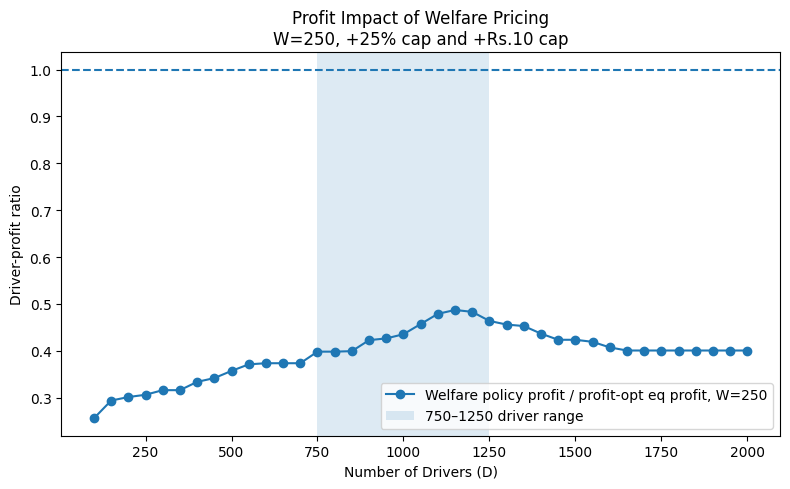

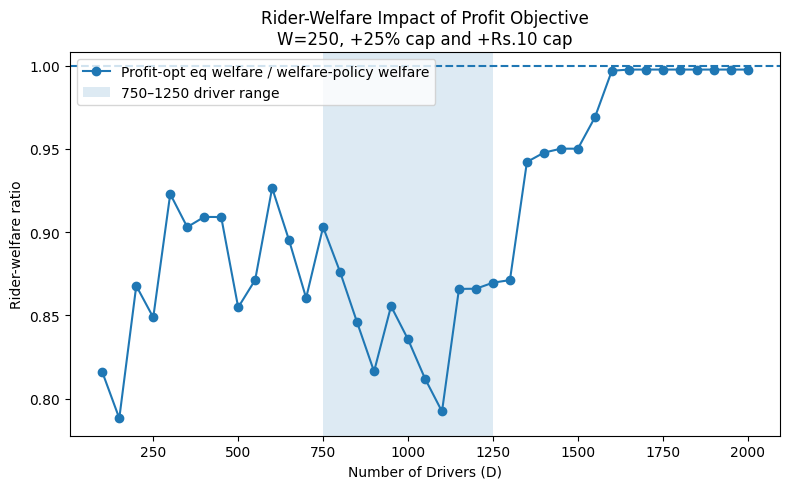

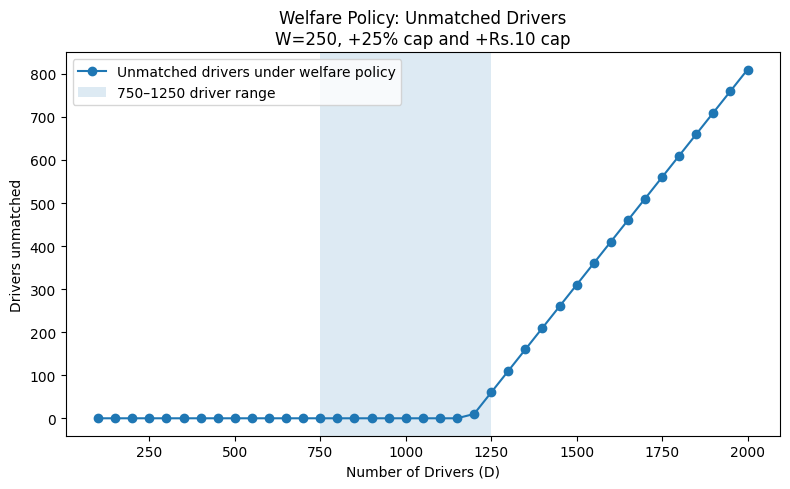

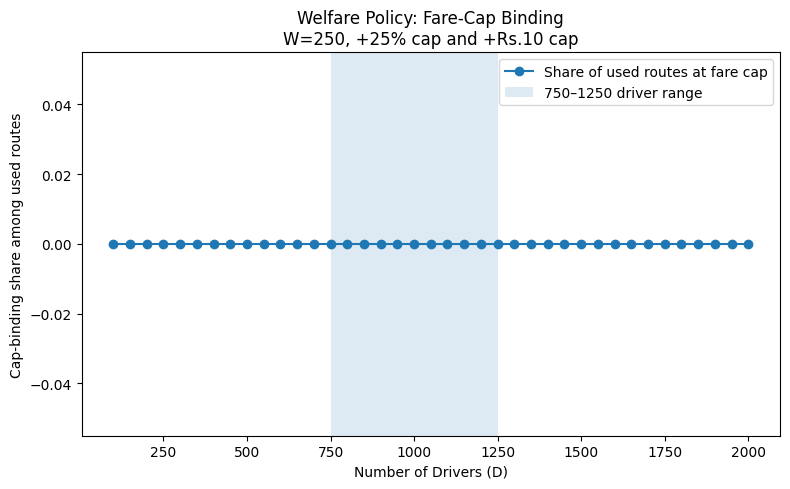

,D,W,cap_description,profit_eq_profit,profit_eq_profit_constructed,profit_eq_welfare,profit_eq_ppd,profit_eq_avg_fare,profit_eq_max_pct_fare_increase,welfare_policy_profit,...,welfare_policy_vs_profit_objective_welfare,welfareW_vs_profit_objective_welfare,welfare_loss_from_profit_eq_pct,profit_opt_profit,profit_opt_welfare,profit_opt_avg_fare,profit_opt_max_pct_fare_increase,profit_opt_vs_profit_eq_ratio,profit_opt_welfare_vs_welfare_policy,profit_opt_welfare_vs_welfareW
0,100.0,250.0,+25% cap and +Rs.10 cap,97664.324111,97664.324107,12782.109804,976.643241,21.875124,0.25,25000.0,...,1.225618,1.225618,0.184085,111836.416591,13873.147386,22.392663,0.25,1.145110,0.885558,0.885558
1,150.0,250.0,+25% cap and +Rs.10 cap,127640.176280,127640.176275,17367.932193,850.934509,22.001318,0.25,37500.0,...,1.268823,1.268823,0.211868,154171.595707,19499.033818,21.962854,0.25,1.207861,0.884838,0.884838
2,200.0,250.0,+25% cap and +Rs.10 cap,165955.975588,165955.975585,23719.190879,829.779878,20.103446,0.25,50000.0,...,1.152403,1.152403,0.132248,195582.690914,25944.221903,20.940511,0.25,1.178522,0.949154,0.949154
3,250.0,250.0,+25% cap and +Rs.10 cap,204134.681099,204134.680993,27192.278287,816.538724,20.853007,0.25,62500.0,...,1.178222,1.178222,0.151264,235465.900061,31266.778695,20.919070,0.25,1.153483,0.975911,0.975911
4,300.0,250.0,+25% cap and +Rs.10 cap,237357.048137,237357.048133,33708.075985,791.190160,20.511648,0.25,75000.0,...,1.083488,1.083488,0.077055,274186.342954,35569.050128,21.412681,0.25,1.155164,0.973899,0.973899


In [18]:
# ============================================================
# PRICE OPTIMIZATION — RIDER WELFARE / RESERVATION-WAGE BLOCK
# ============================================================
# This block is aligned with Sections 9.1 and 9.2 of the theory:
#
#   * Without a reservation wage, rider welfare is maximized at the minimum
#     fare c_i^F route-by-route because rider welfare is weakly decreasing in
#     fare for fixed allocation.
#
#   * With reservation wage W > 0, the welfare-maximizing fare at fixed x is
#     the smallest fare that delivers per-driver profit at least W.  The
#     resulting route value R_i^W(x) is allocated with a separable DP.
#
# It reuses the same capped fare set as Block 1 through priceopt_params.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_EPS = 1e-10


# ------------------------------------------------------------
# 0. Safety checks and helpers
# ------------------------------------------------------------

def _check_block1_priceopt_dependencies():
    required = [
        "build_priceopt_params",
        "fare_opt_profit_equilibrium",
        "centralized_profit_dp",
        "_separable_dp",
        "demand_at_q",
        "min_q_for_ppd",
        "ppd_at_q",
    ]

    missing = [name for name in required if name not in globals()]

    if missing:
        raise RuntimeError(
            "Missing required functions from the theory-correct Block 1: "
            + ", ".join(missing)
            + ". Run Block 1 before running this block."
        )



def _get_margin_col(par):
    if "q_upper" in par.columns:
        return "q_upper"
    if "M" in par.columns:
        return "M"
    raise ValueError("par must contain either q_upper or M.")



def _get_wtp_col(par):
    if "M_wtp" in par.columns:
        return "M_wtp"
    if "M" in par.columns:
        return "M"
    raise ValueError("par must contain either M_wtp or M.")



def _get_q_upper_array(par):
    return par[_get_margin_col(par)].to_numpy(dtype=float)



def _get_current_fares(par):
    if "rt_fare" not in par.columns:
        return np.full(len(par), np.nan)
    return par["rt_fare"].to_numpy(dtype=float)



def _max_pct_fare_increase(par, fares):
    fares = np.asarray(fares, dtype=float)
    current = _get_current_fares(par)

    pct = np.divide(
        fares - current,
        current,
        out=np.full(len(current), np.nan),
        where=current > 0,
    )
    pct = pct[np.isfinite(pct)]
    return float(np.max(pct)) if pct.size else np.nan



def _avg_pct_fare_increase_demand_weighted(par, fares, demand):
    fares = np.asarray(fares, dtype=float)
    demand = np.asarray(demand, dtype=float)
    current = _get_current_fares(par)

    pct = np.divide(
        fares - current,
        current,
        out=np.full(len(current), np.nan),
        where=current > 0,
    )

    good = np.isfinite(pct) & np.isfinite(demand) & (demand > 0)

    if not good.any():
        return np.nan

    return float(np.sum(pct[good] * demand[good]) / np.sum(demand[good]))



def _weighted_avg(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    s = np.sum(weights)
    return float(np.sum(values * weights) / s) if s > _EPS else np.nan



def _build_or_use_priceopt_params_for_block2(
    par=None,
    max_pct_above_current=None,
    max_abs_above_current=None,
    hard_fare_upper_col=None,
    sval_max_pct_above_current=0.25,
    audit_bounds=False,
):
    """
    Builds capped price-optimization parameters unless par is already provided.

    Best practice: pass par=priceopt_params from Block 1 so the profit and
    welfare experiments use exactly the same feasible fare set.
    """
    _check_block1_priceopt_dependencies()

    if par is not None:
        return par

    par = build_priceopt_params(
        df,
        max_pct_above_current=max_pct_above_current,
        max_abs_above_current=max_abs_above_current,
        hard_fare_upper_col=hard_fare_upper_col,
        sval_max_pct_above_current=sval_max_pct_above_current,
    )

    if audit_bounds and "audit_price_bounds" in globals():
        audit_price_bounds(par, top=10)

    return par



def _cap_description(max_pct_above_current=None, max_abs_above_current=None):
    parts = []

    if max_pct_above_current is not None:
        parts.append(f"+{100 * max_pct_above_current:.0f}% cap")

    if max_abs_above_current is not None:
        parts.append(f"+Rs.{max_abs_above_current:g} cap")

    if not parts:
        return "provided fare cap"

    return " and ".join(parts)


# ------------------------------------------------------------
# 1. Routewise rider-welfare value with optional reservation wage
# ------------------------------------------------------------

def reservation_value_at_x(par, i, x, W):
    """
    R_i^W(x): max rider welfare at allocation x subject to ppd >= W.

    Since rider welfare decreases with fare for fixed x, the optimal fare is
    the smallest q in [0, q_upper_i] satisfying ppd_i(x, q) >= W.

    W = 0 gives the no-reservation-wage welfare objective at the minimum fare.
    """
    x = float(max(x, 0.0))
    W = float(W)

    if x <= _EPS:
        return 0.0, 0.0

    if W <= _EPS:
        q = 0.0
    else:
        q = min_q_for_ppd(par, i, x, W)

    if not np.isfinite(q):
        return -np.inf, np.nan

    return demand_at_q(par, i, x, q), q



def welfare_reservation_dp(D, W=0.0, par=None, grid_step=5.0):
    """
    DP approximation to the rider-welfare optimum under reservation wage W.

    For W=0, this is the minimum-fare rider-welfare benchmark in Section 9.1.
    For W>0, this is the reservation-wage-constrained benchmark in Section 9.2.

    The planner may leave drivers unmatched, so sum_i x_i <= D.
    """
    W = float(W)
    D = float(D)

    if W < 0:
        raise ValueError("W must be nonnegative.")

    q_upper = _get_q_upper_array(par)
    Lambda = par["Lambda"].to_numpy(dtype=float)

    if W <= _EPS:
        caps = np.full(len(par), D, dtype=float)
    else:
        # Necessary feasibility bound: W*x_i <= q_upper_i * Lambda_i.
        caps = np.minimum(
            D,
            np.divide(
                q_upper * Lambda,
                W,
                out=np.zeros(len(par), dtype=float),
                where=W > 0,
            ),
        )
        caps = np.nan_to_num(caps, nan=0.0, posinf=D, neginf=0.0)

    def vf(i, x):
        return reservation_value_at_x(par, i, x, W)

    x, q, val, used_grid = _separable_dp(
        par,
        D,
        vf,
        grid_step=grid_step,
        caps=caps,
        at_most=True,
    )

    demand = np.zeros(len(par))
    profit = np.zeros(len(par))
    q_clean = np.zeros(len(par))

    for i in range(len(par)):
        if x[i] > 1e-8:
            if W <= _EPS:
                q_i = 0.0
            else:
                q_i = min_q_for_ppd(par, i, x[i], W)

            if not np.isfinite(q_i):
                # Infeasible at this grid allocation. Drop it.
                x[i] = 0.0
                q_clean[i] = 0.0
                demand[i] = 0.0
                profit[i] = 0.0
            else:
                q_clean[i] = q_i
                demand[i] = demand_at_q(par, i, x[i], q_clean[i])
                profit[i] = q_clean[i] * demand[i]

    q = q_clean
    fares = par["cost_per_rider"].to_numpy(dtype=float) + q

    used = x > 1e-8
    cap_bind = np.zeros(len(par), dtype=bool)
    cap_bind[used] = q[used] >= q_upper[used] - 1e-6

    return {
        "D": D,
        "W": W,
        "drivers_used": float(x.sum()),
        "drivers_unmatched": float(max(D - x.sum(), 0.0)),
        "total_welfare": float(demand.sum()),
        "total_profit": float(profit.sum()),
        "profit_per_used_driver": (
            float(profit.sum() / x.sum()) if x.sum() > _EPS else np.nan
        ),
        "alloc": x,
        "q": q,
        "fares": fares,
        "demand": demand,
        "profit_by_route": profit,
        "q_upper": q_upper,
        "route_caps": caps,
        "used_grid": used_grid,
        "dp_value": val,
        "fare_cap_bind_share_all_routes": float(np.mean(cap_bind)) if len(cap_bind) else np.nan,
        "fare_cap_bind_share_used_routes": (
            float(np.mean(cap_bind[used])) if used.any() else 0.0
        ),
        "max_pct_fare_increase": _max_pct_fare_increase(par, fares),
        "avg_pct_fare_increase_demand_weighted": (
            _avg_pct_fare_increase_demand_weighted(par, fares, demand)
        ),
        "avg_fare_demand_weighted": _weighted_avg(fares, demand),
        "current_fares": _get_current_fares(par),
    }


# Backward-compatible clearer alias.
welfare_priceopt_dp = welfare_reservation_dp


# ------------------------------------------------------------
# 2. Policy summaries
# ------------------------------------------------------------

def _policy_summary(
    par,
    policy_name,
    D,
    x,
    q,
    demand=None,
    total_profit_override=None,
    policy_type=None,
    W=np.nan,
):
    x = np.asarray(x, dtype=float)
    q = np.asarray(q, dtype=float)

    if demand is None:
        demand = np.array(
            [demand_at_q(par, i, x[i], q[i]) for i in range(len(par))],
            dtype=float,
        )
    else:
        demand = np.asarray(demand, dtype=float)

    profit = q * demand

    if total_profit_override is None:
        total_profit = float(profit.sum())
    else:
        total_profit = float(total_profit_override)

    fares = par["cost_per_rider"].to_numpy(dtype=float) + q
    q_upper = _get_q_upper_array(par)

    used = x > 1e-8
    cap_bind_used = (
        (q[used] >= q_upper[used] - 1e-6) if used.any() else np.array([], dtype=bool)
    )

    total_welfare = float(demand.sum())

    return {
        "policy": policy_name,
        "policy_type": policy_type,
        "D": float(D),
        "W": float(W) if np.isfinite(W) else np.nan,
        "drivers_used": float(x.sum()),
        "drivers_unmatched": float(max(float(D) - x.sum(), 0.0)),
        "routes_used": int(np.sum(used)),
        "total_rider_welfare": total_welfare,
        "total_driver_profit": total_profit,
        "profit_per_used_driver": (
            float(total_profit / x.sum()) if x.sum() > _EPS else np.nan
        ),
        "avg_fare_demand_weighted": _weighted_avg(fares, demand),
        "avg_per_rider_profit_demand_weighted": _weighted_avg(q, demand),
        "max_fare": float(np.nanmax(fares)) if len(fares) else np.nan,
        "max_pct_fare_increase": _max_pct_fare_increase(par, fares),
        "avg_pct_fare_increase_demand_weighted": (
            _avg_pct_fare_increase_demand_weighted(par, fares, demand)
        ),
        "fare_cap_bind_share_used_routes": (
            float(np.mean(cap_bind_used)) if used.any() else 0.0
        ),
    }


# ------------------------------------------------------------
# 3. W-sweep at a fixed D
# ------------------------------------------------------------

def run_cross_objective_comparison(
    D=1000,
    W_values=None,
    par=None,
    grid_step=5.0,
    allocation_rule="proportional",
    max_pct_above_current=None,
    max_abs_above_current=None,
    hard_fare_upper_col=None,
    sval_max_pct_above_current=0.25,
    audit_bounds=False,
    save_csv=True,
    csv_name="cross_objective_comparison.csv",
):
    """
    Cross-objective comparison at one driver supply D.

    For each reservation wage W:
      1. Solve the rider-welfare optimum using the smallest feasible fares
         that satisfy W.
      2. Compare its driver profit and rider welfare against the
         theory-correct price-optimized profit equilibrium.
    """
    par = _build_or_use_priceopt_params_for_block2(
        par=par,
        max_pct_above_current=max_pct_above_current,
        max_abs_above_current=max_abs_above_current,
        hard_fare_upper_col=hard_fare_upper_col,
        sval_max_pct_above_current=sval_max_pct_above_current,
        audit_bounds=audit_bounds,
    )

    if W_values is None:
        W_values = np.array([0, 50, 100, 150, 200, 250, 300, 350], dtype=float)

    cap_desc = _cap_description(max_pct_above_current, max_abs_above_current)

    profit_eq = fare_opt_profit_equilibrium(
        D,
        par,
        allocation_rule=allocation_rule,
    )

    profit_opt = centralized_profit_dp(
        D,
        par,
        grid_step=grid_step,
    )

    rows = []
    wr_policies = []

    for W in W_values:
        print(f"Running welfare/reservation policy for D={D}, W={W}...")

        wr = welfare_reservation_dp(
            D,
            W,
            par,
            grid_step=grid_step,
        )

        wr_policies.append(wr)

        row = _policy_summary(
            par,
            policy_name=f"Welfare objective, W={W:.1f}",
            D=D,
            x=wr["alloc"],
            q=wr["q"],
            demand=wr["demand"],
            total_profit_override=wr["total_profit"],
            policy_type="welfare_reservation" if W > _EPS else "welfare_minfare",
            W=W,
        )

        row["cap_description"] = cap_desc
        row["profit_eq_profit"] = profit_eq["total_profit_Dpi"]
        row["profit_eq_welfare"] = profit_eq["total_welfare"]

        row["profit_ratio_vs_profit_eq"] = (
            row["total_driver_profit"] / profit_eq["total_profit_Dpi"]
            if profit_eq["total_profit_Dpi"] > _EPS
            else np.nan
        )

        row["profit_loss_vs_profit_eq_pct"] = (
            1.0 - row["profit_ratio_vs_profit_eq"]
            if np.isfinite(row["profit_ratio_vs_profit_eq"])
            else np.nan
        )

        row["profit_eq_welfare_vs_welfare_policy"] = (
            profit_eq["total_welfare"] / row["total_rider_welfare"]
            if row["total_rider_welfare"] > _EPS
            else np.nan
        )

        row["welfare_policy_vs_profit_eq_welfare"] = (
            row["total_rider_welfare"] / profit_eq["total_welfare"]
            if profit_eq["total_welfare"] > _EPS
            else np.nan
        )

        rows.append(row)

    profit_eq_row = _policy_summary(
        par,
        policy_name="Profit objective: best equilibrium",
        D=D,
        x=profit_eq["alloc"],
        q=profit_eq["q"],
        demand=profit_eq["demand"],
        total_profit_override=profit_eq["total_profit_Dpi"],
        policy_type="profit_equilibrium",
        W=np.nan,
    )

    profit_eq_row["cap_description"] = cap_desc
    profit_eq_row["profit_eq_profit"] = profit_eq["total_profit_Dpi"]
    profit_eq_row["profit_eq_welfare"] = profit_eq["total_welfare"]
    profit_eq_row["profit_ratio_vs_profit_eq"] = 1.0
    profit_eq_row["profit_loss_vs_profit_eq_pct"] = 0.0
    profit_eq_row["profit_eq_welfare_vs_welfare_policy"] = np.nan
    profit_eq_row["welfare_policy_vs_profit_eq_welfare"] = np.nan

    profit_opt_row = _policy_summary(
        par,
        policy_name="Profit objective: centralized benchmark",
        D=D,
        x=profit_opt["alloc"],
        q=profit_opt["q"],
        demand=profit_opt["demand"],
        total_profit_override=profit_opt["total_profit"],
        policy_type="profit_centralized",
        W=np.nan,
    )

    profit_opt_row["cap_description"] = cap_desc
    profit_opt_row["profit_eq_profit"] = profit_eq["total_profit_Dpi"]
    profit_opt_row["profit_eq_welfare"] = profit_eq["total_welfare"]
    profit_opt_row["profit_ratio_vs_profit_eq"] = (
        profit_opt_row["total_driver_profit"] / profit_eq["total_profit_Dpi"]
        if profit_eq["total_profit_Dpi"] > _EPS
        else np.nan
    )
    profit_opt_row["profit_loss_vs_profit_eq_pct"] = np.nan
    profit_opt_row["profit_eq_welfare_vs_welfare_policy"] = np.nan
    profit_opt_row["welfare_policy_vs_profit_eq_welfare"] = np.nan

    comp = pd.DataFrame(rows + [profit_eq_row, profit_opt_row])

    if save_csv:
        comp.to_csv(csv_name, index=False)
        print(f"Saved {csv_name}")

    sweep = comp[comp["policy_type"].isin(["welfare_reservation", "welfare_minfare"])].copy()

    # Plot A: impact of welfare/reservation policy on profit.
    plt.figure(figsize=(8, 5))
    plt.plot(
        sweep["W"],
        sweep["profit_ratio_vs_profit_eq"],
        marker="o",
        label="Welfare-policy profit / profit-opt equilibrium profit",
    )
    plt.axhline(1.0, linestyle="--", label="profit-opt equilibrium")
    plt.xlabel("Reservation wage W (Rs. per driver)")
    plt.ylabel("Driver-profit ratio")
    plt.title(f"Profit Impact of Welfare Pricing\nD={D}, {cap_desc}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot B: impact of profit objective on rider welfare.
    plt.figure(figsize=(8, 5))
    plt.plot(
        sweep["W"],
        sweep["profit_eq_welfare_vs_welfare_policy"],
        marker="o",
        label="Profit-opt eq welfare / welfare-policy welfare",
    )
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Reservation wage W (Rs. per driver)")
    plt.ylabel("Rider-welfare ratio")
    plt.title(f"Rider-Welfare Impact of Profit Objective\nD={D}, {cap_desc}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot C: fare-cap binding diagnostic.
    plt.figure(figsize=(8, 5))
    plt.plot(
        sweep["W"],
        sweep["fare_cap_bind_share_used_routes"],
        marker="o",
        label="Share of used routes at fare cap",
    )
    plt.xlabel("Reservation wage W (Rs. per driver)")
    plt.ylabel("Cap-binding share among used routes")
    plt.title(f"Welfare Policy: Fare-Cap Binding\nD={D}, {cap_desc}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return comp, {
        "profit_eq": profit_eq,
        "profit_opt": profit_opt,
        "welfare_reservation": wr_policies,
    }, par


# ------------------------------------------------------------
# 4. Figure-3-style D-sweep at fixed reservation wage W
# ------------------------------------------------------------

def run_cross_objective_D_sweep(
    D_values=None,
    W=250,
    par=None,
    grid_step=5.0,
    allocation_rule="proportional",
    max_pct_above_current=None,
    max_abs_above_current=None,
    hard_fare_upper_col=None,
    sval_max_pct_above_current=0.25,
    audit_bounds=False,
    include_centralized_profit=True,
    save_csv=True,
    csv_name="cross_objective_D_sweep.csv",
):
    """
    D sweep for a fixed reservation wage W.

    Main ratios:
      profit_impact_ratio = welfare_policy_profit / profit_eq_profit
      profit_objective_welfare_ratio = profit_eq_welfare / welfare_policy_welfare
    """
    par = _build_or_use_priceopt_params_for_block2(
        par=par,
        max_pct_above_current=max_pct_above_current,
        max_abs_above_current=max_abs_above_current,
        hard_fare_upper_col=hard_fare_upper_col,
        sval_max_pct_above_current=sval_max_pct_above_current,
        audit_bounds=audit_bounds,
    )

    if D_values is None:
        D_values = np.arange(100, 2001, 50)

    cap_desc = _cap_description(max_pct_above_current, max_abs_above_current)
    rows = []

    for D in D_values:
        print(f"Running cross-objective D-sweep for D={D}, W={W}...")

        profit_eq = fare_opt_profit_equilibrium(
            D,
            par,
            allocation_rule=allocation_rule,
        )

        wr = welfare_reservation_dp(
            D,
            W,
            par,
            grid_step=grid_step,
        )

        row = {
            "D": float(D),
            "W": float(W),
            "cap_description": cap_desc,

            "profit_eq_profit": profit_eq["total_profit_Dpi"],
            "profit_eq_profit_constructed": profit_eq["total_profit"],
            "profit_eq_welfare": profit_eq["total_welfare"],
            "profit_eq_ppd": profit_eq["pi_eq"],
            "profit_eq_avg_fare": _weighted_avg(profit_eq["fares"], profit_eq["demand"]),
            "profit_eq_max_pct_fare_increase": _max_pct_fare_increase(par, profit_eq["fares"]),

            "welfare_policy_profit": wr["total_profit"],
            "welfare_policy_welfare": wr["total_welfare"],
            "welfare_policy_drivers_used": wr["drivers_used"],
            "welfare_policy_drivers_unmatched": wr["drivers_unmatched"],
            "welfare_policy_profit_per_used_driver": wr["profit_per_used_driver"],
            "welfare_policy_fare_cap_bind_share_used_routes": wr["fare_cap_bind_share_used_routes"],
            "welfare_policy_avg_fare": wr["avg_fare_demand_weighted"],
            "welfare_policy_max_pct_fare_increase": wr["max_pct_fare_increase"],

            # Backward-compatible column names from the previous block.
            "welfareW_profit": wr["total_profit"],
            "welfareW_welfare": wr["total_welfare"],
            "welfareW_drivers_used": wr["drivers_used"],
            "welfareW_drivers_unmatched": wr["drivers_unmatched"],
            "welfareW_profit_per_used_driver": wr["profit_per_used_driver"],
            "welfareW_fare_cap_bind_share_used_routes": wr["fare_cap_bind_share_used_routes"],
            "welfareW_avg_fare": wr["avg_fare_demand_weighted"],
            "welfareW_max_pct_fare_increase": wr["max_pct_fare_increase"],

            "profit_impact_ratio": (
                wr["total_profit"] / profit_eq["total_profit_Dpi"]
                if profit_eq["total_profit_Dpi"] > _EPS
                else np.nan
            ),
            "profit_loss_vs_profit_eq_pct": (
                1.0 - wr["total_profit"] / profit_eq["total_profit_Dpi"]
                if profit_eq["total_profit_Dpi"] > _EPS
                else np.nan
            ),
            "profit_objective_welfare_ratio": (
                profit_eq["total_welfare"] / wr["total_welfare"]
                if wr["total_welfare"] > _EPS
                else np.nan
            ),
            "welfare_policy_vs_profit_objective_welfare": (
                wr["total_welfare"] / profit_eq["total_welfare"]
                if profit_eq["total_welfare"] > _EPS
                else np.nan
            ),
            "welfareW_vs_profit_objective_welfare": (
                wr["total_welfare"] / profit_eq["total_welfare"]
                if profit_eq["total_welfare"] > _EPS
                else np.nan
            ),
            "welfare_loss_from_profit_eq_pct": (
                1.0 - profit_eq["total_welfare"] / wr["total_welfare"]
                if wr["total_welfare"] > _EPS
                else np.nan
            ),
        }

        if include_centralized_profit:
            profit_opt = centralized_profit_dp(
                D,
                par,
                grid_step=grid_step,
            )

            row.update({
                "profit_opt_profit": profit_opt["total_profit"],
                "profit_opt_welfare": profit_opt["total_welfare"],
                "profit_opt_avg_fare": _weighted_avg(profit_opt["fares"], profit_opt["demand"]),
                "profit_opt_max_pct_fare_increase": _max_pct_fare_increase(par, profit_opt["fares"]),
                "profit_opt_vs_profit_eq_ratio": (
                    profit_opt["total_profit"] / profit_eq["total_profit_Dpi"]
                    if profit_eq["total_profit_Dpi"] > _EPS
                    else np.nan
                ),
                "profit_opt_welfare_vs_welfare_policy": (
                    profit_opt["total_welfare"] / wr["total_welfare"]
                    if wr["total_welfare"] > _EPS
                    else np.nan
                ),
                # Backward-compatible old name.
                "profit_opt_welfare_vs_welfareW": (
                    profit_opt["total_welfare"] / wr["total_welfare"]
                    if wr["total_welfare"] > _EPS
                    else np.nan
                ),
            })

        rows.append(row)

    out = pd.DataFrame(rows)

    if save_csv:
        out.to_csv(csv_name, index=False)
        print(f"Saved {csv_name}")

    # Plot A: profit impact of welfare policy.
    plt.figure(figsize=(8, 5))
    plt.plot(
        out["D"],
        out["profit_impact_ratio"],
        marker="o",
        label=f"Welfare policy profit / profit-opt eq profit, W={W}",
    )
    plt.axhline(1.0, linestyle="--")
    plt.axvspan(750, 1250, alpha=0.15, label="750–1250 driver range")
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Driver-profit ratio")
    plt.title(f"Profit Impact of Welfare Pricing\nW={W}, {cap_desc}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot B: welfare impact of profit objective.
    plt.figure(figsize=(8, 5))
    plt.plot(
        out["D"],
        out["profit_objective_welfare_ratio"],
        marker="o",
        label="Profit-opt eq welfare / welfare-policy welfare",
    )
    plt.axhline(1.0, linestyle="--")
    plt.axvspan(750, 1250, alpha=0.15, label="750–1250 driver range")
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Rider-welfare ratio")
    plt.title(f"Rider-Welfare Impact of Profit Objective\nW={W}, {cap_desc}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot C: reservation-wage feasibility / unmatched drivers.
    plt.figure(figsize=(8, 5))
    plt.plot(
        out["D"],
        out["welfare_policy_drivers_unmatched"],
        marker="o",
        label="Unmatched drivers under welfare policy",
    )
    plt.axvspan(750, 1250, alpha=0.15, label="750–1250 driver range")
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Drivers unmatched")
    plt.title(f"Welfare Policy: Unmatched Drivers\nW={W}, {cap_desc}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot D: fare-cap binding.
    plt.figure(figsize=(8, 5))
    plt.plot(
        out["D"],
        out["welfare_policy_fare_cap_bind_share_used_routes"],
        marker="o",
        label="Share of used routes at fare cap",
    )
    plt.axvspan(750, 1250, alpha=0.15, label="750–1250 driver range")
    plt.xlabel("Number of Drivers (D)")
    plt.ylabel("Cap-binding share among used routes")
    plt.title(f"Welfare Policy: Fare-Cap Binding\nW={W}, {cap_desc}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return out


# ------------------------------------------------------------
# 5. Example D sweep using the SAME cap as Block 1
# ------------------------------------------------------------
# Recommended: reuse priceopt_params from Block 1. This guarantees that the
# profit and welfare blocks use the same demand-side S_val cap and fare cap.

cross_obj_D_sweep_df = run_cross_objective_D_sweep(
    D_values=np.arange(100, 2001, 50),
    W=250,
    par=priceopt_params if "priceopt_params" in globals() else None,
    max_pct_above_current=0.25,
    max_abs_above_current=10.0,
    grid_step=10.0,
    allocation_rule="proportional",
    include_centralized_profit=True,
    audit_bounds=False,
    save_csv=True,
    csv_name="cross_objective_D_sweep_W250_cap25pct_or_10rs_theory_correct.csv",
)

cross_obj_D_sweep_df.head()

Recomputing route-level fares for D=100.0, W=250.0...
Recomputing route-level fares for D=150.0, W=250.0...
Recomputing route-level fares for D=200.0, W=250.0...
Recomputing route-level fares for D=250.0, W=250.0...
Recomputing route-level fares for D=300.0, W=250.0...
Recomputing route-level fares for D=350.0, W=250.0...
Recomputing route-level fares for D=400.0, W=250.0...
Recomputing route-level fares for D=450.0, W=250.0...
Recomputing route-level fares for D=500.0, W=250.0...
Recomputing route-level fares for D=550.0, W=250.0...
Recomputing route-level fares for D=600.0, W=250.0...
Recomputing route-level fares for D=650.0, W=250.0...
Recomputing route-level fares for D=700.0, W=250.0...
Recomputing route-level fares for D=750.0, W=250.0...
Recomputing route-level fares for D=800.0, W=250.0...
Recomputing route-level fares for D=850.0, W=250.0...
Recomputing route-level fares for D=900.0, W=250.0...
Recomputing route-level fares for D=950.0, W=250.0...
Recomputing route-level fare

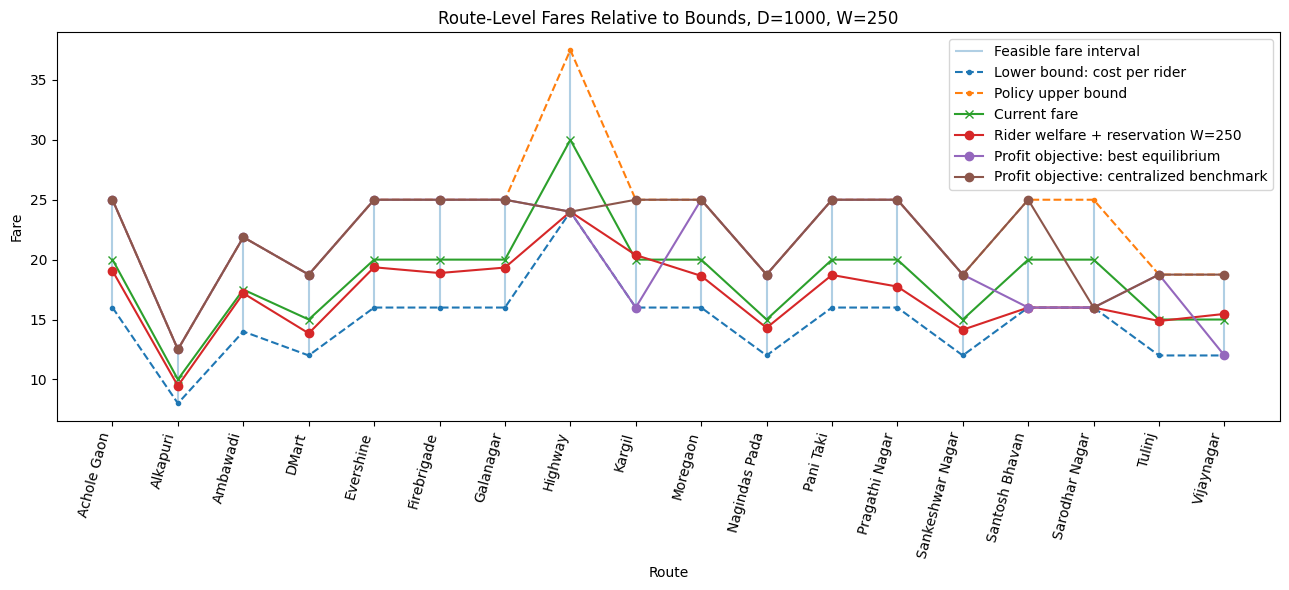

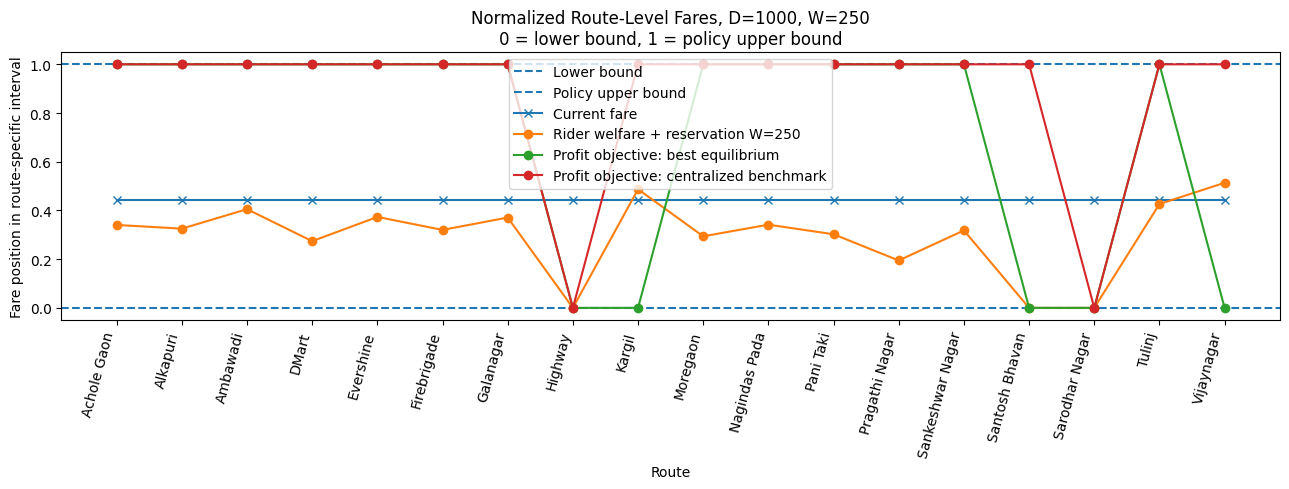

In [19]:
# ============================================================
# ROUTE-LEVEL FARE PLOTS FOR cross_obj_D_sweep_df
#
# Shows fares across all routes relative to lower/upper bounds
# under:
#   1. Rider-welfare + reservation-wage policy
#   2. Profit objective: best equilibrium
#   3. Profit objective: centralized benchmark
#
# Requires patched Block 1 and patched Block 2 to be loaded.
# Recommended: pass par=priceopt_params from your capped Block 1 run.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_EPS = 1e-10


# ------------------------------------------------------------
# 1. Helpers
# ------------------------------------------------------------

def _route_label_column(par):
    for c in ["rt_name", "route_name", "route", "name"]:
        if c in par.columns:
            return c
    return None


def _route_labels(par):
    col = _route_label_column(par)

    if col is None:
        return np.array([f"Route {i}" for i in range(len(par))], dtype=object)

    return par[col].astype(str).to_numpy()


def _fare_bounds_from_par(par):
    """
    Lower bound:
        cost_per_rider

    Policy upper bound:
        fare_upper

    Theory upper bound, when available:
        fare_upper_theory
    """
    if "cost_per_rider" not in par.columns:
        raise ValueError("par must contain cost_per_rider.")

    if "fare_upper" not in par.columns:
        raise ValueError(
            "par must contain fare_upper. Use the patched build_priceopt_params."
        )

    lower = par["cost_per_rider"].to_numpy(dtype=float)
    upper = par["fare_upper"].to_numpy(dtype=float)

    if "fare_upper_theory" in par.columns:
        theory_upper = par["fare_upper_theory"].to_numpy(dtype=float)
    else:
        theory_upper = upper.copy()

    if "rt_fare" in par.columns:
        current = par["rt_fare"].to_numpy(dtype=float)
    else:
        current = np.full(len(par), np.nan)

    return lower, upper, theory_upper, current


def _policy_route_df(
    par,
    policy_name,
    policy_type,
    D,
    W,
    x,
    q,
    demand=None,
):
    """
    Creates a route-level dataframe for one policy at one D,W pair.
    """
    x = np.asarray(x, dtype=float)
    q = np.asarray(q, dtype=float)

    if demand is None:
        demand = np.array(
            [demand_at_q(par, i, x[i], q[i]) for i in range(len(par))],
            dtype=float,
        )
    else:
        demand = np.asarray(demand, dtype=float)

    lower, upper, theory_upper, current = _fare_bounds_from_par(par)

    fare = lower + q
    width = upper - lower
    theory_width = theory_upper - lower

    fare_position = np.divide(
        fare - lower,
        width,
        out=np.full(len(par), np.nan),
        where=width > _EPS,
    )

    fare_position_clipped = np.clip(fare_position, 0.0, 1.0)

    current_position = np.divide(
        current - lower,
        width,
        out=np.full(len(par), np.nan),
        where=width > _EPS,
    )

    theory_position = np.divide(
        fare - lower,
        theory_width,
        out=np.full(len(par), np.nan),
        where=theory_width > _EPS,
    )

    route_profit = q * demand

    out = pd.DataFrame({
        "D": float(D),
        "W": float(W) if W is not None and np.isfinite(W) else np.nan,
        "policy": policy_name,
        "policy_type": policy_type,

        "route_idx": np.arange(len(par)),
        "route_label": _route_labels(par),

        "lower_bound": lower,
        "upper_bound": upper,
        "theory_upper_bound": theory_upper,
        "current_fare": current,

        "fare": fare,
        "q": q,
        "drivers": x,
        "demand": demand,
        "route_profit": route_profit,

        "fare_position": fare_position,
        "fare_position_clipped": fare_position_clipped,
        "fare_position_theory_bound": theory_position,
        "current_fare_position": current_position,

        "fare_minus_current": fare - current,
        "fare_pct_above_current": np.divide(
            fare - current,
            current,
            out=np.full(len(par), np.nan),
            where=current > _EPS,
        ),

        "at_lower_bound": np.isclose(fare, lower, atol=1e-6),
        "at_policy_upper_bound": np.isclose(fare, upper, atol=1e-6),
        "above_current_fare": fare > current + 1e-6,
    })

    return out


# ------------------------------------------------------------
# 2. Recompute route-level policies for cross_obj_D_sweep_df
# ------------------------------------------------------------

def build_route_fare_comparison_from_sweep(
    cross_obj_D_sweep_df,
    par=None,
    grid_step=5.0,
    allocation_rule="proportional",
    D_values=None,
    W_values=None,
    include_profit_equilibrium=True,
    include_profit_centralized=True,
):
    """
    Recomputes route-level fare vectors for the D,W pairs in cross_obj_D_sweep_df.

    Returns:
        fare_route_df

    Important:
        Use par=priceopt_params from the capped Block 1 run so the same fare cap
        is used here.
    """
    if par is None:
        if "priceopt_params" in globals():
            par = priceopt_params
        else:
            raise ValueError(
                "Pass par=priceopt_params from the capped Block 1 run."
            )

    if "D" not in cross_obj_D_sweep_df.columns:
        raise ValueError("cross_obj_D_sweep_df must contain a D column.")

    if "W" not in cross_obj_D_sweep_df.columns:
        raise ValueError("cross_obj_D_sweep_df must contain a W column.")

    pairs = cross_obj_D_sweep_df[["D", "W"]].drop_duplicates().copy()

    if D_values is not None:
        D_values = set(float(d) for d in D_values)
        pairs = pairs[pairs["D"].astype(float).isin(D_values)]

    if W_values is not None:
        W_values = set(float(w) for w in W_values)
        pairs = pairs[pairs["W"].astype(float).isin(W_values)]

    frames = []

    for _, row in pairs.iterrows():
        D = float(row["D"])
        W = float(row["W"])

        print(f"Recomputing route-level fares for D={D}, W={W}...")

        # Rider-welfare / reservation-wage policy.
        wr = welfare_reservation_dp(
            D=D,
            W=W,
            par=par,
            grid_step=grid_step,
        )

        frames.append(
            _policy_route_df(
                par=par,
                policy_name=f"Rider welfare + reservation W={W:g}",
                policy_type="welfare_reservation",
                D=D,
                W=W,
                x=wr["alloc"],
                q=wr["q"],
                demand=wr["demand"],
            )
        )

        # Profit-optimal best equilibrium policy.
        if include_profit_equilibrium:
            profit_eq = fare_opt_profit_equilibrium(
                D=D,
                par=par,
                allocation_rule=allocation_rule,
            )

            frames.append(
                _policy_route_df(
                    par=par,
                    policy_name="Profit objective: best equilibrium",
                    policy_type="profit_equilibrium",
                    D=D,
                    W=W,
                    x=profit_eq["alloc"],
                    q=profit_eq["q"],
                    demand=profit_eq["demand"],
                )
            )

        # Centralized profit benchmark.
        if include_profit_centralized:
            profit_opt = centralized_profit_dp(
                D=D,
                par=par,
                grid_step=grid_step,
            )

            frames.append(
                _policy_route_df(
                    par=par,
                    policy_name="Profit objective: centralized benchmark",
                    policy_type="profit_centralized",
                    D=D,
                    W=W,
                    x=profit_opt["alloc"],
                    q=profit_opt["q"],
                    demand=profit_opt["demand"],
                )
            )

    fare_route_df = pd.concat(frames, ignore_index=True)

    return fare_route_df


# ------------------------------------------------------------
# 3. Absolute fare plot across routes for one D
# ------------------------------------------------------------

def plot_route_fares_absolute(
    fare_route_df,
    D,
    W=None,
    policies=None,
    sort_by="route_idx",
    show_theory_upper=False,
    figsize=(13, 6),
):
    """
    Plots absolute fares route-by-route.

    The vertical interval is:
        lower_bound to upper_bound.

    Policy fare markers are overlaid.
    """
    D = float(D)

    sub = fare_route_df[np.isclose(fare_route_df["D"].astype(float), D)].copy()

    if W is not None:
        sub = sub[np.isclose(sub["W"].astype(float), float(W))].copy()

    if sub.empty:
        raise ValueError(f"No rows found for D={D}, W={W}.")

    if policies is None:
        policies = list(sub["policy"].drop_duplicates())

    bounds = (
        sub.drop_duplicates("route_idx")
        [[
            "route_idx",
            "route_label",
            "lower_bound",
            "upper_bound",
            "theory_upper_bound",
            "current_fare",
        ]]
        .copy()
    )

    if sort_by == "current_fare":
        order = bounds.sort_values("current_fare")["route_idx"].to_list()
    elif sort_by == "upper_bound":
        order = bounds.sort_values("upper_bound")["route_idx"].to_list()
    elif sort_by == "route_label":
        order = bounds.sort_values("route_label")["route_idx"].to_list()
    else:
        order = bounds.sort_values("route_idx")["route_idx"].to_list()

    bounds = bounds.set_index("route_idx").loc[order].reset_index()
    x = np.arange(len(bounds))

    plt.figure(figsize=figsize)

    # Bound interval for each route.
    plt.vlines(
        x,
        bounds["lower_bound"],
        bounds["upper_bound"],
        alpha=0.35,
        label="Feasible fare interval",
    )

    plt.plot(
        x,
        bounds["lower_bound"],
        linestyle="--",
        marker=".",
        label="Lower bound: cost per rider",
    )

    plt.plot(
        x,
        bounds["upper_bound"],
        linestyle="--",
        marker=".",
        label="Policy upper bound",
    )

    if show_theory_upper:
        plt.plot(
            x,
            bounds["theory_upper_bound"],
            linestyle=":",
            marker=".",
            label="Theoretical outside-option upper bound",
        )

    plt.plot(
        x,
        bounds["current_fare"],
        linestyle="-",
        marker="x",
        label="Current fare",
    )

    for policy in policies:
        psub = sub[sub["policy"] == policy].set_index("route_idx")

        if psub.empty:
            continue

        psub = psub.loc[order]

        plt.plot(
            x,
            psub["fare"],
            marker="o",
            label=policy,
        )

    plt.xticks(x, bounds["route_label"], rotation=75, ha="right")
    plt.xlabel("Route")
    plt.ylabel("Fare")
    title = f"Route-Level Fares Relative to Bounds, D={D:g}"
    if W is not None:
        title += f", W={float(W):g}"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Normalized fare-position plot across routes for one D
# ------------------------------------------------------------

def plot_route_fares_normalized(
    fare_route_df,
    D,
    W=None,
    policies=None,
    sort_by="route_idx",
    figsize=(13, 5),
):
    """
    Plots fares normalized to the route-specific policy interval:

        normalized fare position =
            (fare - lower_bound) / (upper_bound - lower_bound)

    Thus:
        0 = lower bound
        1 = policy upper bound
    """
    D = float(D)

    sub = fare_route_df[np.isclose(fare_route_df["D"].astype(float), D)].copy()

    if W is not None:
        sub = sub[np.isclose(sub["W"].astype(float), float(W))].copy()

    if sub.empty:
        raise ValueError(f"No rows found for D={D}, W={W}.")

    if policies is None:
        policies = list(sub["policy"].drop_duplicates())

    bounds = (
        sub.drop_duplicates("route_idx")
        [[
            "route_idx",
            "route_label",
            "current_fare_position",
            "current_fare",
            "lower_bound",
            "upper_bound",
        ]]
        .copy()
    )

    if sort_by == "current_fare":
        order = bounds.sort_values("current_fare")["route_idx"].to_list()
    elif sort_by == "upper_bound":
        order = bounds.sort_values("upper_bound")["route_idx"].to_list()
    elif sort_by == "route_label":
        order = bounds.sort_values("route_label")["route_idx"].to_list()
    else:
        order = bounds.sort_values("route_idx")["route_idx"].to_list()

    bounds = bounds.set_index("route_idx").loc[order].reset_index()
    x = np.arange(len(bounds))

    plt.figure(figsize=figsize)

    plt.axhline(0.0, linestyle="--", label="Lower bound")
    plt.axhline(1.0, linestyle="--", label="Policy upper bound")

    plt.plot(
        x,
        np.clip(bounds["current_fare_position"], 0.0, 1.0),
        linestyle="-",
        marker="x",
        label="Current fare",
    )

    for policy in policies:
        psub = sub[sub["policy"] == policy].set_index("route_idx")

        if psub.empty:
            continue

        psub = psub.loc[order]

        plt.plot(
            x,
            psub["fare_position_clipped"],
            marker="o",
            label=policy,
        )

    plt.xticks(x, bounds["route_label"], rotation=75, ha="right")
    plt.ylim(-0.05, 1.05)
    plt.xlabel("Route")
    plt.ylabel("Fare position in route-specific interval")
    title = f"Normalized Route-Level Fares, D={D:g}"
    if W is not None:
        title += f", W={float(W):g}"
    plt.title(title + "\n0 = lower bound, 1 = policy upper bound")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Heatmaps over the whole D sweep
# ------------------------------------------------------------

def plot_route_fare_position_heatmaps(
    fare_route_df,
    W=None,
    policies=None,
    sort_routes_by="route_idx",
    figsize_per_policy=(11, 7),
):
    """
    Makes one heatmap per policy.

    Rows:
        routes

    Columns:
        D values

    Cell:
        fare position in [0,1], where 0 is lower bound and 1 is policy upper bound.
    """
    sub = fare_route_df.copy()

    if W is not None:
        sub = sub[np.isclose(sub["W"].astype(float), float(W))].copy()

    if sub.empty:
        raise ValueError(f"No rows found for W={W}.")

    if policies is None:
        policies = list(sub["policy"].drop_duplicates())

    # Determine a consistent route order.
    route_info = (
        sub.drop_duplicates("route_idx")
        [[
            "route_idx",
            "route_label",
            "current_fare",
            "upper_bound",
        ]]
        .copy()
    )

    if sort_routes_by == "current_fare":
        route_info = route_info.sort_values("current_fare")
    elif sort_routes_by == "upper_bound":
        route_info = route_info.sort_values("upper_bound")
    elif sort_routes_by == "route_label":
        route_info = route_info.sort_values("route_label")
    else:
        route_info = route_info.sort_values("route_idx")

    route_order = route_info["route_idx"].to_list()
    route_labels = route_info["route_label"].to_list()

    for policy in policies:
        psub = sub[sub["policy"] == policy].copy()

        if psub.empty:
            continue

        pivot = psub.pivot_table(
            index="route_idx",
            columns="D",
            values="fare_position_clipped",
            aggfunc="first",
        )

        pivot = pivot.reindex(route_order)
        pivot = pivot.reindex(sorted(pivot.columns), axis=1)

        fig, ax = plt.subplots(figsize=figsize_per_policy)
        im = ax.imshow(
            pivot.values,
            aspect="auto",
            origin="lower",
            vmin=0.0,
            vmax=1.0,
        )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Fare position: 0 = lower bound, 1 = policy upper bound")

        d_values = list(pivot.columns)
        x_step = max(1, len(d_values) // 10)
        x_ticks = np.arange(0, len(d_values), x_step)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f"{d_values[i]:g}" for i in x_ticks], rotation=45)

        y_step = max(1, len(route_labels) // 25)
        y_ticks = np.arange(0, len(route_labels), y_step)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([route_labels[i] for i in y_ticks])

        ax.set_xlabel("Number of drivers D")
        ax.set_ylabel("Route")
        title = f"Fare Position Heatmap: {policy}"
        if W is not None:
            title += f", W={float(W):g}"
        ax.set_title(title)

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# 6. Cap-binding summary table
# ------------------------------------------------------------

def summarize_fare_positions(fare_route_df):
    """
    Useful diagnostic summary by policy and D.
    """
    summary = (
        fare_route_df
        .groupby(["policy", "D", "W"], dropna=False)
        .agg(
            avg_fare_position=("fare_position_clipped", "mean"),
            max_fare_position=("fare_position_clipped", "max"),
            share_routes_at_upper_bound=("at_policy_upper_bound", "mean"),
            share_routes_above_current=("above_current_fare", "mean"),
            avg_pct_above_current=("fare_pct_above_current", "mean"),
            demand_weighted_avg_fare=(
                "fare",
                lambda s: np.nan
            ),
        )
        .reset_index()
    )

    # Demand-weighted average fare is easier to compute separately.
    rows = []

    for keys, g in fare_route_df.groupby(["policy", "D", "W"], dropna=False):
        total_demand = g["demand"].sum()

        if total_demand > _EPS:
            demand_weighted_avg_fare = (
                (g["fare"] * g["demand"]).sum() / total_demand
            )
            demand_weighted_avg_position = (
                (g["fare_position_clipped"] * g["demand"]).sum() / total_demand
            )
        else:
            demand_weighted_avg_fare = np.nan
            demand_weighted_avg_position = np.nan

        rows.append({
            "policy": keys[0],
            "D": keys[1],
            "W": keys[2],
            "demand_weighted_avg_fare": demand_weighted_avg_fare,
            "demand_weighted_avg_fare_position": demand_weighted_avg_position,
        })

    weighted = pd.DataFrame(rows)

    summary = summary.drop(columns=["demand_weighted_avg_fare"])
    summary = summary.merge(weighted, on=["policy", "D", "W"], how="left")

    return summary

fare_route_df = build_route_fare_comparison_from_sweep(
    cross_obj_D_sweep_df=cross_obj_D_sweep_df[cross_obj_D_sweep_df['D']<2001],
    par=priceopt_params,
    grid_step=5.0,
    allocation_rule="proportional",
    include_profit_equilibrium=True,
    include_profit_centralized=True,
)

fare_route_df.head()

# Choose a D from your sweep, for example D=1000.
# If your cross_obj_D_sweep_df uses W=250, this will match that row.

plot_route_fares_absolute(
    fare_route_df,
    D=1000,
    W=250,
    sort_by="route_idx",
    show_theory_upper=False,
)

plot_route_fares_normalized(
    fare_route_df,
    D=1000,
    W=250,
    sort_by="route_idx",
)

## Price Optimization Pareto Frontier — Single Alpha-Grid Implementation

This section replaces the earlier multiple Pareto frontier attempts with one implementation.

Design choices:
- The only explicit frontier grid is `ALPHA_GRID`.
- There is no `Q_GRID_SIZE`, no `LAMBDA_GRID_SIZE`, and no separate Pareto driver-grid setting.
- The Pareto solver does **not** special-case the endpoints by calling the earlier benchmark solvers.
- The same scalarized solver is used for `alpha = 0`, `alpha = 1`, and every intermediate `alpha`.
- The endpoint validation runs the earlier benchmark solvers **separately** and checks whether the new Pareto solver reproduces the benchmark endpoints.

Endpoint interpretation:
- `alpha = 1` should reproduce the earlier profit-optimal price-optimization result.
- `alpha = 0` should reproduce the earlier rider-welfare / reservation-wage result.
- To make those two endpoints part of one continuous interpolation, the unified solver uses `effective_W(alpha) = (1 - alpha) * RESERVATION_WAGE`. Thus the full reservation-wage constraint is active at the welfare endpoint, and it disappears at the unconstrained profit endpoint.


Using existing priceopt_params.
Routes: 18
D = 1000
Reservation wage defining welfare endpoint W = 250
Alpha grid: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Solving alpha = 0.000 (effective W = 250.000)
Solving alpha = 0.100 (effective W = 225.000)
Solving alpha = 0.200 (effective W = 200.000)
Solving alpha = 0.300 (effective W = 175.000)
Solving alpha = 0.400 (effective W = 150.000)
Solving alpha = 0.500 (effective W = 125.000)
Solving alpha = 0.600 (effective W = 100.000)
Solving alpha = 0.700 (effective W = 75.000)
Solving alpha = 0.800 (effective W = 50.000)
Solving alpha = 0.900 (effective W = 25.000)
Solving alpha = 1.000 (effective W = 0.000)


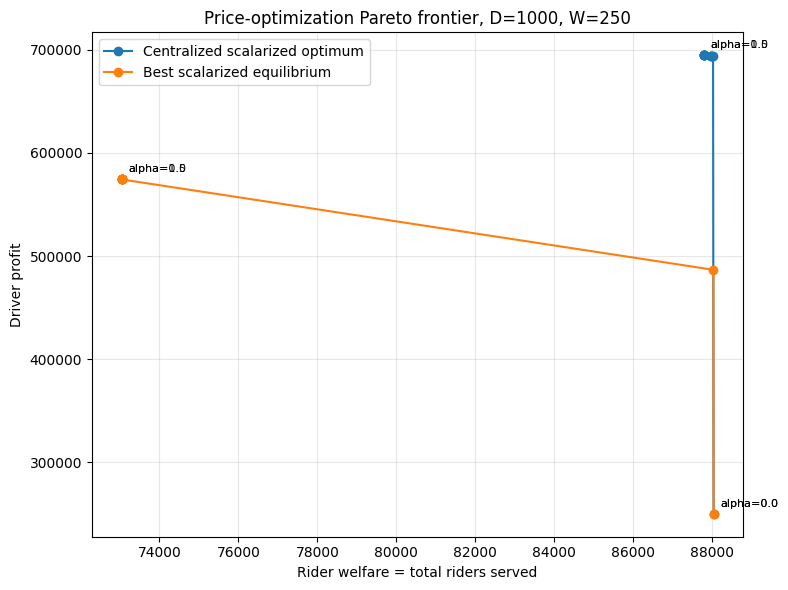

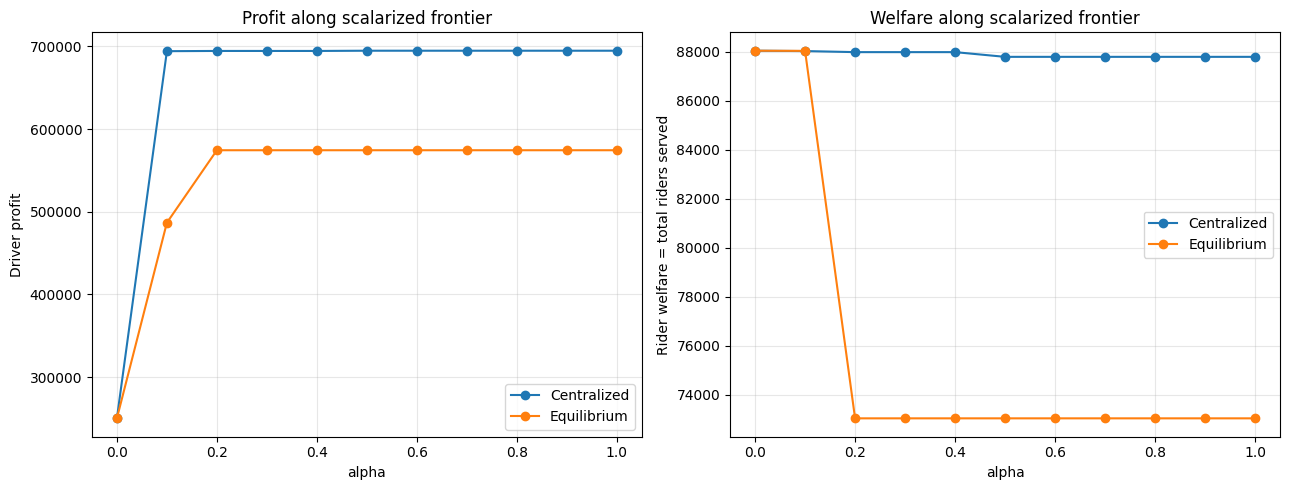

Endpoint validation against earlier code


,endpoint,metric,primary_check,pareto_value,earlier_code_value,abs_diff,rel_diff,pass
0,centralized alpha=1 vs centralized_profit_dp,total_profit,True,6.947465e+05,6.947465e+05,1.164153e-10,1.675652e-16,True
1,centralized alpha=1 vs centralized_profit_dp,total_welfare,False,8.778884e+04,8.778884e+04,0.000000e+00,0.000000e+00,True
2,centralized alpha=1 vs centralized_profit_dp,drivers_used,False,1.000000e+03,1.000000e+03,0.000000e+00,0.000000e+00,True
3,centralized alpha=1 vs centralized_profit_dp,drivers_unmatched,False,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,True
4,centralized alpha=0 vs welfare_reservation_dp,total_welfare,True,8.803885e+04,8.803885e+04,0.000000e+00,0.000000e+00,True
5,centralized alpha=0 vs welfare_reservation_dp,total_profit,False,2.500000e+05,2.500000e+05,6.111804e-10,2.444722e-15,True
6,centralized alpha=0 vs welfare_reservation_dp,drivers_used,False,1.000000e+03,1.000000e+03,0.000000e+00,0.000000e+00,True
7,centralized alpha=0 vs welfare_reservation_dp,drivers_unmatched,False,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,True
8,equilibrium alpha=1 vs fare_opt_profit_equilib...,common_ppd_or_pi_eq,True,5.743487e+02,5.743487e+02,0.000000e+00,0.000000e+00,True
9,equilibrium alpha=1 vs fare_opt_profit_equilib...,total_profit,True,5.743487e+05,5.743487e+05,0.000000e+00,0.000000e+00,True


scalar_pareto_summary


,solution_type,alpha,effective_W,lambda_common_ppd,objective_value,dp_value,total_profit,total_welfare,drivers_used,drivers_unmatched,routes_used,profit_per_used_driver
0,centralized_scalarized,0.0,250.0,NaN,88038.852710,88038.852710,250000.000000,88038.852710,1000.0,0.000000e+00,15,250.000000
1,centralized_scalarized,0.1,225.0,NaN,148640.682041,148640.682041,694186.631868,88024.465393,1000.0,0.000000e+00,16,694.186632
2,centralized_scalarized,0.2,200.0,NaN,209278.498396,209278.498396,694467.455903,87981.259019,1000.0,0.000000e+00,16,694.467456
3,centralized_scalarized,0.3,175.0,NaN,269927.118085,269927.118085,694467.455903,87981.259019,1000.0,0.000000e+00,16,694.467456
4,centralized_scalarized,0.4,150.0,NaN,330575.737773,330575.737773,694467.455903,87981.259019,1000.0,0.000000e+00,16,694.467456
5,centralized_scalarized,0.5,125.0,NaN,391267.662278,391267.662278,694746.488171,87788.836385,1000.0,0.000000e+00,16,694.746488
6,centralized_scalarized,0.6,100.0,NaN,451963.427457,451963.427457,694746.488171,87788.836385,1000.0,0.000000e+00,16,694.746488
7,centralized_scalarized,0.7,75.0,NaN,512659.192635,512659.192635,694746.488171,87788.836385,1000.0,0.000000e+00,16,694.746488
8,centralized_scalarized,0.8,50.0,NaN,573354.957814,573354.957814,694746.488171,87788.836385,1000.0,0.000000e+00,16,694.746488
9,centralized_scalarized,0.9,25.0,NaN,634050.722992,634050.722992,694746.488171,87788.836385,1000.0,0.000000e+00,16,694.746488


scalar_pareto_comparison


,alpha,effective_W,centralized_total_profit,centralized_total_welfare,centralized_drivers_used,centralized_drivers_unmatched,equilibrium_total_profit,equilibrium_total_welfare,equilibrium_drivers_used,equilibrium_drivers_unmatched,equilibrium_common_ppd,profit_gap_central_minus_eq,welfare_gap_central_minus_eq
0,0.0,250.0,250000.000000,88038.852710,1000.0,0.0,250000.000000,88038.852710,1000.0,0.000000e+00,250.000000,-6.111804e-10,0.000000
1,0.1,225.0,694186.631868,88024.465393,1000.0,0.0,486678.566765,88032.588129,1000.0,0.000000e+00,486.678567,2.075081e+05,-8.122735
2,0.2,200.0,694467.455903,87981.259019,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.201188e+05,14942.544464
3,0.3,175.0,694467.455903,87981.259019,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.201188e+05,14942.544464
4,0.4,150.0,694467.455903,87981.259019,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.201188e+05,14942.544464
5,0.5,125.0,694746.488171,87788.836385,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.203978e+05,14750.121830
6,0.6,100.0,694746.488171,87788.836385,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.203978e+05,14750.121830
7,0.7,75.0,694746.488171,87788.836385,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.203978e+05,14750.121830
8,0.8,50.0,694746.488171,87788.836385,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.203978e+05,14750.121830
9,0.9,25.0,694746.488171,87788.836385,1000.0,0.0,574348.651157,73038.714555,1000.0,9.999917e-08,574.348651,1.203978e+05,14750.121830


scalar_pareto_route_details


,solution_type,alpha,effective_W,lambda_common_ppd,route,alloc,q_margin,fare,demand,route_profit,profit_per_driver,cost_per_rider,current_fare,fare_upper,fare_position_in_bounds
0,centralized_scalarized,0.0,250.0,NaN,Achole Gaon,55.0,3.064663,19.064663,4486.627327,13750.000000,250.000000,16.0,20.0,25.000,0.340518
1,centralized_scalarized,0.0,250.0,NaN,Alkapuri,35.0,1.463524,9.463524,5978.718291,8750.000000,250.000000,8.0,10.0,12.500,0.325228
2,centralized_scalarized,0.0,250.0,NaN,Ambawadi,100.0,3.191246,17.191246,7833.929577,25000.000000,250.000000,14.0,17.5,21.875,0.405238
3,centralized_scalarized,0.0,250.0,NaN,DMart,45.0,1.848762,13.848762,6085.151681,11250.000000,250.000000,12.0,15.0,18.750,0.273891
4,centralized_scalarized,0.0,250.0,NaN,Evershine,115.0,3.360687,19.360687,8554.799575,28750.000000,250.000000,16.0,20.0,25.000,0.373410
5,centralized_scalarized,0.0,250.0,NaN,Firebrigade,60.0,2.880636,18.880636,5207.184170,15000.000000,250.000000,16.0,20.0,25.000,0.320071
6,centralized_scalarized,0.0,250.0,NaN,Galanagar,60.0,3.337605,19.337605,4494.241000,15000.000000,250.000000,16.0,20.0,25.000,0.370845
7,centralized_scalarized,0.0,250.0,NaN,Highway,0.0,0.000000,24.000000,0.000000,0.000000,NaN,24.0,30.0,37.500,0.000000
8,centralized_scalarized,0.0,250.0,NaN,Kargil,150.0,4.383238,20.383238,8555.319754,37500.000000,250.000000,16.0,20.0,25.000,0.487026
9,centralized_scalarized,0.0,250.0,NaN,Moregaon,55.0,2.644015,18.644015,5200.423484,13750.000000,250.000000,16.0,20.0,25.000,0.293779


In [20]:
# ============================================================
# SINGLE PARETO FRONTIER IMPLEMENTATION FOR PRICE OPTIMIZATION
# ============================================================
#
# For each alpha, the same solver path is used:
#
#     max_x,q   alpha * total_driver_profit
#             + (1 - alpha) * total_rider_welfare
#
# where total_rider_welfare is the total number of riders served.
#
# No endpoint branch calls centralized_profit_dp(),
# fare_opt_profit_equilibrium(), or welfare_reservation_dp().
#
# Those earlier functions are used only in the validation section below,
# where the endpoint outputs from this new solver are compared against the
# earlier benchmark code.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import minimize_scalar
except Exception as exc:
    raise ImportError(
        "This Pareto section needs scipy.optimize.minimize_scalar for the "
        "one-dimensional equilibrium common-PPD search."
    ) from exc


_EPS = 1e-10


# ============================================================
# 1. User-facing settings
# ============================================================

PARETO_D = 1000
RESERVATION_WAGE = 250.0

# This is the only explicit frontier grid.
ALPHA_GRID = np.linspace(0.0, 1.0, 11)

# Endpoint validation behavior.
RAISE_ON_ENDPOINT_TEST_FAILURE = True
PARETO_ENDPOINT_ATOL = 1e-5
PARETO_ENDPOINT_RTOL = 1e-6


# ============================================================
# 2. Dependency checks
# ============================================================

# These are helpers from the earlier price-optimization implementation.
# The Pareto solver reuses them so that it stays faithful to the existing
# demand, fare-bound, PPD, and DP logic.
_REQUIRED_SOLVER_OBJECTS = [
    "build_priceopt_params",
    "_separable_dp",
    "demand_at_q",
    "ppd_at_q",
    "min_q_for_ppd",
    "best_ppd_at_x",
    "candidate_prices_for_x",
    "_route_scalars",
    "_capacity_vector_for_ppd",
    "_demand_vector",
    "_best_ppd_vector",
]

_missing_solver = [
    name for name in _REQUIRED_SOLVER_OBJECTS
    if name not in globals()
]

# These are not used by the Pareto solver itself.  They are used only to test
# the alpha=0 and alpha=1 endpoints against the earlier benchmark code.
_REQUIRED_VALIDATION_OBJECTS = [
    "centralized_profit_dp",
    "fare_opt_profit_equilibrium",
]

_missing_validation = [
    name for name in _REQUIRED_VALIDATION_OBJECTS
    if name not in globals()
]

if "welfare_reservation_dp" not in globals():
    if "welfare_priceopt_dp" in globals():
        welfare_reservation_dp = welfare_priceopt_dp
    else:
        _missing_validation.append("welfare_reservation_dp")

if _missing_solver or _missing_validation:
    raise RuntimeError(
        "Please run the earlier price-optimization blocks before this Pareto section.\n"
        f"Missing solver helpers: {_missing_solver}\n"
        f"Missing validation benchmarks: {_missing_validation}"
    )


def _existing_priceopt_grid_step(default=5.0):
    """
    Use the allocation discretization already used by the earlier
    price-optimization DP functions.

    This is intentionally not a new Pareto tuning grid.
    """
    return float(globals().get("PRICEOPT_GRID_STEP", default))


def _clean_alpha_grid(alpha_grid):
    arr = np.asarray(alpha_grid, dtype=float)
    arr = arr[np.isfinite(arr)]
    arr = np.clip(arr, 0.0, 1.0)

    # Always include endpoints because endpoint validation depends on them.
    arr = np.concatenate([arr, np.array([0.0, 1.0])])
    arr = np.unique(np.round(arr, 12))

    return arr


def _effective_reservation_wage(alpha, W):
    """
    Reservation-wage level used inside the unified Pareto solver.

    This scaling makes the endpoints line up with the earlier benchmark code:
      * alpha = 0 applies the full welfare/reservation wage W.
      * alpha = 1 applies no reservation-wage constraint, so the profit
        endpoint is the earlier unconstrained profit optimum.

    Intermediate alpha values interpolate between those two endpoint models.
    """
    alpha = float(np.clip(alpha, 0.0, 1.0))
    return float((1.0 - alpha) * float(W))


ALPHA_GRID = _clean_alpha_grid(ALPHA_GRID)


# ============================================================
# 3. Build or reuse price-optimization parameters
# ============================================================

if "priceopt_params" in globals() and isinstance(priceopt_params, pd.DataFrame):
    par = priceopt_params.copy()
    print("Using existing priceopt_params.")
else:
    par = build_priceopt_params(
        df,
        max_pct_above_current=0.25,
        max_abs_above_current=10.0,
        hard_fare_upper_col=None,
        sval_max_pct_above_current=0.25,
    )
    priceopt_params = par.copy()
    print("Built priceopt_params using the earlier build_priceopt_params().")

print(f"Routes: {len(par)}")
print(f"D = {PARETO_D:g}")
print(f"Reservation wage defining welfare endpoint W = {RESERVATION_WAGE:g}")
print(f"Alpha grid: {ALPHA_GRID}")


# ============================================================
# 4. Formatting and result helpers
# ============================================================

def _pareto_route_labels(par):
    for col in ["rt_name", "route_name", "route", "name"]:
        if col in par.columns:
            return par[col].astype(str).to_numpy()

    return np.array([f"Route {i}" for i in range(len(par))], dtype=object)


def _pareto_objective(alpha, total_profit, total_welfare):
    alpha = float(alpha)
    return float(alpha * total_profit + (1.0 - alpha) * total_welfare)


def _pareto_solution_dict(
    D,
    par,
    alpha,
    effective_W,
    x,
    q,
    solution_type,
    dp_value=np.nan,
    lambda_common_ppd=np.nan,
):
    x = np.asarray(x, dtype=float)
    q = np.asarray(q, dtype=float)

    demand = _demand_vector(par, x, q)
    route_profit = q * demand
    fares = par["cost_per_rider"].to_numpy(dtype=float) + q

    ppd = np.divide(
        route_profit,
        x,
        out=np.full(len(x), np.nan),
        where=x > 1e-8,
    )

    used = x > 1e-8
    total_profit = float(route_profit.sum())
    total_welfare = float(demand.sum())
    drivers_used = float(x.sum())

    return {
        "D": float(D),
        "alpha": float(alpha),
        "effective_W": float(effective_W),
        "solution_type": solution_type,
        "lambda_common_ppd": (
            float(lambda_common_ppd)
            if np.isfinite(lambda_common_ppd)
            else np.nan
        ),
        "objective_value": _pareto_objective(alpha, total_profit, total_welfare),
        "dp_value": float(dp_value) if np.isfinite(dp_value) else np.nan,
        "total_profit": total_profit,
        "total_welfare": total_welfare,
        "drivers_used": drivers_used,
        "drivers_unmatched": float(max(float(D) - drivers_used, 0.0)),
        "routes_used": int(np.sum(used)),
        "profit_per_used_driver": (
            float(total_profit / drivers_used) if drivers_used > _EPS else np.nan
        ),
        "alloc": x,
        "q": q,
        "fares": fares,
        "demand": demand,
        "route_profit": route_profit,
        "profit_per_driver_by_route": ppd,
    }


def _pareto_route_detail_df(sol, par):
    labels = _pareto_route_labels(par)

    out = pd.DataFrame({
        "solution_type": sol["solution_type"],
        "alpha": sol["alpha"],
        "effective_W": sol["effective_W"],
        "lambda_common_ppd": sol["lambda_common_ppd"],
        "route": labels,
        "alloc": sol["alloc"],
        "q_margin": sol["q"],
        "fare": sol["fares"],
        "demand": sol["demand"],
        "route_profit": sol["route_profit"],
        "profit_per_driver": sol["profit_per_driver_by_route"],
    })

    out["cost_per_rider"] = par["cost_per_rider"].to_numpy(dtype=float)

    if "rt_fare" in par.columns:
        out["current_fare"] = par["rt_fare"].to_numpy(dtype=float)

    if "fare_upper" in par.columns:
        out["fare_upper"] = par["fare_upper"].to_numpy(dtype=float)
    elif "q_upper" in par.columns:
        out["fare_upper"] = out["cost_per_rider"] + par["q_upper"].to_numpy(dtype=float)
    elif "M" in par.columns:
        out["fare_upper"] = out["cost_per_rider"] + par["M"].to_numpy(dtype=float)
    else:
        out["fare_upper"] = np.nan

    denom = out["fare_upper"] - out["cost_per_rider"]

    out["fare_position_in_bounds"] = np.divide(
        out["fare"] - out["cost_per_rider"],
        denom,
        out=np.full(len(out), np.nan),
        where=np.abs(denom) > _EPS,
    )

    return out


def _pareto_summary_df(solutions):
    rows = []

    for sol in solutions:
        rows.append({
            "solution_type": sol["solution_type"],
            "alpha": sol["alpha"],
            "effective_W": sol["effective_W"],
            "lambda_common_ppd": sol["lambda_common_ppd"],
            "objective_value": sol["objective_value"],
            "dp_value": sol["dp_value"],
            "total_profit": sol["total_profit"],
            "total_welfare": sol["total_welfare"],
            "drivers_used": sol["drivers_used"],
            "drivers_unmatched": sol["drivers_unmatched"],
            "routes_used": sol["routes_used"],
            "profit_per_used_driver": sol["profit_per_used_driver"],
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values(["solution_type", "alpha"]).reset_index(drop=True)


# ============================================================
# 5. Route-level scalarized fare choice
# ============================================================

def _max_q_for_ppd(par, i, x, target_ppd, tol=1e-7, max_iter=45):
    """
    Largest q in [0, q_upper_i] such that ppd_at_q(i, x, q) >= target_ppd.

    The earlier min_q_for_ppd() gives the lower crossing.  For scalarized
    objectives, especially when alpha is close to one, the route optimum can
    sit at the upper reservation-wage boundary, so this helper checks that
    boundary without introducing a q grid.
    """
    target_ppd = float(target_ppd)
    q_upper = _route_scalars(par, i)[0]

    if target_ppd <= tol:
        return float(q_upper)

    best_val, q_star = best_ppd_at_x(par, i, x)

    if best_val + 5 * tol < target_ppd or q_upper <= _EPS:
        return np.nan

    if ppd_at_q(par, i, x, q_upper) >= target_ppd - tol:
        return float(q_upper)

    lo = float(q_star)
    hi = float(q_upper)

    if lo > hi:
        lo, hi = hi, lo

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)

        if ppd_at_q(par, i, x, mid) >= target_ppd:
            lo = mid
        else:
            hi = mid

    return float(lo)


def _scalarized_q_candidates(par, i, x, alpha, effective_W):
    """
    Candidate q values for:

        max_q [alpha*q + (1-alpha)] * demand_at_q(i, x, q)

    subject to:

        ppd_at_q(i, x, q) >= effective_W

    This uses analytic candidates and existing route helpers. It does not use
    a q grid.
    """
    q_upper, M_wtp, a0, b0, Lam, k, H, _, active = _route_scalars(par, i)

    if (not active) or x <= _EPS or q_upper <= _EPS:
        return np.array([0.0])

    alpha = float(alpha)
    beta = 1.0 - alpha
    x = float(x)

    cands = [0.0, q_upper]

    # Existing profit-objective candidates from the earlier code.
    cands.extend(list(candidate_prices_for_x(par, i, x)))

    # The vectorized profit DP used earlier also included the x=0
    # right-limit profit candidate in every row of its table.  It is usually
    # dominated for x > 0, but including it here makes the alpha=1 route table
    # use exactly the same candidate set as centralized_profit_dp().
    if b0 > _EPS:
        cands.append(0.5 * (M_wtp + a0 / b0))

    # Saturation boundary. Demand is saturated for q <= M_wtp - H/x.
    cands.append(M_wtp - H / x)

    # Scalarized FOC on the non-saturated quadratic branch.
    #
    # On that branch:
    #     demand(q) = a0*x + b0*(M_wtp-q)*x*(1-x/k)
    #               = C - B*q
    #
    # Route objective:
    #     (alpha*q + beta) * (C - B*q)
    #
    # Interior FOC for alpha > 0:
    #     q = (alpha*C - beta*B) / (2*alpha*B)
    if alpha > _EPS and x < k - 1e-9:
        B = b0 * x * (1.0 - x / k)
        C = a0 * x + B * M_wtp

        if B > _EPS:
            cands.append((alpha * C - beta * B) / (2.0 * alpha * B))

    # Reservation-wage lower and upper boundaries.
    if effective_W > _EPS:
        q_low = min_q_for_ppd(par, i, x, effective_W)
        q_high = _max_q_for_ppd(par, i, x, effective_W)

        if np.isfinite(q_low):
            cands.append(q_low)

        if np.isfinite(q_high):
            cands.append(q_high)

    cands = np.array(cands, dtype=float)
    cands = cands[np.isfinite(cands)]
    cands = np.clip(cands, 0.0, q_upper)
    cands = np.unique(np.round(cands, 12))

    return cands


def _scalarized_route_value_at_x(par, i, x, alpha, effective_W):
    """
    Route value for every alpha, including the endpoints.

        max_q [alpha*q + (1-alpha)] * demand_at_q(i, x, q)

    subject to:

        ppd_at_q(i, x, q) >= effective_W
    """
    x = float(x)

    if x <= _EPS:
        return 0.0, 0.0

    best_val = -np.inf
    best_q = np.nan

    for q in _scalarized_q_candidates(par, i, x, alpha, effective_W):
        d = demand_at_q(par, i, x, q)
        route_profit = q * d
        ppd = route_profit / x if x > _EPS else 0.0

        if ppd + 1e-7 < effective_W:
            continue

        val = (float(alpha) * q + (1.0 - float(alpha))) * d

        if val > best_val:
            best_val = float(val)
            best_q = float(q)

    return best_val, best_q


def _scalarized_capacity_bound(par, D, effective_W):
    """
    Necessary route capacity bound implied by the effective reservation wage.
    This mirrors the earlier welfare/reservation block but is used for every
    alpha through effective_W(alpha).
    """
    D = float(D)

    if effective_W <= _EPS:
        return np.full(len(par), D, dtype=float)

    if "q_upper" in par.columns:
        q_upper = par["q_upper"].to_numpy(dtype=float)
    else:
        q_upper = par["M"].to_numpy(dtype=float)

    Lambda = par["Lambda"].to_numpy(dtype=float)

    caps = np.minimum(
        D,
        np.divide(
            q_upper * Lambda,
            effective_W,
            out=np.zeros(len(par), dtype=float),
            where=effective_W > 0,
        ),
    )

    return np.nan_to_num(caps, nan=0.0, posinf=D, neginf=0.0)


# ============================================================
# 6. Centralized Pareto point
# ============================================================

def centralized_scalarized_priceopt(D, alpha, W=150.0, par=None):
    """
    Centralized scalarized Pareto point.

    This function intentionally uses the same computation for alpha=0,
    alpha=1, and intermediate alpha.  Endpoint checking happens later.
    """
    if par is None:
        par = priceopt_params

    D = float(D)
    alpha = float(alpha)
    effective_W = _effective_reservation_wage(alpha, W)
    grid_step = _existing_priceopt_grid_step()

    def value_func(i, x):
        return _scalarized_route_value_at_x(par, i, x, alpha, effective_W)

    x, q, val, used_grid = _separable_dp(
        par=par,
        D=D,
        value_func=value_func,
        grid_step=grid_step,
        caps=_scalarized_capacity_bound(par, D, effective_W),
        at_most=True,
    )

    return _pareto_solution_dict(
        D=D,
        par=par,
        alpha=alpha,
        effective_W=effective_W,
        x=x,
        q=q,
        dp_value=val,
        solution_type="centralized_scalarized",
        lambda_common_ppd=np.nan,
    )


# ============================================================
# 7. Equilibrium Pareto point
# ============================================================

def _pareto_equilibrium_lambda_upper(D, par, tol=1e-7, max_iter=55):
    """
    Independently compute the largest common PPD lambda such that the route
    capacity vector can accommodate all D drivers.

    This duplicates the equilibrium search logic instead of calling
    fare_opt_profit_equilibrium(), so the endpoint test is a real test.
    """
    D = float(D)
    n = len(par)

    if D <= _EPS or n == 0:
        return 0.0, np.zeros(n, dtype=float)

    right_limit_ppd, _ = _best_ppd_vector(par, np.zeros(n, dtype=float))
    right_limit_ppd = np.nan_to_num(
        right_limit_ppd,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    hi = float(np.max(right_limit_ppd)) if len(right_limit_ppd) else 0.0

    if hi <= _EPS:
        return 0.0, np.zeros(n, dtype=float)

    lo = 0.0
    best_caps = np.zeros(n, dtype=float)

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        caps = _capacity_vector_for_ppd(par, D, mid, tol=tol)

        if caps.sum() >= D - tol:
            lo = mid
            best_caps = caps
        else:
            hi = mid

    caps = _capacity_vector_for_ppd(par, D, lo, tol=tol)

    if caps.sum() < D - 1e-5 and best_caps.sum() >= D - 1e-5:
        caps = best_caps

    return float(lo), caps


def _pareto_allocate_from_capacities(D, caps, allocation_rule="proportional", par_for_scores=None):
    """
    Local copy of the equilibrium capacity-allocation step.

    This intentionally does not call fare_opt_profit_equilibrium(); it only
    implements the same capacity-to-allocation mapping so the alpha=1
    equilibrium endpoint can be tested as an independent reconstruction.
    """
    D = float(D)
    caps = np.asarray(caps, dtype=float)
    caps = np.nan_to_num(caps, nan=0.0, posinf=D, neginf=0.0)
    caps = np.clip(caps, 0.0, D)

    if D <= _EPS or caps.sum() <= _EPS:
        return np.zeros_like(caps)

    if caps.sum() <= D + 1e-7:
        return caps.copy()

    rule = str(allocation_rule).lower()

    if rule in {"proportional", "prop"}:
        return caps * (D / caps.sum())

    if rule in {"greedy", "fill", "sequential"}:
        score_par = priceopt_params if par_for_scores is None else par_for_scores
        scores, _ = _best_ppd_vector(score_par, np.zeros(len(caps), dtype=float))
        order = np.argsort(-scores)
        x = np.zeros_like(caps)
        remaining = D

        for i in order:
            if remaining <= _EPS:
                break
            take = min(caps[i], remaining)
            x[i] = take
            remaining -= take

        return x

    if rule in {"equal", "waterfill", "water_fill"}:
        x = np.zeros_like(caps)
        remaining = D
        active = caps > _EPS

        while remaining > 1e-8 and active.any():
            share = remaining / active.sum()
            idx = np.where(active)[0]
            take = np.minimum(caps[idx] - x[idx], share)
            x[idx] += take
            remaining = D - x.sum()
            active = (caps - x) > 1e-8

        return x

    raise ValueError("allocation_rule must be 'proportional', 'greedy', or 'equal'.")


def _equilibrium_solution_from_caps(
    D,
    alpha,
    lam,
    effective_W,
    par,
    caps,
    allocation_rule="proportional",
    tol=1e-7,
):
    """
    Construct a supportable equilibrium allocation directly from capacities.

    At alpha=1 this is the important endpoint candidate: the scalarized
    objective is lambda * D, so no grid search over the allocation is needed.
    The same candidate is also kept for intermediate alphas, where it gives the
    profit-equilibrium endpoint of the feasible equilibrium set.
    """
    D = float(D)
    alpha = float(alpha)
    lam = float(lam)
    effective_W = float(effective_W)

    if lam + 1e-8 < effective_W:
        return None

    x = _pareto_allocate_from_capacities(
        D=D,
        caps=caps,
        allocation_rule=allocation_rule,
        par_for_scores=par,
    )

    # If lambda is strictly above the outside option, all drivers must be
    # active.  If lambda equals the outside option, unmatched drivers are okay.
    if lam > effective_W + 1e-8 and x.sum() < D - 1e-5:
        return None

    q = np.zeros(len(par), dtype=float)

    for i in range(len(par)):
        if x[i] <= 1e-8:
            q[i] = 0.0
            continue

        q_i = min_q_for_ppd(par, i, x[i], lam, tol=tol)

        if not np.isfinite(q_i):
            best_val, q_star = best_ppd_at_x(par, i, x[i])
            if best_val + 1e-6 >= lam:
                q_i = q_star
            else:
                x[i] = 0.0
                q_i = 0.0

        q[i] = q_i

    return _pareto_solution_dict(
        D=D,
        par=par,
        alpha=alpha,
        effective_W=effective_W,
        x=x,
        q=q,
        dp_value=np.nan,
        solution_type="equilibrium_scalarized",
        lambda_common_ppd=lam,
    )


def _equilibrium_scalarized_at_lambda_dp(D, alpha, lam, effective_W, par, caps_override=None):
    """
    Best scalarized equilibrium allocation at a fixed common PPD lambda.

    For lambda > effective_W, all D drivers must be active.
    For lambda = effective_W, drivers may be unmatched because they can receive
    the outside option / reservation wage.
    """
    D = float(D)
    alpha = float(alpha)
    lam = float(lam)
    effective_W = float(effective_W)
    grid_step = _existing_priceopt_grid_step()

    if caps_override is None:
        caps = _capacity_vector_for_ppd(par, D, lam)
    else:
        caps = np.asarray(caps_override, dtype=float)
        caps = np.nan_to_num(caps, nan=0.0, posinf=D, neginf=0.0)
        caps = np.clip(caps, 0.0, D)

    at_most = lam <= effective_W + 1e-8

    if (not at_most) and caps.sum() < D - 1e-6:
        return None

    def value_func(i, x):
        if x <= _EPS:
            return 0.0, 0.0

        q = min_q_for_ppd(par, i, x, lam)

        if not np.isfinite(q):
            # Numerical endpoint fallback, mirroring the earlier equilibrium
            # benchmark: if the best attainable PPD is effectively lambda, use
            # the profit-maximizing fare rather than dropping the grid point.
            best_val, q_star = best_ppd_at_x(par, i, x)
            if best_val + 1e-6 >= lam:
                q = q_star
            else:
                return -np.inf, 0.0

        d = demand_at_q(par, i, x, q)
        val = (alpha * q + (1.0 - alpha)) * d

        return float(val), float(q)

    x, q, val, used_grid = _separable_dp(
        par=par,
        D=D,
        value_func=value_func,
        grid_step=grid_step,
        caps=caps,
        at_most=at_most,
    )

    if not np.isfinite(val):
        return None

    return _pareto_solution_dict(
        D=D,
        par=par,
        alpha=alpha,
        effective_W=effective_W,
        x=x,
        q=q,
        dp_value=val,
        solution_type="equilibrium_scalarized",
        lambda_common_ppd=lam,
    )


def equilibrium_scalarized_priceopt(D, alpha, W=150.0, par=None):
    """
    Best scalarized driver-equilibrium Pareto point.

    This function intentionally uses the same computation for alpha=0,
    alpha=1, and intermediate alpha.  It does not call the earlier
    fare_opt_profit_equilibrium() endpoint benchmark.
    """
    if par is None:
        par = priceopt_params

    D = float(D)
    alpha = float(alpha)
    effective_W = _effective_reservation_wage(alpha, W)

    lam_upper, caps_upper = _pareto_equilibrium_lambda_upper(D, par)
    lam_lo = effective_W
    lam_hi = max(float(lam_upper), float(lam_lo))

    cache = {}

    def eval_solution(lam, caps_override=None):
        key = (round(float(lam), 8), caps_override is not None)

        if key not in cache:
            cache[key] = _equilibrium_scalarized_at_lambda_dp(
                D=D,
                alpha=alpha,
                lam=float(lam),
                effective_W=effective_W,
                par=par,
                caps_override=caps_override,
            )

        return cache[key]

    # If the all-active equilibrium upper bound is below the effective
    # reservation wage, the only relevant equilibrium point is lambda=effective_W
    # with unmatched drivers allowed.
    if lam_upper <= lam_lo + 1e-8:
        return eval_solution(lam_lo)

    def objective_to_minimize(lam):
        sol = eval_solution(lam)

        if sol is None:
            return 1e30

        return -sol["objective_value"]

    res = minimize_scalar(
        objective_to_minimize,
        bounds=(lam_lo, lam_hi),
        method="bounded",
        options={"xatol": 1e-5},
    )

    # Always check endpoints.  This is important because the DP objective in
    # lambda can be kinked, and because alpha=0 and alpha=1 should be validated
    # at the exact endpoint values.
    candidate_lams = [lam_lo, lam_hi, 0.5 * (lam_lo + lam_hi)]

    if res.success and np.isfinite(res.x):
        candidate_lams.append(float(res.x))

    candidates = []

    # Always include the profit-equilibrium endpoint as a continuous capacity
    # allocation candidate.  This is not an endpoint call to the old benchmark;
    # it reconstructs the candidate from the same primitive capacity objects.
    # It makes alpha=1 robust because the alpha=1 equilibrium objective is
    # lambda * D, so the largest feasible lambda must win.
    if lam_upper >= lam_lo - 1e-8:
        cont_sol = _equilibrium_solution_from_caps(
            D=D,
            alpha=alpha,
            lam=lam_upper,
            effective_W=effective_W,
            par=par,
            caps=caps_upper,
            allocation_rule="proportional",
        )
        if cont_sol is not None:
            candidates.append(cont_sol)

    for lam in candidate_lams:
        caps_override = caps_upper if abs(float(lam) - float(lam_upper)) <= 1e-7 else None
        sol = eval_solution(lam, caps_override=caps_override)

        if sol is not None:
            candidates.append(sol)

    if not candidates:
        return None

    # Objective first.  The tie-break follows the endpoint being approached:
    # low-alpha welfare points prefer the lower common PPD / fewer active
    # drivers when the welfare objective is tied; high-alpha profit points
    # prefer the higher common PPD and more active drivers.
    lambda_sign = 1.0 if alpha >= 0.5 else -1.0
    driver_sign = -1.0 if alpha >= 0.5 else 1.0

    return max(
        candidates,
        key=lambda s: (
            s["objective_value"],
            lambda_sign * (
                s["lambda_common_ppd"]
                if np.isfinite(s["lambda_common_ppd"])
                else -np.inf
            ),
            driver_sign * s["drivers_unmatched"],
        ),
    )


# ============================================================
# 8. Run frontier and make tables
# ============================================================

def run_priceopt_pareto_frontier(D, W, alpha_grid, par=None):
    if par is None:
        par = priceopt_params

    alpha_grid = _clean_alpha_grid(alpha_grid)

    centralized_solutions = []
    equilibrium_solutions = []

    for alpha in alpha_grid:
        print(
            f"Solving alpha = {alpha:.3f} "
            f"(effective W = {_effective_reservation_wage(alpha, W):.3f})"
        )

        centralized_solutions.append(
            centralized_scalarized_priceopt(
                D=D,
                alpha=alpha,
                W=W,
                par=par,
            )
        )

        eq_sol = equilibrium_scalarized_priceopt(
            D=D,
            alpha=alpha,
            W=W,
            par=par,
        )

        if eq_sol is not None:
            equilibrium_solutions.append(eq_sol)
        else:
            print(f"  No feasible equilibrium solution found for alpha={alpha:.3f}")

    all_solutions = centralized_solutions + equilibrium_solutions

    summary = _pareto_summary_df(all_solutions)

    route_details = pd.concat(
        [_pareto_route_detail_df(sol, par) for sol in all_solutions],
        ignore_index=True,
    )

    central_df = summary[
        summary["solution_type"] == "centralized_scalarized"
    ].copy()

    eq_df = summary[
        summary["solution_type"] == "equilibrium_scalarized"
    ].copy()

    comparison = central_df[
        ["alpha", "effective_W", "total_profit", "total_welfare", "drivers_used", "drivers_unmatched"]
    ].rename(columns={
        "total_profit": "centralized_total_profit",
        "total_welfare": "centralized_total_welfare",
        "drivers_used": "centralized_drivers_used",
        "drivers_unmatched": "centralized_drivers_unmatched",
    })

    comparison = comparison.merge(
        eq_df[
            [
                "alpha",
                "total_profit",
                "total_welfare",
                "drivers_used",
                "drivers_unmatched",
                "lambda_common_ppd",
            ]
        ].rename(columns={
            "total_profit": "equilibrium_total_profit",
            "total_welfare": "equilibrium_total_welfare",
            "drivers_used": "equilibrium_drivers_used",
            "drivers_unmatched": "equilibrium_drivers_unmatched",
            "lambda_common_ppd": "equilibrium_common_ppd",
        }),
        on="alpha",
        how="outer",
    )

    comparison["profit_gap_central_minus_eq"] = (
        comparison["centralized_total_profit"]
        - comparison["equilibrium_total_profit"]
    )

    comparison["welfare_gap_central_minus_eq"] = (
        comparison["centralized_total_welfare"]
        - comparison["equilibrium_total_welfare"]
    )

    return {
        "centralized_solutions": centralized_solutions,
        "equilibrium_solutions": equilibrium_solutions,
        "summary": summary,
        "route_details": route_details,
        "comparison": comparison,
    }


pareto_results = run_priceopt_pareto_frontier(
    D=PARETO_D,
    W=RESERVATION_WAGE,
    alpha_grid=ALPHA_GRID,
    par=par,
)

centralized_solutions = pareto_results["centralized_solutions"]
equilibrium_solutions = pareto_results["equilibrium_solutions"]
scalar_pareto_summary = pareto_results["summary"]
scalar_pareto_route_details = pareto_results["route_details"]
scalar_pareto_comparison = pareto_results["comparison"]


# ============================================================
# 9. Endpoint validation against earlier code
# ============================================================

def _get_pareto_solution(solutions, alpha):
    if not solutions:
        return None

    idx = int(np.argmin([abs(sol["alpha"] - float(alpha)) for sol in solutions]))
    sol = solutions[idx]

    if abs(sol["alpha"] - float(alpha)) > 1e-8:
        return None

    return sol


def _validation_row(
    endpoint,
    metric,
    pareto_value,
    benchmark_value,
    atol,
    rtol,
    primary=True,
):
    if pareto_value is None or benchmark_value is None:
        return {
            "endpoint": endpoint,
            "metric": metric,
            "primary_check": bool(primary),
            "pareto_value": pareto_value,
            "earlier_code_value": benchmark_value,
            "abs_diff": np.nan,
            "rel_diff": np.nan,
            "pass": False,
        }

    pareto_value = float(pareto_value)
    benchmark_value = float(benchmark_value)

    abs_diff = abs(pareto_value - benchmark_value)
    rel_diff = abs_diff / max(abs(benchmark_value), _EPS)
    passed = (abs_diff <= atol) or (rel_diff <= rtol)

    return {
        "endpoint": endpoint,
        "metric": metric,
        "primary_check": bool(primary),
        "pareto_value": pareto_value,
        "earlier_code_value": benchmark_value,
        "abs_diff": abs_diff,
        "rel_diff": rel_diff,
        "pass": bool(passed),
    }


def validate_pareto_endpoints(
    D,
    W,
    par,
    centralized_solutions,
    equilibrium_solutions,
    atol=1e-5,
    rtol=1e-6,
    raise_on_fail=True,
):
    """
    Check that alpha=0 and alpha=1 reproduce the earlier benchmark code.

    Important:
      The Pareto solver has already been run without endpoint special-casing.
      The earlier functions are called here only as independent benchmarks.
    """
    grid_step = _existing_priceopt_grid_step()

    c_alpha0 = _get_pareto_solution(centralized_solutions, 0.0)
    c_alpha1 = _get_pareto_solution(centralized_solutions, 1.0)
    e_alpha0 = _get_pareto_solution(equilibrium_solutions, 0.0)
    e_alpha1 = _get_pareto_solution(equilibrium_solutions, 1.0)

    earlier_c_profit = centralized_profit_dp(D=D, par=par, grid_step=grid_step)
    earlier_welfare = welfare_reservation_dp(D=D, W=W, par=par, grid_step=grid_step)
    earlier_eq_profit = fare_opt_profit_equilibrium(D=D, par=par)

    checks = []

    def add(endpoint, metric, pareto_value, benchmark_value, primary=True):
        checks.append(
            _validation_row(
                endpoint=endpoint,
                metric=metric,
                pareto_value=pareto_value,
                benchmark_value=benchmark_value,
                atol=atol,
                rtol=rtol,
                primary=primary,
            )
        )

    # Centralized alpha = 1: the primary benchmark is total profit.
    add(
        "centralized alpha=1 vs centralized_profit_dp",
        "total_profit",
        None if c_alpha1 is None else c_alpha1["total_profit"],
        earlier_c_profit["total_profit"],
        primary=True,
    )
    add(
        "centralized alpha=1 vs centralized_profit_dp",
        "total_welfare",
        None if c_alpha1 is None else c_alpha1["total_welfare"],
        earlier_c_profit["total_welfare"],
        primary=False,
    )
    add(
        "centralized alpha=1 vs centralized_profit_dp",
        "drivers_used",
        None if c_alpha1 is None else c_alpha1["drivers_used"],
        earlier_c_profit["drivers_used"],
        primary=False,
    )
    add(
        "centralized alpha=1 vs centralized_profit_dp",
        "drivers_unmatched",
        None if c_alpha1 is None else c_alpha1["drivers_unmatched"],
        earlier_c_profit["drivers_unmatched"],
        primary=False,
    )

    # Centralized alpha = 0: the primary benchmark is total riders served.
    add(
        "centralized alpha=0 vs welfare_reservation_dp",
        "total_welfare",
        None if c_alpha0 is None else c_alpha0["total_welfare"],
        earlier_welfare["total_welfare"],
        primary=True,
    )
    add(
        "centralized alpha=0 vs welfare_reservation_dp",
        "total_profit",
        None if c_alpha0 is None else c_alpha0["total_profit"],
        earlier_welfare["total_profit"],
        primary=False,
    )
    add(
        "centralized alpha=0 vs welfare_reservation_dp",
        "drivers_used",
        None if c_alpha0 is None else c_alpha0["drivers_used"],
        earlier_welfare["drivers_used"],
        primary=False,
    )
    add(
        "centralized alpha=0 vs welfare_reservation_dp",
        "drivers_unmatched",
        None if c_alpha0 is None else c_alpha0["drivers_unmatched"],
        earlier_welfare["drivers_unmatched"],
        primary=False,
    )

    # Equilibrium alpha = 1: the primary benchmarks are common PPD and profit.
    add(
        "equilibrium alpha=1 vs fare_opt_profit_equilibrium",
        "common_ppd_or_pi_eq",
        None if e_alpha1 is None else e_alpha1["lambda_common_ppd"],
        earlier_eq_profit.get("pi_eq", np.nan),
        primary=True,
    )
    add(
        "equilibrium alpha=1 vs fare_opt_profit_equilibrium",
        "total_profit",
        None if e_alpha1 is None else e_alpha1["total_profit"],
        earlier_eq_profit["total_profit"],
        primary=True,
    )
    add(
        "equilibrium alpha=1 vs fare_opt_profit_equilibrium",
        "total_profit_Dpi",
        (
            None if e_alpha1 is None
            else e_alpha1["lambda_common_ppd"] * e_alpha1["D"]
        ),
        earlier_eq_profit.get("total_profit_Dpi", np.nan),
        primary=True,
    )
    add(
        "equilibrium alpha=1 vs fare_opt_profit_equilibrium",
        "total_welfare",
        None if e_alpha1 is None else e_alpha1["total_welfare"],
        earlier_eq_profit["total_welfare"],
        primary=False,
    )
    add(
        "equilibrium alpha=1 vs fare_opt_profit_equilibrium",
        "drivers_used",
        None if e_alpha1 is None else e_alpha1["drivers_used"],
        earlier_eq_profit["drivers_used"],
        primary=False,
    )
    add(
        "equilibrium alpha=1 vs fare_opt_profit_equilibrium",
        "drivers_unmatched",
        None if e_alpha1 is None else e_alpha1["drivers_unmatched"],
        earlier_eq_profit["drivers_unmatched"],
        primary=False,
    )

    # Equilibrium alpha = 0 should recover the welfare/reservation endpoint.
    add(
        "equilibrium alpha=0 vs welfare_reservation_dp",
        "total_welfare",
        None if e_alpha0 is None else e_alpha0["total_welfare"],
        earlier_welfare["total_welfare"],
        primary=True,
    )
    add(
        "equilibrium alpha=0 vs welfare_reservation_dp",
        "total_profit",
        None if e_alpha0 is None else e_alpha0["total_profit"],
        earlier_welfare["total_profit"],
        primary=False,
    )
    add(
        "equilibrium alpha=0 vs welfare_reservation_dp",
        "drivers_used",
        None if e_alpha0 is None else e_alpha0["drivers_used"],
        earlier_welfare["drivers_used"],
        primary=False,
    )
    add(
        "equilibrium alpha=0 vs welfare_reservation_dp",
        "drivers_unmatched",
        None if e_alpha0 is None else e_alpha0["drivers_unmatched"],
        earlier_welfare["drivers_unmatched"],
        primary=False,
    )

    validation = pd.DataFrame(checks)

    primary_failed = (
        validation["primary_check"]
        & (~validation["pass"])
    )

    if raise_on_fail and bool(primary_failed.any()):
        display(validation)
        raise AssertionError(
            "One or more primary Pareto endpoint checks failed. Inspect "
            "endpoint_validation before using the frontier results."
        )

    return validation


endpoint_validation = validate_pareto_endpoints(
    D=PARETO_D,
    W=RESERVATION_WAGE,
    par=par,
    centralized_solutions=centralized_solutions,
    equilibrium_solutions=equilibrium_solutions,
    atol=PARETO_ENDPOINT_ATOL,
    rtol=PARETO_ENDPOINT_RTOL,
    raise_on_fail=RAISE_ON_ENDPOINT_TEST_FAILURE,
)


# ============================================================
# 10. Plots and display
# ============================================================

central_df = scalar_pareto_summary[
    scalar_pareto_summary["solution_type"] == "centralized_scalarized"
].copy()

eq_df = scalar_pareto_summary[
    scalar_pareto_summary["solution_type"] == "equilibrium_scalarized"
].copy()

plt.figure(figsize=(8, 6))

plt.plot(
    central_df["total_welfare"],
    central_df["total_profit"],
    marker="o",
    label="Centralized scalarized optimum",
)

if len(eq_df) > 0:
    plt.plot(
        eq_df["total_welfare"],
        eq_df["total_profit"],
        marker="o",
        label="Best scalarized equilibrium",
    )

for plot_df in [central_df, eq_df]:
    if len(plot_df) == 0:
        continue

    for a in [0.0, 0.5, 1.0]:
        idx = (plot_df["alpha"] - a).abs().idxmin()
        row = plot_df.loc[idx]
        plt.annotate(
            f"alpha={row['alpha']:.1f}",
            (row["total_welfare"], row["total_profit"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

plt.xlabel("Rider welfare = total riders served")
plt.ylabel("Driver profit")
plt.title(f"Price-optimization Pareto frontier, D={PARETO_D:g}, W={RESERVATION_WAGE:g}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    central_df["alpha"],
    central_df["total_profit"],
    marker="o",
    label="Centralized",
)

if len(eq_df) > 0:
    axes[0].plot(
        eq_df["alpha"],
        eq_df["total_profit"],
        marker="o",
        label="Equilibrium",
    )

axes[0].set_xlabel("alpha")
axes[0].set_ylabel("Driver profit")
axes[0].set_title("Profit along scalarized frontier")
axes[0].grid(True, alpha=0.3)
axes[0].legend()


axes[1].plot(
    central_df["alpha"],
    central_df["total_welfare"],
    marker="o",
    label="Centralized",
)

if len(eq_df) > 0:
    axes[1].plot(
        eq_df["alpha"],
        eq_df["total_welfare"],
        marker="o",
        label="Equilibrium",
    )

axes[1].set_xlabel("alpha")
axes[1].set_ylabel("Rider welfare = total riders served")
axes[1].set_title("Welfare along scalarized frontier")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


print("Endpoint validation against earlier code")
display(endpoint_validation)

print("scalar_pareto_summary")
display(scalar_pareto_summary)

print("scalar_pareto_comparison")
display(scalar_pareto_comparison)

print("scalar_pareto_route_details")
display(scalar_pareto_route_details.head(25))


In [ ]:
central_df.to_csv('central_df.csv')

In [ ]:
eq_df.to_csv('eq_df_alpha.csv')

## Improvement Ratio

Solving alpha=0.00
Solving alpha=0.10
Solving alpha=0.20
Solving alpha=0.30
Solving alpha=0.40
Solving alpha=0.50
Solving alpha=0.60
Solving alpha=0.70
Solving alpha=0.80
Solving alpha=0.90
Solving alpha=1.00


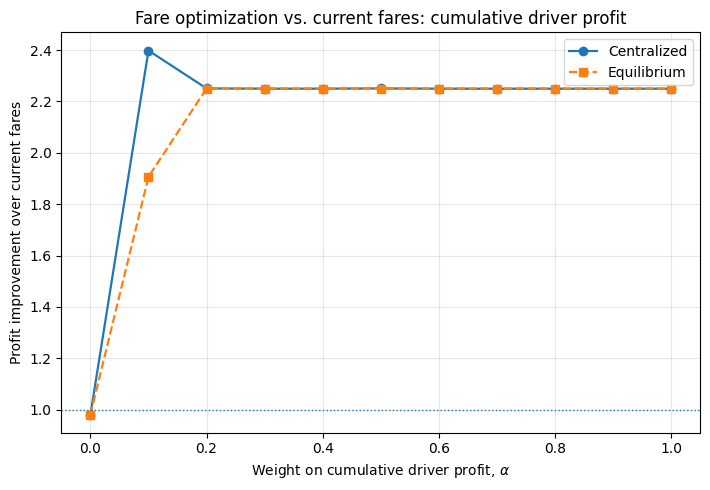

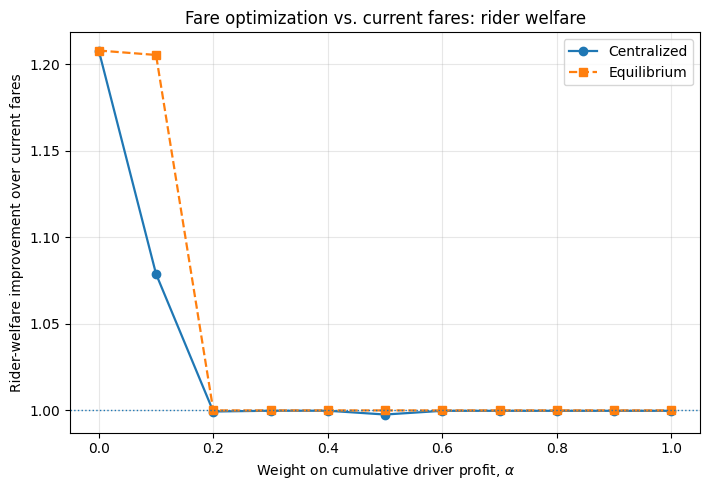

,alpha,centralized_profit_improvement,centralized_welfare_improvement,equilibrium_profit_improvement,equilibrium_welfare_improvement
0,0.0,0.981095,1.207846,0.981095,1.207846
1,0.1,2.397983,1.078809,1.906554,1.205287
2,0.2,2.250561,0.999358,2.250000,1.000000
3,0.3,2.249562,0.999808,2.250000,1.000000
4,0.4,2.249562,0.999808,2.250000,1.000000
5,0.5,2.250466,0.997622,2.250000,1.000000
6,0.6,2.249490,0.999768,2.250000,1.000000
7,0.7,2.249490,0.999768,2.250000,1.000000
8,0.8,2.249490,0.999768,2.250000,1.000000
9,0.9,2.249490,0.999768,2.250000,1.000000


In [21]:
# ============================================================
# Compare fare-optimized outcomes to current-fare outcomes
# as a function of alpha, with reservation wage W = 250
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
D_COMPARE = 1000.0
W_COMPARE = 250.0
ALPHA_GRID_COMPARE = np.round(np.arange(0.0, 1.0 + 1e-9, 0.1), 2)
OUTPUT_DIR = Path(".")

# Allocation grid for DP computations
PRICEOPT_GRID_STEP = 5.0
CURRENT_FARE_GRID_STEP = 5.0

# Required objects from earlier notebook cells
_required = [
    "build_priceopt_params",
    "centralized_scalarized_priceopt",
    "equilibrium_scalarized_priceopt",
    "_separable_dp",
    "_demand_vector",
    "_pareto_solution_dict",
    "_effective_reservation_wage",
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(f"Run the earlier price-optimization definition cells first. Missing: {_missing}")

# Rebuild price optimization params to match the paper setting:
# fares can increase by at most 25% above current fares.
_priceopt_input_df = processed_route_filtered.copy() if "processed_route_filtered" in globals() else df.copy()
priceopt_params = build_priceopt_params(
    _priceopt_input_df,
    max_pct_above_current=0.25,
    max_abs_above_current=10.0,
    sval_max_pct_above_current=0.25,
)

# -----------------------------
# Helper functions
# -----------------------------

def _safe_ratio(num, den):
    return np.divide(
        np.asarray(num, dtype=float),
        np.asarray(den, dtype=float),
        out=np.full_like(np.asarray(num, dtype=float), np.nan),
        where=np.asarray(den, dtype=float) > 1e-10,
    )


def current_fare_q_vector(par):
    """
    Current fare expressed as margin q_i = fare_i - cost_i,
    which is the q object used in the price-optimization code.
    """
    current_fares = par["rt_fare"].to_numpy(dtype=float)
    costs = par["cost_per_rider"].to_numpy(dtype=float)
    return np.maximum(current_fares - costs, 0.0)


def current_fare_centralized_scalarized(D, alpha, W, par, grid_step=5.0):
    """
    Centralized allocation with current fixed fares.

    The planner chooses driver allocations x_i, but fares are fixed at current values.
    The objective is the same alpha-scalarized objective used in the fare-optimization
    exercise:
        alpha * cumulative driver profit + (1-alpha) * rider welfare.
    """
    D = float(D)
    alpha = float(alpha)
    effective_W = _effective_reservation_wage(alpha, W)
    q_current = current_fare_q_vector(par)

    def value_func(i, x):
        x = float(x)
        if x <= 1e-10:
            return 0.0

        q_i = q_current[i]
        demand_i = float(_demand_vector(par.iloc[[i]], np.array([x]), np.array([q_i]))[0])
        profit_i = q_i * demand_i

        # Reservation-wage feasibility condition, when active.
        if effective_W > 1e-10 and profit_i + 1e-8 < effective_W * x:
            return -1e30

        return alpha * profit_i + (1.0 - alpha) * demand_i

    x, _, val, used_grid = _separable_dp(
        par=par,
        D=D,
        value_func=value_func,
        grid_step=grid_step,
        caps=np.full(len(par), D),
        at_most=True,
    )

    q = np.where(x > 1e-10, q_current, 0.0)

    return _pareto_solution_dict(
        D=D,
        par=par,
        alpha=alpha,
        effective_W=effective_W,
        x=x,
        q=q,
        solution_type="current_fare_centralized_scalarized",
        dp_value=val,
        lambda_common_ppd=np.nan,
    )


def _current_fare_capacity_at_lambda(par, D, q_current, lam, grid_step=5.0):
    """
    For fixed current fares, compute the largest allocation x_i on each route
    such that profit-per-driver is at least lam.
    """
    caps = np.zeros(len(par), dtype=float)
    grid = np.arange(0.0, D + 1e-9, grid_step)

    for i in range(len(par)):
        q_i = q_current[i]
        if q_i <= 1e-10:
            caps[i] = 0.0
            continue

        feasible_x = []
        for x in grid:
            if x <= 1e-10:
                continue

            demand_i = float(_demand_vector(par.iloc[[i]], np.array([x]), np.array([q_i]))[0])
            profit_i = q_i * demand_i
            ppd_i = profit_i / x if x > 1e-10 else 0.0

            if ppd_i + 1e-8 >= lam:
                feasible_x.append(x)

        caps[i] = max(feasible_x) if feasible_x else 0.0

    return caps


def current_fare_equilibrium_scalarized(D, alpha, W, par, grid_step=5.0):
    """
    Equilibrium allocation with current fixed fares.

    Fares are fixed at current values, and drivers choose routes selfishly.
    We compute the highest common per-driver profit level that can accommodate
    drivers, subject to the effective reservation wage.
    """
    D = float(D)
    alpha = float(alpha)
    effective_W = _effective_reservation_wage(alpha, W)
    q_current = current_fare_q_vector(par)

    # Upper bound for common per-driver profit under current fares.
    # Approximate with a small allocation on each route.
    ppd_upper = 0.0
    for i in range(len(par)):
        q_i = q_current[i]
        if q_i <= 1e-10:
            continue
        x_small = max(grid_step, 1e-6)
        demand_i = float(_demand_vector(par.iloc[[i]], np.array([x_small]), np.array([q_i]))[0])
        ppd_upper = max(ppd_upper, q_i * demand_i / x_small)

    lam_lo = effective_W
    lam_hi = max(ppd_upper, lam_lo)

    # If even the reservation wage cannot be met broadly, use lam_lo and allow unmatched drivers.
    for _ in range(50):
        lam_mid = 0.5 * (lam_lo + lam_hi)
        caps_mid = _current_fare_capacity_at_lambda(
            par=par,
            D=D,
            q_current=q_current,
            lam=lam_mid,
            grid_step=grid_step,
        )

        if caps_mid.sum() >= D - 1e-8:
            lam_lo = lam_mid
        else:
            lam_hi = lam_mid

    lam_star = lam_lo
    caps = _current_fare_capacity_at_lambda(
        par=par,
        D=D,
        q_current=q_current,
        lam=lam_star,
        grid_step=grid_step,
    )

    # Allocate up to capacities. This mirrors the equilibrium construction:
    # routes with capacity at the common PPD can absorb drivers.
    if caps.sum() <= 1e-10:
        x = np.zeros(len(par), dtype=float)
    elif caps.sum() <= D:
        x = caps.copy()
    else:
        x = caps * (D / caps.sum())

    q = np.where(x > 1e-10, q_current, 0.0)

    return _pareto_solution_dict(
        D=D,
        par=par,
        alpha=alpha,
        effective_W=effective_W,
        x=x,
        q=q,
        solution_type="current_fare_equilibrium_scalarized",
        dp_value=np.nan,
        lambda_common_ppd=lam_star,
    )


def _extract_row(sol, fare_setting):
    return {
        "fare_setting": fare_setting,
        "solution_type": sol["solution_type"],
        "alpha": float(sol["alpha"]),
        "effective_W": float(sol["effective_W"]),
        "total_profit": float(sol["total_profit"]),
        "total_welfare": float(sol["total_welfare"]),
        "drivers_used": float(sol["drivers_used"]),
        "drivers_unmatched": float(sol["drivers_unmatched"]),
        "profit_per_used_driver": float(sol["profit_per_used_driver"])
            if np.isfinite(sol["profit_per_used_driver"]) else np.nan,
    }


# -----------------------------
# Run comparison
# -----------------------------

rows = []

for alpha in ALPHA_GRID_COMPARE:
    print(f"Solving alpha={alpha:.2f}")

    # Fare-optimized outcomes
    opt_central = centralized_scalarized_priceopt(
        D=D_COMPARE,
        alpha=float(alpha),
        W=W_COMPARE,
        par=priceopt_params,
    )

    opt_eq = equilibrium_scalarized_priceopt(
        D=D_COMPARE,
        alpha=float(alpha),
        W=W_COMPARE,
        par=priceopt_params,
    )

    # Current-fare outcomes
    cur_central = current_fare_centralized_scalarized(
        D=D_COMPARE,
        alpha=float(alpha),
        W=W_COMPARE,
        par=priceopt_params,
        grid_step=CURRENT_FARE_GRID_STEP,
    )

    cur_eq = current_fare_equilibrium_scalarized(
        D=D_COMPARE,
        alpha=float(alpha),
        W=W_COMPARE,
        par=priceopt_params,
        grid_step=CURRENT_FARE_GRID_STEP,
    )

    rows.extend([
        _extract_row(opt_central, "fare_optimized"),
        _extract_row(opt_eq, "fare_optimized"),
        _extract_row(cur_central, "current_fares"),
        _extract_row(cur_eq, "current_fares"),
    ])

comparison_long = pd.DataFrame(rows)

# Wide table for improvement ratios
central_opt = comparison_long[
    (comparison_long["fare_setting"] == "fare_optimized")
    & (comparison_long["solution_type"] == "centralized_scalarized")
].copy()

eq_opt = comparison_long[
    (comparison_long["fare_setting"] == "fare_optimized")
    & (comparison_long["solution_type"] == "equilibrium_scalarized")
].copy()

central_cur = comparison_long[
    (comparison_long["fare_setting"] == "current_fares")
    & (comparison_long["solution_type"] == "current_fare_centralized_scalarized")
].copy()

eq_cur = comparison_long[
    (comparison_long["fare_setting"] == "current_fares")
    & (comparison_long["solution_type"] == "current_fare_equilibrium_scalarized")
].copy()

central_cmp = central_opt.merge(
    central_cur,
    on="alpha",
    suffixes=("_fareopt", "_current"),
)

eq_cmp = eq_opt.merge(
    eq_cur,
    on="alpha",
    suffixes=("_fareopt", "_current"),
)

comparison_ratios = pd.DataFrame({
    "alpha": central_cmp["alpha"],
    "centralized_profit_improvement": _safe_ratio(
        central_cmp["total_profit_fareopt"],
        central_cmp["total_profit_current"],
    ),
    "centralized_welfare_improvement": _safe_ratio(
        central_cmp["total_welfare_fareopt"],
        central_cmp["total_welfare_current"],
    ),
    "equilibrium_profit_improvement": _safe_ratio(
        eq_cmp["total_profit_fareopt"],
        eq_cmp["total_profit_current"],
    ),
    "equilibrium_welfare_improvement": _safe_ratio(
        eq_cmp["total_welfare_fareopt"],
        eq_cmp["total_welfare_current"],
    ),
})

comparison_long.to_csv(
    OUTPUT_DIR / "fareopt_vs_current_levels_alpha_W250_D1000.csv",
    index=False,
)
comparison_ratios.to_csv(
    OUTPUT_DIR / "fareopt_vs_current_improvement_ratios_alpha_W250_D1000.csv",
    index=False,
)

# -----------------------------
# Plot 1: profit improvement
# -----------------------------

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(
    comparison_ratios["alpha"],
    comparison_ratios["centralized_profit_improvement"],
    marker="o",
    linewidth=1.6,
    label="Centralized",
)
ax.plot(
    comparison_ratios["alpha"],
    comparison_ratios["equilibrium_profit_improvement"],
    marker="s",
    linewidth=1.6,
    linestyle="--",
    label="Equilibrium",
)
ax.axhline(1.0, linewidth=1.0, linestyle=":")
ax.set_xlabel(r"Weight on cumulative driver profit, $\alpha$")
ax.set_ylabel("Profit improvement over current fares")
ax.set_title(r"Fare optimization vs. current fares: cumulative driver profit")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fareopt_vs_current_profit_improvement_alpha_W250_D1000.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "fareopt_vs_current_profit_improvement_alpha_W250_D1000.pdf", bbox_inches="tight")
plt.show()

# -----------------------------
# Plot 2: rider-welfare improvement
# -----------------------------

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(
    comparison_ratios["alpha"],
    comparison_ratios["centralized_welfare_improvement"],
    marker="o",
    linewidth=1.6,
    label="Centralized",
)
ax.plot(
    comparison_ratios["alpha"],
    comparison_ratios["equilibrium_welfare_improvement"],
    marker="s",
    linewidth=1.6,
    linestyle="--",
    label="Equilibrium",
)
ax.axhline(1.0, linewidth=1.0, linestyle=":")
ax.set_xlabel(r"Weight on cumulative driver profit, $\alpha$")
ax.set_ylabel("Rider-welfare improvement over current fares")
ax.set_title(r"Fare optimization vs. current fares: rider welfare")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fareopt_vs_current_welfare_improvement_alpha_W250_D1000.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "fareopt_vs_current_welfare_improvement_alpha_W250_D1000.pdf", bbox_inches="tight")
plt.show()

comparison_ratios

## Final paper figures: fare optimization and reservation-wage sweep

This section contains the final code used for the paper-ready figures shared in the response. It uses the same capped outside-option/fare-bound construction as the price-optimization blocks above, computes the centralized scalarized Pareto frontier on an \(lpha\)-grid with step 0.05, and computes the rider-welfare sweep as the reservation wage increases from 0 to 1000.

Run the earlier setup and price-optimization definition cells first, then run the cells below.

In [ ]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Final figure-generation inputs
# -----------------------------
OUTPUT_DIR = Path(".")
D_FINAL = 1000.0
W_PARETO = 250.0
ALPHA_GRID_FINAL = np.round(np.arange(0.0, 1.0 + 1e-9, 0.05), 2)
W_GRID_FINAL = np.arange(0.0, 1000.0 + 1e-9, 50.0)

# Allocation-grid choices used for the final figures.
# The alpha frontier discretization requested in the paper is 0.05.
PARETO_ALLOCATION_GRID_STEP = 5.0
RESERVATION_SWEEP_GRID_STEP = 10.0

# Rebuild the parameter table explicitly so the final cells do not depend on
# whichever cap configuration happened to be run most recently above.
_required = ["build_priceopt_params", "centralized_scalarized_priceopt", "welfare_reservation_dp"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run the price-optimization definition cells first. "
        f"Missing: {_missing}"
    )

_priceopt_input_df = processed_route_filtered.copy() if "processed_route_filtered" in globals() else df.copy()
priceopt_params = build_priceopt_params(
    _priceopt_input_df,
    max_pct_above_current=0.25,
    max_abs_above_current=10.0,
    sval_max_pct_above_current=0.25,
)

# Make the Pareto allocation grid explicit for centralized_scalarized_priceopt(),
# which reads PRICEOPT_GRID_STEP through _existing_priceopt_grid_step().
PRICEOPT_GRID_STEP = PARETO_ALLOCATION_GRID_STEP


def _save_png_pdf(fig, basename):
    """Save a Matplotlib figure as both PNG and PDF."""
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{basename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{basename}.pdf", bbox_inches="tight")
    plt.close(fig)


In [ ]:
# ============================================================
# 1. Centralized price-optimization Pareto frontier, alpha step 0.05
# ============================================================
pareto_rows = []
pareto_solutions = []

for alpha in ALPHA_GRID_FINAL:
    sol = centralized_scalarized_priceopt(
        D=D_FINAL,
        alpha=float(alpha),
        W=W_PARETO,
        par=priceopt_params,
    )
    pareto_solutions.append(sol)
    pareto_rows.append({
        "solution_type": sol["solution_type"],
        "alpha": float(alpha),
        "effective_W": sol["effective_W"],
        "objective_value": sol["objective_value"],
        "dp_value": sol["dp_value"],
        "total_profit": sol["total_profit"],
        "total_welfare": sol["total_welfare"],
        "drivers_used": sol["drivers_used"],
        "drivers_unmatched": sol["drivers_unmatched"],
        "routes_used": sol["routes_used"],
        "profit_per_used_driver": sol["profit_per_used_driver"],
    })

pareto_df = pd.DataFrame(pareto_rows)
pareto_csv = OUTPUT_DIR / "priceopt_pareto_alpha005_centralized_D1000_W250.csv"
pareto_df.to_csv(pareto_csv, index=False)

# Main paper figure: clean Pareto frontier.
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(pareto_df["total_welfare"], pareto_df["total_profit"], marker="o", linewidth=1.6)
for a in [0.0, 0.5, 1.0]:
    row = pareto_df.loc[(pareto_df["alpha"] - a).abs().idxmin()]
    ax.annotate(
        rf"$\alpha={row['alpha']:.2g}$",
        (row["total_welfare"], row["total_profit"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )
ax.set_xlabel("Rider welfare (total riders served)")
ax.set_ylabel("Driver profit (Rs.)")
ax.set_title("Price-optimization Pareto frontier, D=1000")
ax.grid(True, alpha=0.3)
_save_png_pdf(fig, "priceopt_pareto_frontier_alpha005_centralized_D1000_W250_paper")

# Appendix diagnostics: objective components against alpha.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(pareto_df["alpha"], pareto_df["total_profit"], marker="o", linewidth=1.6)
ax.set_xlabel(r"Scalarization weight $\alpha$")
ax.set_ylabel("Driver profit (Rs.)")
ax.set_title("Driver profit along the price-optimization frontier")
ax.grid(True, alpha=0.3)
_save_png_pdf(fig, "priceopt_profit_vs_alpha_alpha005_centralized_D1000_W250_paper")

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(pareto_df["alpha"], pareto_df["total_welfare"], marker="o", linewidth=1.6)
ax.set_xlabel(r"Scalarization weight $\alpha$")
ax.set_ylabel("Rider welfare (total riders served)")
ax.set_title("Rider welfare along the price-optimization frontier")
ax.grid(True, alpha=0.3)
_save_png_pdf(fig, "priceopt_welfare_vs_alpha_alpha005_centralized_D1000_W250_paper")

pareto_df.head()

,solution_type,alpha,effective_W,objective_value,dp_value,total_profit,total_welfare,drivers_used,drivers_unmatched,routes_used,profit_per_used_driver
0,centralized_scalarized,0.00,250.0,88038.852710,88038.852710,250000.000000,88038.852710,1000.0,0.0,15,250.000000
1,centralized_scalarized,0.05,237.5,118332.573717,118332.573717,694186.631868,88024.465393,1000.0,0.0,16,694.186632
2,centralized_scalarized,0.10,225.0,148640.682041,148640.682041,694186.631868,88024.465393,1000.0,0.0,16,694.186632
3,centralized_scalarized,0.15,212.5,178954.188552,178954.188552,694467.455903,87981.259019,1000.0,0.0,16,694.467456
4,centralized_scalarized,0.20,200.0,209278.498396,209278.498396,694467.455903,87981.259019,1000.0,0.0,16,694.467456


In [ ]:
# ============================================================
# 2. Rider welfare as reservation wage increases from 0 to 1000
# ============================================================
reservation_rows = []

for W in W_GRID_FINAL:
    res = welfare_reservation_dp(
        D=D_FINAL,
        W=float(W),
        par=priceopt_params,
        grid_step=RESERVATION_SWEEP_GRID_STEP,
    )
    reservation_rows.append({
        "D": D_FINAL,
        "reservation_wage": float(W),
        "total_rider_welfare": res["total_welfare"],
        "total_driver_profit": res["total_profit"],
        "drivers_used": res["drivers_used"],
        "drivers_unmatched": res["drivers_unmatched"],
        "profit_per_used_driver": res["profit_per_used_driver"],
        "avg_fare_demand_weighted": res["avg_fare_demand_weighted"],
        "fare_cap_bind_share_used_routes": res["fare_cap_bind_share_used_routes"],
    })

reservation_wage_welfare_sweep_df = pd.DataFrame(reservation_rows)
reservation_csv = OUTPUT_DIR / "reservation_wage_welfare_sweep_D1000.csv"
reservation_wage_welfare_sweep_df.to_csv(reservation_csv, index=False)

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(
    reservation_wage_welfare_sweep_df["reservation_wage"],
    reservation_wage_welfare_sweep_df["total_rider_welfare"],
    marker="o",
    linewidth=1.6,
)
ax.set_xlabel("Reservation wage W (Rs. per driver)")
ax.set_ylabel("Rider welfare (total riders served)")
ax.set_title("Rider welfare as the reservation wage increases, D=1000")
ax.grid(True, alpha=0.3)
_save_png_pdf(fig, "rider_welfare_vs_reservation_wage_D1000_paper")

reservation_wage_welfare_sweep_df.head()


,D,reservation_wage,total_rider_welfare,total_driver_profit,drivers_used,drivers_unmatched,profit_per_used_driver,avg_fare_demand_weighted,fare_cap_bind_share_used_routes
0,1000.0,0.0,87433.349555,0.0,1000.0,0.0,0.0,14.043202,0.0
1,1000.0,50.0,87429.099177,50000.0,1000.0,0.0,50.0,14.615047,0.0
2,1000.0,100.0,87424.844169,100000.0,1000.0,0.0,100.0,15.186948,0.0
3,1000.0,150.0,87420.584493,150000.0,1000.0,0.0,150.0,15.758905,0.0
4,1000.0,200.0,87416.320111,200000.0,1000.0,0.0,200.0,16.330917,0.0


In [ ]:
# Optional: package the generated figures and CSVs.
_files_to_zip = [
    "priceopt_pareto_alpha005_centralized_D1000_W250.csv",
    "priceopt_pareto_frontier_alpha005_centralized_D1000_W250_paper.png",
    "priceopt_pareto_frontier_alpha005_centralized_D1000_W250_paper.pdf",
    "priceopt_profit_vs_alpha_alpha005_centralized_D1000_W250_paper.png",
    "priceopt_profit_vs_alpha_alpha005_centralized_D1000_W250_paper.pdf",
    "priceopt_welfare_vs_alpha_alpha005_centralized_D1000_W250_paper.png",
    "priceopt_welfare_vs_alpha_alpha005_centralized_D1000_W250_paper.pdf",
    "reservation_wage_welfare_sweep_D1000.csv",
    "rider_welfare_vs_reservation_wage_D1000_paper.png",
    "rider_welfare_vs_reservation_wage_D1000_paper.pdf",
]
zip_path = OUTPUT_DIR / "requested_priceopt_figures.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fname in _files_to_zip:
        fpath = OUTPUT_DIR / fname
        if fpath.exists():
            zf.write(fpath, arcname=fname)

print(f"Wrote {pareto_csv}")
print(f"Wrote {reservation_csv}")
print(f"Wrote {zip_path}")